# Example 2: Asymmetric Decomposition with Optimized Schwarz PINNs

This cleaned version preserves the original results and figures while making the notebook easier to read and present. Markdown cells explain each stage, and code cells keep only the Colab title plus one short purpose line.


## Seed 1234 Training Run

This cell trains the Example 2 asymmetric optimized Schwarz PINN model for seed `1234` and keeps the original output visible.


In [ ]:
# @title Example 2: Optimized Schwarz PINN, seed 1234
# Purpose: Train the Example 2 asymmetric optimized Schwarz PINN for seed 1234.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.3
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 200
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

def phi0(x):
    return x**2 * (1.0 - x)**2

def phi0pp(x):
    return 12.0*x**2 - 12.0*x + 2.0

def u_exact(x, t):
    return phi0pp(x) * torch.cos(t)

def v_exact(x, t):
    return -phi0(x) * torch.sin(t)

def f_rhs(x, t):
    return (24.0 - phi0(x)) * torch.cos(t)

def z_exact(x, t):
    return torch.cat([u_exact(x, t), v_exact(x, t)], dim=1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-3/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)

    spec = sign * (k * c / s)

    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)

def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = phi0pp(x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u_bc = u0 + 2.0 * (torch.cos(t) - 1.0)

        u = u_bc + Sx * t * u_hat
        v = v0   + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 60, 61
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    """
    Plot z1 on [0,delta) and z2 on [delta,L] at fixed time t_value.
    If model output has 2 columns, 'comp' selects the component (0=u, 1=v).
    Returns a dict with the pointwise interface gap at x=delta.
    """

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    """
    Save two figures per iteration (u and v) at time t_value.
    Returns the gaps at x=delta for u and v.
    """
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)
    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 21.433 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 20.197 s
r1=2.707e-01  r2=3.382e-01  (max=3.382e-01)
[iter 1] L2(u)=3.273e-02  L2(v)=2.081e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=6.195e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 18.503 s
r1=3.440e-01  r2=1.445e-01  (max=3.440e-01)
[iter 2] L2(u)=1.336e-02  L2(v)=1.327e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=4.575e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 18.565 s
r1=1.488e-01  r2=1.914e-01  (max=1.914e-01)
[iter 3] L2(u)=1.181e-02  L2(v)=1.789e-02
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=3.428e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 17.174 s
r1=2.018e-01  r2=7.969e-02  (max=2.018e-01)
[iter 4] L2(u)=7.875e-03  L2(v)=8.247e-03
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.674e-02

=== Schwarz iteration 5 (global in time, parallel J

## Convergence Diagnostics

This cell parses the training log and plots max-L2 error and interface jump convergence.


[parse] points: L2(u)=200, L2(v)=200, gap=200, time=200
[info] k*_acc = 13, t*_acc = 229.716
[info] k*_gap = 19, t*_gap = 289.127
[info] best_acc_iter = 133, best_maxL2 = 0.0001084
[info] best_gap_iter = 143, best_gap = 5.266e-05
[Saved] content/mntt/seq_maxL2_gap_convergence.png + content/mntt/seq_maxL2_gap_convergence.svg


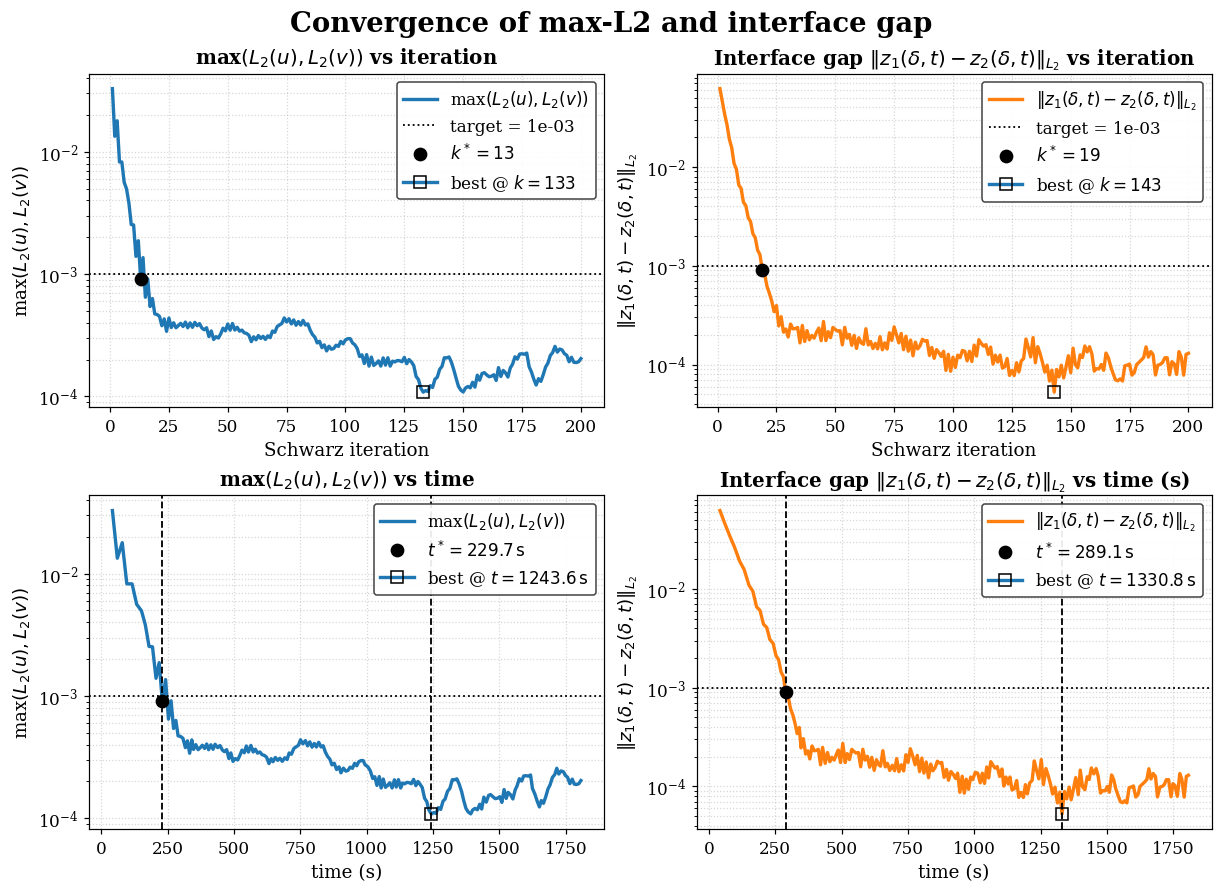

PNG saved at: content/mntt/seq_maxL2_gap_convergence.png
SVG saved at: content/mntt/seq_maxL2_gap_convergence.svg


In [ ]:
# @title Convergence of max-L2 error and interface jump
# Purpose: Parse the training log and plot convergence diagnostics.

import os, re, math
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, Image

OUTDIR      = globals().get("OUTDIR", "content/mntt")
CAP_ITERS   = globals().get("CAP_ITERS", 200)
TARGET_ACC  = 1e-3
TARGET_GAP  = 1e-3
SAVE_SVG    = True
DPI_PNG     = 300

os.makedirs(OUTDIR, exist_ok=True)

plt.style.use("default")
mpl.rcParams.update({
    "figure.figsize"     : (11, 8),
    "figure.dpi"         : 110,
    "font.family"        : "serif",
    "font.size"          : 11,
    "axes.labelsize"     : 12,
    "axes.titlesize"     : 13,
    "axes.titleweight"   : "bold",
    "axes.grid"          : True,
    "grid.linestyle"     : ":",
    "grid.alpha"         : 0.5,
    "grid.linewidth"     : 0.8,
    "legend.fontsize"    : 11,
    "legend.frameon"     : True,
    "legend.framealpha"  : 0.92,
    "legend.edgecolor"   : "0.2",
    "lines.linewidth"    : 2.2,
    "lines.markersize"   : 7,
    "savefig.bbox"       : "tight",
    "savefig.pad_inches" : 0.1,
    "savefig.dpi"        : DPI_PNG,
    "xtick.labelsize"    : 11,
    "ytick.labelsize"    : 11,
})

CB = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

_num = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"
re_warm      = re.compile(r"\[Timing\]\s*Warm-?start\s+total.*?:\s*(" + _num + r")\s*s", re.IGNORECASE)
re_iter_time = re.compile(r"\[Timing\]\s*Schwarz\s+iter\s+(\d+)\s*:\s*(" + _num + r")\s*s", re.IGNORECASE)
re_l2_pair   = re.compile(r"\[iter\s+(\d+)\]\s*L2\(u\)=(" + _num + r")\s*L2\(v\)=(" + _num + r")", re.IGNORECASE)
re_gap       = re.compile(r"\[iter\s+(\d+)\]\s*z1.*?=\s*(" + _num + r")", re.IGNORECASE)

def parse_log(log_text: str):
    if not log_text or not log_text.strip():
        return dict(
            warm_start=0.0, iter_order=[],
            iter_time={}, iter_l2u={}, iter_l2v={}, iter_gap={}
        )

    warm = 0.0
    m = re_warm.search(log_text)
    if m:
        warm = float(m.group(1))

    iter_time, iter_l2u, iter_l2v, iter_gap = {}, {}, {}, {}

    for k, t in re_iter_time.findall(log_text):
        iter_time[int(k)] = float(t)

    for k, u, v in re_l2_pair.findall(log_text):
        i = int(k)
        iter_l2u[i] = float(u)
        iter_l2v[i] = float(v)

    for k, g in re_gap.findall(log_text):
        iter_gap[int(k)] = float(g)

    iters = sorted(set(iter_time) | set(iter_l2u) | set(iter_l2v) | set(iter_gap))
    print(f"[parse] points: L2(u)={len(iter_l2u)}, L2(v)={len(iter_l2v)}, "
          f"gap={len(iter_gap)}, time={len(iter_time)}")

    return dict(
        warm_start=warm,
        iter_order=iters,
        iter_time=iter_time,
        iter_l2u=iter_l2u,
        iter_l2v=iter_l2v,
        iter_gap=iter_gap
    )

def wall_time_of(k, iters, tmap, warm):
    if k is None:
        return None
    return warm + sum(tmap.get(i, 0.0) for i in iters if i <= k)

def first_iter_below_threshold(values_dict, iters, thresh):
    for k in iters:
        v = values_dict.get(k, math.inf)
        if math.isfinite(v) and v <= thresh:
            return k
    return None

def best_iter_and_value(values_dict, iters):
    best_k, best_v = None, None
    for k in iters:
        v = values_dict.get(k, None)
        if v is None or not math.isfinite(v):
            continue
        if best_v is None or v < best_v:
            best_v, best_k = v, k
    return best_k, best_v

def save_and_show(fig, base, show_saved_image=False):
    """
    Save the figure and show it in notebook output.
    Returns the saved file paths.
    """
    png = f"{base}.png"
    svg = f"{base}.svg"

    fig.savefig(png, dpi=DPI_PNG)
    if SAVE_SVG:
        fig.savefig(svg)

    print(f"[Saved] {png}" + (f" + {svg}" if SAVE_SVG else ""))

    plt.show()

    if show_saved_image and os.path.exists(png):
        display(Image(filename=png))

    plt.close(fig)
    return png, (svg if SAVE_SVG else None)

sequential_log = """Device : cpu
[Timing] Warm-start total (parallel): 21.433 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 20.197 s
r1=2.707e-01  r2=3.382e-01  (max=3.382e-01)
[iter 1] L2(u)=3.273e-02  L2(v)=2.081e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=6.195e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 18.503 s
r1=3.440e-01  r2=1.445e-01  (max=3.440e-01)
[iter 2] L2(u)=1.336e-02  L2(v)=1.327e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=4.575e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 18.565 s
r1=1.488e-01  r2=1.914e-01  (max=1.914e-01)
[iter 3] L2(u)=1.181e-02  L2(v)=1.789e-02
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=3.428e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 17.174 s
r1=2.018e-01  r2=7.969e-02  (max=2.018e-01)
[iter 4] L2(u)=7.875e-03  L2(v)=8.247e-03
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.674e-02

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 19.882 s
r1=8.545e-02  r2=1.101e-01  (max=1.101e-01)
[iter 5] L2(u)=8.241e-03  L2(v)=7.852e-03
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=1.911e-02

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 17.202 s
r1=1.158e-01  r2=4.563e-02  (max=1.158e-01)
[iter 6] L2(u)=5.618e-03  L2(v)=4.622e-03
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=1.567e-02

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 18.257 s
r1=5.265e-02  r2=6.199e-02  (max=6.199e-02)
[iter 7] L2(u)=4.961e-03  L2(v)=3.337e-03
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=1.085e-02

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 14.441 s
r1=6.562e-02  r2=2.917e-02  (max=6.562e-02)
[iter 8] L2(u)=2.808e-03  L2(v)=3.814e-03
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=9.475e-03

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 14.094 s
r1=3.618e-02  r2=3.530e-02  (max=3.618e-02)
[iter 9] L2(u)=1.893e-03  L2(v)=2.538e-03
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=6.575e-03

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 12.902 s
r1=3.896e-02  r2=2.049e-02  (max=3.896e-02)
[iter 10] L2(u)=2.196e-03  L2(v)=2.521e-03
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=6.045e-03

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 13.276 s
r1=2.577e-02  r2=2.129e-02  (max=2.577e-02)
[iter 11] L2(u)=1.179e-03  L2(v)=1.394e-03
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=4.380e-03

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 11.970 s
r1=2.462e-02  r2=1.483e-02  (max=2.462e-02)
[iter 12] L2(u)=1.872e-03  L2(v)=1.559e-03
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=4.069e-03

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 11.820 s
r1=1.911e-02  r2=1.364e-02  (max=1.911e-02)
[iter 13] L2(u)=9.046e-04  L2(v)=7.797e-04
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=3.074e-03

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 12.325 s
r1=1.623e-02  r2=1.079e-02  (max=1.623e-02)
[iter 14] L2(u)=1.362e-03  L2(v)=1.105e-03
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=2.810e-03

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 10.819 s
r1=1.321e-02  r2=9.138e-03  (max=1.321e-02)
[iter 15] L2(u)=6.461e-04  L2(v)=5.801e-04
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=2.114e-03

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 9.753 s
r1=1.079e-02  r2=7.404e-03  (max=1.079e-02)
[iter 16] L2(u)=9.139e-04  L2(v)=8.446e-04
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=1.920e-03

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 9.451 s
r1=9.011e-03  r2=6.257e-03  (max=9.011e-03)
[iter 17] L2(u)=5.144e-04  L2(v)=5.420e-04
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=1.439e-03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 8.801 s
r1=7.424e-03  r2=4.831e-03  (max=7.424e-03)
[iter 18] L2(u)=6.181e-04  L2(v)=6.306e-04
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=1.295e-03

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 8.262 s
r1=5.703e-03  r2=4.031e-03  (max=5.703e-03)
[iter 19] L2(u)=4.718e-04  L2(v)=4.511e-04
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=9.034e-04

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 9.227 s
r1=4.622e-03  r2=3.102e-03  (max=4.622e-03)
[iter 20] L2(u)=4.667e-04  L2(v)=4.581e-04
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=8.218e-04

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 9.029 s
r1=3.767e-03  r2=2.701e-03  (max=3.767e-03)
[iter 21] L2(u)=4.509e-04  L2(v)=4.141e-04
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=6.181e-04

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 9.227 s
r1=2.916e-03  r2=2.107e-03  (max=2.916e-03)
[iter 22] L2(u)=3.782e-04  L2(v)=3.685e-04
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=5.265e-04

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 7.591 s
r1=2.340e-03  r2=1.916e-03  (max=2.340e-03)
[iter 23] L2(u)=4.299e-04  L2(v)=3.860e-04
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=4.403e-04

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 8.467 s
r1=1.903e-03  r2=1.463e-03  (max=1.903e-03)
[iter 24] L2(u)=3.402e-04  L2(v)=3.238e-04
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=3.432e-04

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 8.028 s
r1=1.710e-03  r2=1.553e-03  (max=1.710e-03)
[iter 25] L2(u)=4.373e-04  L2(v)=3.890e-04
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=3.952e-04

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 6.582 s
r1=1.404e-03  r2=1.194e-03  (max=1.404e-03)
[iter 26] L2(u)=3.654e-04  L2(v)=3.289e-04
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=2.460e-04

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 8.648 s
r1=1.096e-03  r2=1.189e-03  (max=1.189e-03)
[iter 27] L2(u)=3.999e-04  L2(v)=3.548e-04
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=3.050e-04

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 8.735 s
r1=1.027e-03  r2=1.073e-03  (max=1.073e-03)
[iter 28] L2(u)=3.640e-04  L2(v)=3.256e-04
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=2.130e-04

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 8.366 s
r1=7.695e-04  r2=9.522e-04  (max=9.522e-04)
[iter 29] L2(u)=3.787e-04  L2(v)=3.447e-04
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=2.291e-04

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 7.313 s
r1=7.713e-04  r2=9.263e-04  (max=9.263e-04)
[iter 30] L2(u)=3.955e-04  L2(v)=3.538e-04
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=1.900e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 8.536 s
r1=1.066e-03  r2=9.494e-04  (max=1.066e-03)
[iter 31] L2(u)=3.724e-04  L2(v)=3.239e-04
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=2.571e-04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 7.925 s
r1=8.806e-04  r2=1.096e-03  (max=1.096e-03)
[iter 32] L2(u)=4.048e-04  L2(v)=3.486e-04
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=2.300e-04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 7.323 s
r1=9.502e-04  r2=9.637e-04  (max=9.637e-04)
[iter 33] L2(u)=3.638e-04  L2(v)=3.090e-04
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=2.315e-04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 8.466 s
r1=7.891e-04  r2=1.085e-03  (max=1.085e-03)
[iter 34] L2(u)=3.988e-04  L2(v)=3.430e-04
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=2.375e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 8.332 s
r1=7.123e-04  r2=8.562e-04  (max=8.562e-04)
[iter 35] L2(u)=3.667e-04  L2(v)=3.176e-04
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=1.657e-04

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 7.595 s
r1=7.435e-04  r2=1.003e-03  (max=1.003e-03)
[iter 36] L2(u)=4.030e-04  L2(v)=3.417e-04
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=2.489e-04

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 9.818 s
r1=6.034e-04  r2=9.763e-04  (max=9.763e-04)
[iter 37] L2(u)=3.781e-04  L2(v)=3.208e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=1.714e-04

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 8.618 s
r1=7.033e-04  r2=9.623e-04  (max=9.623e-04)
[iter 38] L2(u)=3.934e-04  L2(v)=3.330e-04
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=2.209e-04

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 8.857 s
r1=7.160e-04  r2=9.887e-04  (max=9.887e-04)
[iter 39] L2(u)=3.620e-04  L2(v)=3.115e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=1.782e-04

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 7.559 s
r1=7.541e-04  r2=8.358e-04  (max=8.358e-04)
[iter 40] L2(u)=3.504e-04  L2(v)=3.057e-04
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=1.972e-04

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 8.707 s
r1=6.975e-04  r2=9.347e-04  (max=9.347e-04)
[iter 41] L2(u)=3.640e-04  L2(v)=3.120e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=1.851e-04

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 8.461 s
r1=9.934e-04  r2=8.260e-04  (max=9.934e-04)
[iter 42] L2(u)=3.080e-04  L2(v)=2.694e-04
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=2.122e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 7.315 s
r1=7.948e-04  r2=1.035e-03  (max=1.035e-03)
[iter 43] L2(u)=3.424e-04  L2(v)=2.995e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=2.339e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 8.276 s
r1=8.757e-04  r2=7.835e-04  (max=8.757e-04)
[iter 44] L2(u)=2.919e-04  L2(v)=2.646e-04
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=1.748e-04

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 8.530 s
r1=7.407e-04  r2=1.008e-03  (max=1.008e-03)
[iter 45] L2(u)=3.079e-04  L2(v)=2.670e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=2.728e-04

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 8.983 s
r1=7.984e-04  r2=9.124e-04  (max=9.124e-04)
[iter 46] L2(u)=3.000e-04  L2(v)=2.572e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=1.748e-04

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 7.621 s
r1=7.220e-04  r2=8.106e-04  (max=8.106e-04)
[iter 47] L2(u)=3.242e-04  L2(v)=2.809e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=2.153e-04

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 8.604 s
r1=8.001e-04  r2=9.157e-04  (max=9.157e-04)
[iter 48] L2(u)=3.610e-04  L2(v)=3.019e-04
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=1.873e-04

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 8.678 s
r1=9.122e-04  r2=8.797e-04  (max=9.122e-04)
[iter 49] L2(u)=3.431e-04  L2(v)=2.884e-04
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=2.376e-04

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 7.678 s
r1=8.417e-04  r2=1.040e-03  (max=1.040e-03)
[iter 50] L2(u)=3.901e-04  L2(v)=3.165e-04
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=2.269e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 8.008 s
r1=9.631e-04  r2=9.241e-04  (max=9.631e-04)
[iter 51] L2(u)=3.479e-04  L2(v)=2.880e-04
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=2.183e-04

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 9.253 s
r1=7.936e-04  r2=9.068e-04  (max=9.068e-04)
[iter 52] L2(u)=3.943e-04  L2(v)=3.287e-04
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=2.204e-04

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 8.632 s
r1=8.461e-04  r2=8.774e-04  (max=8.774e-04)
[iter 53] L2(u)=3.485e-04  L2(v)=2.938e-04
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=1.583e-04

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 7.989 s
r1=7.799e-04  r2=8.798e-04  (max=8.798e-04)
[iter 54] L2(u)=3.673e-04  L2(v)=3.188e-04
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=2.381e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 8.227 s
r1=7.660e-04  r2=8.486e-04  (max=8.486e-04)
[iter 55] L2(u)=3.410e-04  L2(v)=2.921e-04
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=1.848e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 8.906 s
r1=6.274e-04  r2=7.749e-04  (max=7.749e-04)
[iter 56] L2(u)=3.484e-04  L2(v)=3.115e-04
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=2.022e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 8.619 s
r1=5.730e-04  r2=7.528e-04  (max=7.528e-04)
[iter 57] L2(u)=3.309e-04  L2(v)=2.899e-04
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=1.567e-04

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 8.063 s
r1=6.014e-04  r2=7.195e-04  (max=7.195e-04)
[iter 58] L2(u)=3.270e-04  L2(v)=2.961e-04
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=1.974e-04

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 8.896 s
r1=4.564e-04  r2=7.444e-04  (max=7.444e-04)
[iter 59] L2(u)=3.154e-04  L2(v)=2.829e-04
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=1.456e-04

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 8.773 s
r1=5.901e-04  r2=7.354e-04  (max=7.354e-04)
[iter 60] L2(u)=2.803e-04  L2(v)=2.612e-04
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=1.867e-04

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 8.114 s
r1=6.568e-04  r2=7.295e-04  (max=7.295e-04)
[iter 61] L2(u)=3.071e-04  L2(v)=2.777e-04
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=1.662e-04

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 7.186 s
r1=5.313e-04  r2=8.005e-04  (max=8.005e-04)
[iter 62] L2(u)=2.901e-04  L2(v)=2.673e-04
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=1.604e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 8.678 s
r1=6.435e-04  r2=8.542e-04  (max=8.542e-04)
[iter 63] L2(u)=3.142e-04  L2(v)=2.895e-04
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=2.305e-04

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 9.048 s
r1=5.460e-04  r2=7.751e-04  (max=7.751e-04)
[iter 64] L2(u)=2.977e-04  L2(v)=2.577e-04
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=1.581e-04

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 8.241 s
r1=5.439e-04  r2=6.594e-04  (max=6.594e-04)
[iter 65] L2(u)=3.097e-04  L2(v)=2.757e-04
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=1.713e-04

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 8.842 s
r1=4.908e-04  r2=7.242e-04  (max=7.242e-04)
[iter 66] L2(u)=2.923e-04  L2(v)=2.544e-04
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=1.455e-04

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 9.520 s
r1=5.126e-04  r2=5.636e-04  (max=5.636e-04)
[iter 67] L2(u)=3.123e-04  L2(v)=2.808e-04
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=1.639e-04

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 8.695 s
r1=5.027e-04  r2=7.780e-04  (max=7.780e-04)
[iter 68] L2(u)=3.022e-04  L2(v)=2.693e-04
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=1.443e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 7.767 s
r1=6.927e-04  r2=6.873e-04  (max=6.927e-04)
[iter 69] L2(u)=3.419e-04  L2(v)=3.004e-04
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=1.917e-04

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 8.549 s
r1=5.544e-04  r2=8.096e-04  (max=8.096e-04)
[iter 70] L2(u)=3.341e-04  L2(v)=2.861e-04
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=1.412e-04

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 9.203 s
r1=7.117e-04  r2=6.274e-04  (max=7.117e-04)
[iter 71] L2(u)=3.726e-04  L2(v)=3.276e-04
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=1.659e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 8.653 s
r1=4.025e-04  r2=8.330e-04  (max=8.330e-04)
[iter 72] L2(u)=3.835e-04  L2(v)=3.244e-04
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=1.438e-04

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 8.420 s
r1=7.834e-04  r2=7.915e-04  (max=7.915e-04)
[iter 73] L2(u)=3.951e-04  L2(v)=3.402e-04
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=2.099e-04

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 7.977 s
r1=6.386e-04  r2=9.593e-04  (max=9.593e-04)
[iter 74] L2(u)=4.382e-04  L2(v)=3.697e-04
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=1.756e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 8.792 s
r1=1.208e-03  r2=8.844e-04  (max=1.208e-03)
[iter 75] L2(u)=4.060e-04  L2(v)=3.701e-04
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=2.409e-04

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 9.729 s
r1=6.209e-04  r2=1.121e-03  (max=1.121e-03)
[iter 76] L2(u)=4.315e-04  L2(v)=3.821e-04
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=1.996e-04

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 8.041 s
r1=1.071e-03  r2=7.376e-04  (max=1.071e-03)
[iter 77] L2(u)=3.909e-04  L2(v)=3.713e-04
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=1.659e-04

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 8.301 s
r1=6.492e-04  r2=1.014e-03  (max=1.014e-03)
[iter 78] L2(u)=4.218e-04  L2(v)=4.040e-04
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=2.065e-04

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 8.634 s
r1=8.668e-04  r2=8.343e-04  (max=8.668e-04)
[iter 79] L2(u)=3.814e-04  L2(v)=3.686e-04
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=1.415e-04

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 8.576 s
r1=7.852e-04  r2=7.515e-04  (max=7.852e-04)
[iter 80] L2(u)=4.043e-04  L2(v)=4.092e-04
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=1.938e-04

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 7.859 s
r1=7.395e-04  r2=7.755e-04  (max=7.755e-04)
[iter 81] L2(u)=3.825e-04  L2(v)=3.823e-04
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=1.366e-04

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 8.595 s
r1=8.334e-04  r2=7.961e-04  (max=8.334e-04)
[iter 82] L2(u)=3.933e-04  L2(v)=4.181e-04
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=1.771e-04

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 8.785 s
r1=7.101e-04  r2=8.542e-04  (max=8.542e-04)
[iter 83] L2(u)=3.585e-04  L2(v)=3.832e-04
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=1.227e-04

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 8.068 s
r1=9.092e-04  r2=6.346e-04  (max=9.092e-04)
[iter 84] L2(u)=3.593e-04  L2(v)=3.918e-04
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=1.685e-04

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 8.174 s
r1=7.709e-04  r2=8.432e-04  (max=8.432e-04)
[iter 85] L2(u)=3.271e-04  L2(v)=3.479e-04
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=1.441e-04

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 8.557 s
r1=7.799e-04  r2=7.526e-04  (max=7.799e-04)
[iter 86] L2(u)=3.007e-04  L2(v)=3.200e-04
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=1.551e-04

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 8.399 s
r1=7.415e-04  r2=7.898e-04  (max=7.898e-04)
[iter 87] L2(u)=2.923e-04  L2(v)=3.047e-04
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=1.802e-04

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 7.739 s
r1=7.634e-04  r2=7.753e-04  (max=7.753e-04)
[iter 88] L2(u)=2.700e-04  L2(v)=2.735e-04
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=1.730e-04

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 8.799 s
r1=6.390e-04  r2=7.123e-04  (max=7.123e-04)
[iter 89] L2(u)=2.819e-04  L2(v)=2.784e-04
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=1.751e-04

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 8.857 s
r1=6.415e-04  r2=6.835e-04  (max=6.835e-04)
[iter 90] L2(u)=2.504e-04  L2(v)=2.409e-04
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=1.236e-04

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 9.219 s
r1=6.179e-04  r2=5.470e-04  (max=6.179e-04)
[iter 91] L2(u)=2.569e-04  L2(v)=2.635e-04
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=1.491e-04

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 7.269 s
r1=6.997e-04  r2=5.891e-04  (max=6.997e-04)
[iter 92] L2(u)=2.354e-04  L2(v)=2.235e-04
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=1.157e-04

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 9.091 s
r1=6.943e-04  r2=5.398e-04  (max=6.943e-04)
[iter 93] L2(u)=2.478e-04  L2(v)=2.570e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=1.418e-04

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 9.428 s
r1=7.301e-04  r2=6.725e-04  (max=7.301e-04)
[iter 94] L2(u)=2.429e-04  L2(v)=2.382e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=1.321e-04

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 8.048 s
r1=7.053e-04  r2=5.481e-04  (max=7.053e-04)
[iter 95] L2(u)=2.463e-04  L2(v)=2.433e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=1.208e-04

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 7.929 s
r1=6.535e-04  r2=6.780e-04  (max=6.780e-04)
[iter 96] L2(u)=2.614e-04  L2(v)=2.620e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=1.363e-04

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 8.537 s
r1=5.280e-04  r2=6.207e-04  (max=6.207e-04)
[iter 97] L2(u)=2.472e-04  L2(v)=2.563e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=8.728e-05

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 8.528 s
r1=5.306e-04  r2=5.568e-04  (max=5.568e-04)
[iter 98] L2(u)=2.608e-04  L2(v)=2.815e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=1.270e-04

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 7.937 s
r1=5.855e-04  r2=5.147e-04  (max=5.855e-04)
[iter 99] L2(u)=2.542e-04  L2(v)=2.688e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=8.564e-05

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 7.395 s
r1=6.826e-04  r2=5.048e-04  (max=6.826e-04)
[iter 100] L2(u)=2.697e-04  L2(v)=2.898e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=1.186e-04

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 8.605 s
r1=4.153e-04  r2=5.637e-04  (max=5.637e-04)
[iter 101] L2(u)=2.649e-04  L2(v)=2.963e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=9.361e-05

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 8.066 s
r1=6.720e-04  r2=4.935e-04  (max=6.720e-04)
[iter 102] L2(u)=2.656e-04  L2(v)=2.966e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=1.246e-04

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 7.694 s
r1=5.867e-04  r2=6.436e-04  (max=6.436e-04)
[iter 103] L2(u)=2.531e-04  L2(v)=2.734e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=1.175e-04

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 9.736 s
r1=7.500e-04  r2=6.127e-04  (max=7.500e-04)
[iter 104] L2(u)=2.409e-04  L2(v)=2.640e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=1.390e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 9.207 s
r1=5.772e-04  r2=6.391e-04  (max=6.391e-04)
[iter 105] L2(u)=2.267e-04  L2(v)=2.455e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=1.363e-04

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 9.447 s
r1=6.745e-04  r2=4.976e-04  (max=6.745e-04)
[iter 106] L2(u)=2.041e-04  L2(v)=2.118e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=1.090e-04

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 7.822 s
r1=5.413e-04  r2=5.572e-04  (max=5.572e-04)
[iter 107] L2(u)=2.178e-04  L2(v)=2.186e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=1.364e-04

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 8.189 s
r1=7.395e-04  r2=5.166e-04  (max=7.395e-04)
[iter 108] L2(u)=1.856e-04  L2(v)=1.772e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=1.074e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 8.570 s
r1=6.790e-04  r2=6.325e-04  (max=6.790e-04)
[iter 109] L2(u)=2.085e-04  L2(v)=2.194e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=1.575e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 7.169 s
r1=8.501e-04  r2=5.821e-04  (max=8.501e-04)
[iter 110] L2(u)=1.748e-04  L2(v)=1.769e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=1.220e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 7.982 s
r1=8.047e-04  r2=6.905e-04  (max=8.047e-04)
[iter 111] L2(u)=2.008e-04  L2(v)=2.095e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=1.783e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 8.365 s
r1=1.024e-03  r2=7.021e-04  (max=1.024e-03)
[iter 112] L2(u)=1.791e-04  L2(v)=1.764e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=1.639e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 7.904 s
r1=7.134e-04  r2=7.093e-04  (max=7.134e-04)
[iter 113] L2(u)=1.800e-04  L2(v)=1.854e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=1.536e-04

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 8.247 s
r1=7.770e-04  r2=6.192e-04  (max=7.770e-04)
[iter 114] L2(u)=1.913e-04  L2(v)=1.953e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=1.591e-04

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 8.781 s
r1=6.252e-04  r2=7.095e-04  (max=7.095e-04)
[iter 115] L2(u)=1.739e-04  L2(v)=1.770e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=1.265e-04

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 8.759 s
r1=7.395e-04  r2=5.332e-04  (max=7.395e-04)
[iter 116] L2(u)=1.871e-04  L2(v)=2.064e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=1.504e-04

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 6.931 s
r1=5.940e-04  r2=5.111e-04  (max=5.940e-04)
[iter 117] L2(u)=1.692e-04  L2(v)=1.801e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=1.010e-04

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 8.181 s
r1=5.814e-04  r2=5.138e-04  (max=5.814e-04)
[iter 118] L2(u)=1.862e-04  L2(v)=2.070e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=1.245e-04

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 8.415 s
r1=6.633e-04  r2=5.463e-04  (max=6.633e-04)
[iter 119] L2(u)=1.693e-04  L2(v)=1.769e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=1.061e-04

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 6.749 s
r1=6.238e-04  r2=5.156e-04  (max=6.238e-04)
[iter 120] L2(u)=1.818e-04  L2(v)=1.941e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=1.247e-04

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 7.888 s
r1=4.954e-04  r2=4.482e-04  (max=4.954e-04)
[iter 121] L2(u)=1.778e-04  L2(v)=1.914e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=9.208e-05

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 8.973 s
r1=5.586e-04  r2=4.230e-04  (max=5.586e-04)
[iter 122] L2(u)=1.809e-04  L2(v)=1.965e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=9.524e-05

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 8.393 s
r1=4.575e-04  r2=4.884e-04  (max=4.884e-04)
[iter 123] L2(u)=1.834e-04  L2(v)=1.956e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=1.151e-04

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 7.888 s
r1=3.808e-04  r2=3.969e-04  (max=3.969e-04)
[iter 124] L2(u)=1.793e-04  L2(v)=1.918e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=7.771e-05

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 8.908 s
r1=4.562e-04  r2=4.092e-04  (max=4.562e-04)
[iter 125] L2(u)=1.880e-04  L2(v)=2.081e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=8.709e-05

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 8.524 s
r1=5.191e-04  r2=4.251e-04  (max=5.191e-04)
[iter 126] L2(u)=1.716e-04  L2(v)=1.849e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=7.738e-05

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 7.641 s
r1=5.200e-04  r2=5.119e-04  (max=5.200e-04)
[iter 127] L2(u)=1.862e-04  L2(v)=2.001e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=1.044e-04

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 7.227 s
r1=5.004e-04  r2=4.667e-04  (max=5.004e-04)
[iter 128] L2(u)=1.806e-04  L2(v)=1.912e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=8.423e-05

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 9.042 s
r1=4.649e-04  r2=5.589e-04  (max=5.589e-04)
[iter 129] L2(u)=1.703e-04  L2(v)=1.786e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=1.087e-04

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 9.095 s
r1=6.828e-04  r2=5.545e-04  (max=6.828e-04)
[iter 130] L2(u)=1.447e-04  L2(v)=1.455e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=1.151e-04

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 7.978 s
r1=5.388e-04  r2=8.207e-04  (max=8.207e-04)
[iter 131] L2(u)=1.363e-04  L2(v)=1.372e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=1.814e-04

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 7.896 s
r1=8.044e-04  r2=5.795e-04  (max=8.044e-04)
[iter 132] L2(u)=1.171e-04  L2(v)=1.111e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=1.483e-04

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 9.557 s
r1=4.849e-04  r2=6.385e-04  (max=6.385e-04)
[iter 133] L2(u)=1.084e-04  L2(v)=1.024e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=1.195e-04

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 9.055 s
r1=6.156e-04  r2=7.160e-04  (max=7.160e-04)
[iter 134] L2(u)=1.115e-04  L2(v)=1.011e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=1.875e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 7.919 s
r1=5.163e-04  r2=5.090e-04  (max=5.163e-04)
[iter 135] L2(u)=1.097e-04  L2(v)=8.160e-05
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=1.044e-04

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 9.556 s
r1=5.637e-04  r2=5.678e-04  (max=5.678e-04)
[iter 136] L2(u)=1.222e-04  L2(v)=9.842e-05
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=1.519e-04

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 8.506 s
r1=4.275e-04  r2=5.921e-04  (max=5.921e-04)
[iter 137] L2(u)=1.183e-04  L2(v)=9.144e-05
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=1.289e-04

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 8.853 s
r1=5.462e-04  r2=4.033e-04  (max=5.462e-04)
[iter 138] L2(u)=1.381e-04  L2(v)=1.072e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=1.054e-04

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 7.760 s
r1=3.897e-04  r2=5.106e-04  (max=5.106e-04)
[iter 139] L2(u)=1.436e-04  L2(v)=1.176e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=8.405e-05

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 9.153 s
r1=6.081e-04  r2=4.090e-04  (max=6.081e-04)
[iter 140] L2(u)=1.662e-04  L2(v)=1.533e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=9.852e-05

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 8.995 s
r1=4.148e-04  r2=5.466e-04  (max=5.466e-04)
[iter 141] L2(u)=1.758e-04  L2(v)=1.743e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=6.813e-05

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 9.212 s
r1=7.005e-04  r2=4.651e-04  (max=7.005e-04)
[iter 142] L2(u)=1.818e-04  L2(v)=2.071e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=8.778e-05

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 8.174 s
r1=4.432e-04  r2=6.238e-04  (max=6.238e-04)
[iter 143] L2(u)=1.728e-04  L2(v)=2.064e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=5.266e-05

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 8.870 s
r1=6.444e-04  r2=4.764e-04  (max=6.444e-04)
[iter 144] L2(u)=1.854e-04  L2(v)=2.100e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=8.915e-05

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 8.858 s
r1=4.920e-04  r2=5.770e-04  (max=5.770e-04)
[iter 145] L2(u)=1.771e-04  L2(v)=1.900e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=7.505e-05

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 9.105 s
r1=6.513e-04  r2=4.607e-04  (max=6.513e-04)
[iter 146] L2(u)=1.652e-04  L2(v)=1.630e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=9.855e-05

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 7.594 s
r1=5.550e-04  r2=4.594e-04  (max=5.550e-04)
[iter 147] L2(u)=1.405e-04  L2(v)=1.354e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=7.330e-05

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 8.546 s
r1=4.841e-04  r2=5.383e-04  (max=5.383e-04)
[iter 148] L2(u)=1.207e-04  L2(v)=1.177e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=9.408e-05

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 8.643 s
r1=5.164e-04  r2=5.617e-04  (max=5.617e-04)
[iter 149] L2(u)=1.126e-04  L2(v)=1.111e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=1.230e-04

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 9.548 s
r1=4.327e-04  r2=4.487e-04  (max=4.487e-04)
[iter 150] L2(u)=1.087e-04  L2(v)=9.601e-05
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=8.273e-05

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 7.483 s
r1=4.777e-04  r2=5.983e-04  (max=5.983e-04)
[iter 151] L2(u)=1.171e-04  L2(v)=1.024e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=1.465e-04

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 8.568 s
r1=4.417e-04  r2=4.866e-04  (max=4.866e-04)
[iter 152] L2(u)=1.205e-04  L2(v)=9.032e-05
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=9.964e-05

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 8.949 s
r1=5.212e-04  r2=5.287e-04  (max=5.287e-04)
[iter 153] L2(u)=1.175e-04  L2(v)=8.536e-05
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=9.281e-05

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 8.878 s
r1=7.002e-04  r2=5.288e-04  (max=7.002e-04)
[iter 154] L2(u)=1.303e-04  L2(v)=1.181e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=1.254e-04

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 7.325 s
r1=4.354e-04  r2=6.685e-04  (max=6.685e-04)
[iter 155] L2(u)=1.191e-04  L2(v)=1.140e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=1.179e-04

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 8.121 s
r1=8.400e-04  r2=4.288e-04  (max=8.400e-04)
[iter 156] L2(u)=1.429e-04  L2(v)=1.490e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=1.542e-04

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 9.081 s
r1=7.044e-04  r2=7.535e-04  (max=7.535e-04)
[iter 157] L2(u)=1.299e-04  L2(v)=1.356e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=1.343e-04

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 8.915 s
r1=9.298e-04  r2=4.600e-04  (max=9.298e-04)
[iter 158] L2(u)=1.538e-04  L2(v)=1.479e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=1.517e-04

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 7.415 s
r1=5.658e-04  r2=6.248e-04  (max=6.248e-04)
[iter 159] L2(u)=1.441e-04  L2(v)=1.563e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=1.280e-04

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 9.197 s
r1=5.155e-04  r2=3.785e-04  (max=5.155e-04)
[iter 160] L2(u)=1.437e-04  L2(v)=1.498e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=8.587e-05

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 8.728 s
r1=4.114e-04  r2=5.133e-04  (max=5.133e-04)
[iter 161] L2(u)=1.427e-04  L2(v)=1.448e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=9.090e-05

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 8.989 s
r1=3.975e-04  r2=3.699e-04  (max=3.975e-04)
[iter 162] L2(u)=1.462e-04  L2(v)=1.435e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=9.039e-05

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 7.833 s
r1=4.337e-04  r2=3.743e-04  (max=4.337e-04)
[iter 163] L2(u)=1.502e-04  L2(v)=1.502e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=1.002e-04

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 7.781 s
r1=5.261e-04  r2=4.509e-04  (max=5.261e-04)
[iter 164] L2(u)=1.350e-04  L2(v)=1.350e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=8.751e-05

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 8.373 s
r1=7.148e-04  r2=4.200e-04  (max=7.148e-04)
[iter 165] L2(u)=1.718e-04  L2(v)=1.659e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=1.308e-04

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 8.105 s
r1=7.590e-04  r2=5.634e-04  (max=7.590e-04)
[iter 166] L2(u)=1.415e-04  L2(v)=1.454e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=1.173e-04

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 7.193 s
r1=5.959e-04  r2=4.325e-04  (max=5.959e-04)
[iter 167] L2(u)=1.631e-04  L2(v)=1.549e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=9.572e-05

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 9.121 s
r1=4.754e-04  r2=3.798e-04  (max=4.754e-04)
[iter 168] L2(u)=1.536e-04  L2(v)=1.556e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=8.126e-05

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 8.783 s
r1=2.986e-04  r2=4.525e-04  (max=4.525e-04)
[iter 169] L2(u)=1.434e-04  L2(v)=1.440e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=7.011e-05

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 8.546 s
r1=5.531e-04  r2=3.097e-04  (max=5.531e-04)
[iter 170] L2(u)=1.676e-04  L2(v)=1.706e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=6.864e-05

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 7.095 s
r1=3.384e-04  r2=4.569e-04  (max=4.569e-04)
[iter 171] L2(u)=1.653e-04  L2(v)=1.838e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=7.163e-05

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 8.476 s
r1=6.233e-04  r2=2.921e-04  (max=6.233e-04)
[iter 172] L2(u)=2.048e-04  L2(v)=2.106e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=6.822e-05

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 8.755 s
r1=4.246e-04  r2=6.482e-04  (max=6.482e-04)
[iter 173] L2(u)=2.017e-04  L2(v)=1.974e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=9.732e-05

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 7.956 s
r1=5.620e-04  r2=4.650e-04  (max=5.620e-04)
[iter 174] L2(u)=2.219e-04  L2(v)=1.989e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=9.869e-05

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 8.104 s
r1=3.669e-04  r2=6.212e-04  (max=6.212e-04)
[iter 175] L2(u)=2.230e-04  L2(v)=2.143e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=1.012e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 8.990 s
r1=4.076e-04  r2=4.046e-04  (max=4.076e-04)
[iter 176] L2(u)=2.211e-04  L2(v)=2.076e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=7.822e-05

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 8.608 s
r1=3.672e-04  r2=5.020e-04  (max=5.020e-04)
[iter 177] L2(u)=2.260e-04  L2(v)=2.046e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=8.311e-05

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 7.253 s
r1=8.052e-04  r2=4.993e-04  (max=8.052e-04)
[iter 178] L2(u)=1.749e-04  L2(v)=1.649e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=1.000e-04

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 8.781 s
r1=3.516e-04  r2=5.974e-04  (max=5.974e-04)
[iter 179] L2(u)=1.584e-04  L2(v)=1.479e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=1.053e-04

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 8.960 s
r1=5.994e-04  r2=4.886e-04  (max=5.994e-04)
[iter 180] L2(u)=1.382e-04  L2(v)=1.377e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=1.112e-04

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 8.364 s
r1=5.068e-04  r2=6.150e-04  (max=6.150e-04)
[iter 181] L2(u)=1.239e-04  L2(v)=1.218e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=1.180e-04

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 7.292 s
r1=6.567e-04  r2=5.302e-04  (max=6.567e-04)
[iter 182] L2(u)=1.397e-04  L2(v)=1.348e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=1.512e-04

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 8.083 s
r1=5.728e-04  r2=6.447e-04  (max=6.447e-04)
[iter 183] L2(u)=1.325e-04  L2(v)=1.326e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=1.192e-04

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 8.545 s
r1=6.207e-04  r2=4.785e-04  (max=6.207e-04)
[iter 184] L2(u)=1.486e-04  L2(v)=1.502e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=1.353e-04

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 8.417 s
r1=6.083e-04  r2=6.914e-04  (max=6.914e-04)
[iter 185] L2(u)=1.600e-04  L2(v)=1.736e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=1.262e-04

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 7.591 s
r1=5.732e-04  r2=5.963e-04  (max=5.963e-04)
[iter 186] L2(u)=1.718e-04  L2(v)=1.871e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=7.846e-05

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 9.074 s
r1=4.595e-04  r2=5.560e-04  (max=5.560e-04)
[iter 187] L2(u)=2.024e-04  L2(v)=2.157e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=9.867e-05

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 9.043 s
r1=3.927e-04  r2=5.262e-04  (max=5.262e-04)
[iter 188] L2(u)=2.084e-04  L2(v)=2.281e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=1.003e-04

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 7.385 s
r1=5.850e-04  r2=5.198e-04  (max=5.850e-04)
[iter 189] L2(u)=2.430e-04  L2(v)=2.563e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=1.048e-04

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 7.639 s
r1=4.747e-04  r2=7.459e-04  (max=7.459e-04)
[iter 190] L2(u)=2.272e-04  L2(v)=2.300e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=1.171e-04

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 8.656 s
r1=5.526e-04  r2=6.455e-04  (max=6.455e-04)
[iter 191] L2(u)=2.440e-04  L2(v)=2.308e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=1.173e-04

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 9.092 s
r1=3.956e-04  r2=5.477e-04  (max=5.477e-04)
[iter 192] L2(u)=2.398e-04  L2(v)=2.324e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=7.872e-05

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 7.312 s
r1=3.883e-04  r2=5.965e-04  (max=5.965e-04)
[iter 193] L2(u)=2.235e-04  L2(v)=2.207e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=1.070e-04

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 7.824 s
r1=3.131e-04  r2=5.669e-04  (max=5.669e-04)
[iter 194] L2(u)=2.169e-04  L2(v)=2.156e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=1.017e-04

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 8.757 s
r1=5.324e-04  r2=4.670e-04  (max=5.324e-04)
[iter 195] L2(u)=1.920e-04  L2(v)=1.918e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=7.950e-05

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 9.124 s
r1=4.728e-04  r2=6.152e-04  (max=6.152e-04)
[iter 196] L2(u)=2.089e-04  L2(v)=2.032e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=1.353e-04

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 7.701 s
r1=6.647e-04  r2=5.640e-04  (max=6.647e-04)
[iter 197] L2(u)=1.808e-04  L2(v)=1.900e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=1.186e-04

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 8.823 s
r1=4.110e-04  r2=4.375e-04  (max=4.375e-04)
[iter 198] L2(u)=1.876e-04  L2(v)=1.891e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=7.809e-05

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 8.301 s
r1=4.584e-04  r2=5.585e-04  (max=5.585e-04)
[iter 199] L2(u)=1.876e-04  L2(v)=1.918e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=1.268e-04

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 7.707 s
r1=4.513e-04  r2=5.414e-04  (max=5.414e-04)
[iter 200] L2(u)=1.878e-04  L2(v)=2.036e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=1.300e-04

[Timing] Decomposed (z1/z2) total: 2006.478 s (warm-start 21.433 s, Schwarz 1985.045 s)
[Timing] Schwarz per-iter: avg 8.928 s, min 6.582 s, max 20.197 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt

"""

parsed = parse_log(sequential_log)

iters_all = parsed["iter_order"]
iters = [k for k in iters_all if (CAP_ITERS is None or k <= CAP_ITERS)]

if not iters:
    print("[Info] No iterations found – nothing to plot.")
else:
    warm = parsed["warm_start"]
    t_map = parsed["iter_time"]
    u_map = parsed["iter_l2u"]
    v_map = parsed["iter_l2v"]
    g_map = parsed["iter_gap"]

    y_u   = [u_map.get(i, math.nan) for i in iters]
    y_v   = [v_map.get(i, math.nan) for i in iters]
    y_gap = [g_map.get(i, math.nan) for i in iters]
    y_max = [max(u_map.get(i, math.inf), v_map.get(i, math.inf)) for i in iters]

    cum = []
    c = warm
    for i in iters:
        c += t_map.get(i, 0.0)
        cum.append(c)

    k_acc = first_iter_below_threshold({k: y for k, y in zip(iters, y_max)}, iters, TARGET_ACC)
    k_gap = first_iter_below_threshold(g_map, iters, TARGET_GAP)

    t_acc = wall_time_of(k_acc, iters, t_map, warm)
    t_gap = wall_time_of(k_gap, iters, t_map, warm)

    best_acc_iter, best_acc_val = best_iter_and_value(
        {k: y for k, y in zip(iters, y_max)}, iters
    )
    best_gap_iter, best_gap_val = best_iter_and_value(g_map, iters)

    best_acc_wall = wall_time_of(best_acc_iter, iters, t_map, warm)
    best_gap_wall = wall_time_of(best_gap_iter, iters, t_map, warm)

    print(f"[info] k*_acc = {k_acc}, t*_acc = {t_acc}")
    print(f"[info] k*_gap = {k_gap}, t*_gap = {t_gap}")
    print(f"[info] best_acc_iter = {best_acc_iter}, best_maxL2 = {best_acc_val}")
    print(f"[info] best_gap_iter = {best_gap_iter}, best_gap = {best_gap_val}")

    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)

    ax = axes[0, 0]
    ax.plot(iters, y_max, color=CB[0], label=r'max$(L_2(u), L_2(v))$')
    ax.axhline(TARGET_ACC, color='k', ls=':', lw=1.2, label=f'target = {TARGET_ACC:.0e}')

    if k_acc is not None and k_acc in iters:
        j = iters.index(k_acc)
        ax.plot(k_acc, y_max[j], 'o', color='k', ms=8, label=f'$k^* = {k_acc}$')

    if best_acc_iter is not None and best_acc_iter in iters:
        j = iters.index(best_acc_iter)
        ax.plot(best_acc_iter, y_max[j], marker='s', ms=8, mfc='none', mec='k',
                label=f'best @ $k = {best_acc_iter}$')

    ax.set_xlabel('Schwarz iteration')
    ax.set_ylabel(r'max$(L_2(u), L_2(v))$')
    ax.set_yscale('log')
    ax.set_title(r'max$(L_2(u), L_2(v))$ vs iteration')
    ax.legend(loc='upper right')
    ax.grid(True, which='both', ls=':')

    ax = axes[0, 1]
    ax.plot(iters, y_gap, color=CB[1], label=r'$\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$')
    ax.axhline(TARGET_GAP, color='k', ls=':', lw=1.2, label=f'target = {TARGET_GAP:.0e}')

    if k_gap is not None and k_gap in iters:
        j = iters.index(k_gap)
        ax.plot(k_gap, y_gap[j], 'o', color='k', ms=8, label=f'$k^* = {k_gap}$')

    if best_gap_iter is not None and best_gap_iter in iters:
        j = iters.index(best_gap_iter)
        ax.plot(best_gap_iter, y_gap[j], marker='s', ms=8, mfc='none', mec='k',
                label=f'best @ $k = {best_gap_iter}$')

    ax.set_xlabel('Schwarz iteration')
    ax.set_ylabel(r'$\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$')
    ax.set_yscale('log')
    ax.set_title(r'Interface gap $\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$ vs iteration')
    ax.legend(loc='upper right')
    ax.grid(True, which='both', ls=':')

    ax = axes[1, 0]
    ax.plot(cum, y_max, color=CB[0], label=r'max$(L_2(u), L_2(v))$')
    ax.axhline(TARGET_ACC, color='k', ls=':', lw=1.2)

    if t_acc is not None and k_acc is not None and k_acc in iters:
        j = iters.index(k_acc)
        ax.axvline(t_acc, color='k', ls='--', lw=1.2)
        ax.plot(t_acc, y_max[j], 'o', color='k', ms=8,
                label='$t^* = {:.1f}\\,\\mathrm{{s}}$'.format(t_acc))

    if best_acc_wall is not None and best_acc_iter in iters:
        j = iters.index(best_acc_iter)
        ax.axvline(best_acc_wall, color='k', ls='--', lw=1.2)
        ax.plot(best_acc_wall, y_max[j], marker='s', ms=8, mfc='none', mec='k',
                label='best @ $t = {:.1f}\\,\\mathrm{{s}}$'.format(best_acc_wall))

    ax.set_xlabel('time (s)')
    ax.set_ylabel(r'max$(L_2(u), L_2(v))$')
    ax.set_yscale('log')
    ax.set_title(r'max$(L_2(u), L_2(v))$ vs time')
    ax.legend(loc='upper right')
    ax.grid(True, which='both', ls=':')

    ax = axes[1, 1]
    ax.plot(cum, y_gap, color=CB[1], label=r'$\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$')
    ax.axhline(TARGET_GAP, color='k', ls=':', lw=1.2)

    if t_gap is not None and k_gap is not None and k_gap in iters:
        j = iters.index(k_gap)
        ax.axvline(t_gap, color='k', ls='--', lw=1.2)
        ax.plot(t_gap, y_gap[j], 'o', color='k', ms=8,
                label='$t^* = {:.1f}\\,\\mathrm{{s}}$'.format(t_gap))

    if best_gap_wall is not None and best_gap_iter in iters:
        j = iters.index(best_gap_iter)
        ax.axvline(best_gap_wall, color='k', ls='--', lw=1.2)
        ax.plot(best_gap_wall, y_gap[j], marker='s', ms=8, mfc='none', mec='k',
                label='best @ $t = {:.1f}\\,\\mathrm{{s}}$'.format(best_gap_wall))

    ax.set_xlabel('time (s)')
    ax.set_ylabel(r'$\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$')
    ax.set_yscale('log')
    ax.set_title(r'Interface gap $\|z_1(\delta,t)-z_2(\delta,t)\|_{L_2}$ vs time (s)')
    ax.legend(loc='upper right')
    ax.grid(True, which='both', ls=':')

    fig.suptitle("Convergence of max-L2 and interface gap", fontsize=18, fontweight="bold")

    png_path, svg_path = save_and_show(
        fig,
        os.path.join(OUTDIR, "seq_maxL2_gap_convergence"),
        show_saved_image=False
    )

    print("PNG saved at:", png_path)
    if svg_path is not None:
        print("SVG saved at:", svg_path)


## Seed 123 Training Run

Same Example 2 asymmetric optimized Schwarz PINN experiment, repeated with seed `123`.


In [ ]:
# @title Example 2: Optimized Schwarz PINN, seed 123
# Purpose: Train the Example 2 asymmetric optimized Schwarz PINN for seed 123.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

torch.manual_seed(123); np.random.seed(123)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.3
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 200
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

def phi0(x):
    return x**2 * (1.0 - x)**2

def phi0pp(x):
    return 12.0*x**2 - 12.0*x + 2.0

def u_exact(x, t):
    return phi0pp(x) * torch.cos(t)

def v_exact(x, t):
    return -phi0(x) * torch.sin(t)

def f_rhs(x, t):
    return (24.0 - phi0(x)) * torch.cos(t)

def z_exact(x, t):
    return torch.cat([u_exact(x, t), v_exact(x, t)], dim=1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-3/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)

    spec = sign * (k * c / s)

    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)

def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = phi0pp(x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u_bc = u0 + 2.0 * (torch.cos(t) - 1.0)

        u = u_bc + Sx * t * u_hat
        v = v0   + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 60, 61
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    """
    Plot z1 on [0,delta) and z2 on [delta,L] at fixed time t_value.
    If model output has 2 columns, 'comp' selects the component (0=u, 1=v).
    Returns a dict with the pointwise interface gap at x=delta.
    """

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    """
    Save two figures per iteration (u and v) at time t_value.
    Returns the gaps at x=delta for u and v.
    """
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)
    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 8.066 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 19.264 s
r1=5.636e-01  r2=3.926e-01  (max=5.636e-01)
[iter 1] L2(u)=3.956e-02  L2(v)=3.874e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=5.732e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 18.642 s
r1=3.428e-01  r2=2.894e-01  (max=3.428e-01)
[iter 2] L2(u)=1.359e-02  L2(v)=4.678e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=5.689e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 16.112 s
r1=2.586e-01  r2=1.748e-01  (max=2.586e-01)
[iter 3] L2(u)=8.013e-03  L2(v)=2.490e-02
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=2.417e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 13.105 s
r1=1.509e-01  r2=1.363e-01  (max=1.509e-01)
[iter 4] L2(u)=1.911e-02  L2(v)=1.392e-02
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.552e-02

=== Schwarz iteration 5 (global in time, parallel Ja

## Seed 12 Training Run

Same Example 2 asymmetric optimized Schwarz PINN experiment, repeated with seed `12`.


In [ ]:
# @title Example 2: Optimized Schwarz PINN, seed 12
# Purpose: Train the Example 2 asymmetric optimized Schwarz PINN for seed 12.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

torch.manual_seed(12); np.random.seed(12)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.3
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 200
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

def phi0(x):
    return x**2 * (1.0 - x)**2

def phi0pp(x):
    return 12.0*x**2 - 12.0*x + 2.0

def u_exact(x, t):
    return phi0pp(x) * torch.cos(t)

def v_exact(x, t):
    return -phi0(x) * torch.sin(t)

def f_rhs(x, t):
    return (24.0 - phi0(x)) * torch.cos(t)

def z_exact(x, t):
    return torch.cat([u_exact(x, t), v_exact(x, t)], dim=1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-3/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)

    spec = sign * (k * c / s)

    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)

def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = phi0pp(x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u_bc = u0 + 2.0 * (torch.cos(t) - 1.0)

        u = u_bc + Sx * t * u_hat
        v = v0   + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 60, 61
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    """
    Plot z1 on [0,delta) and z2 on [delta,L] at fixed time t_value.
    If model output has 2 columns, 'comp' selects the component (0=u, 1=v).
    Returns a dict with the pointwise interface gap at x=delta.
    """

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    """
    Save two figures per iteration (u and v) at time t_value.
    Returns the gaps at x=delta for u and v.
    """
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)
    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 8.746 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 18.839 s
r1=2.880e-01  r2=2.844e-01  (max=2.880e-01)
[iter 1] L2(u)=2.834e-02  L2(v)=2.500e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=4.500e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 18.262 s
r1=2.567e-01  r2=1.350e-01  (max=2.567e-01)
[iter 2] L2(u)=1.147e-02  L2(v)=2.403e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=3.355e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 17.213 s
r1=1.049e-01  r2=1.396e-01  (max=1.396e-01)
[iter 3] L2(u)=1.005e-02  L2(v)=1.728e-02
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=1.775e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 15.257 s
r1=1.369e-01  r2=5.022e-02  (max=1.369e-01)
[iter 4] L2(u)=1.150e-02  L2(v)=8.308e-03
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=1.605e-02

=== Schwarz iteration 5 (global in time, parallel Ja

## Seed 1 Training Run

Same Example 2 asymmetric optimized Schwarz PINN experiment, repeated with seed `1`.


In [ ]:
# @title Example 2: Optimized Schwarz PINN, seed 1
# Purpose: Train the Example 2 asymmetric optimized Schwarz PINN for seed 1.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

torch.manual_seed(1); np.random.seed(1)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.3
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 200
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

def phi0(x):
    return x**2 * (1.0 - x)**2

def phi0pp(x):
    return 12.0*x**2 - 12.0*x + 2.0

def u_exact(x, t):
    return phi0pp(x) * torch.cos(t)

def v_exact(x, t):
    return -phi0(x) * torch.sin(t)

def f_rhs(x, t):
    return (24.0 - phi0(x)) * torch.cos(t)

def z_exact(x, t):
    return torch.cat([u_exact(x, t), v_exact(x, t)], dim=1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-3/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)

    spec = sign * (k * c / s)

    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)

def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

class Net(nn.Module):
    def __init__(self, depth=6, width=48):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = phi0pp(x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u_bc = u0 + 2.0 * (torch.cos(t) - 1.0)

        u = u_bc + Sx * t * u_hat
        v = v0   + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 60, 61
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    """
    Plot z1 on [0,delta) and z2 on [delta,L] at fixed time t_value.
    If model output has 2 columns, 'comp' selects the component (0=u, 1=v).
    Returns a dict with the pointwise interface gap at x=delta.
    """

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    """
    Save two figures per iteration (u and v) at time t_value.
    Returns the gaps at x=delta for u and v.
    """
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)
    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 9.062 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 19.061 s
r1=3.427e-01  r2=4.328e-01  (max=4.328e-01)
[iter 1] L2(u)=4.061e-02  L2(v)=2.751e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=7.121e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 18.309 s
r1=3.990e-01  r2=1.643e-01  (max=3.990e-01)
[iter 2] L2(u)=1.663e-02  L2(v)=2.380e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=5.306e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 19.026 s
r1=1.439e-01  r2=2.171e-01  (max=2.171e-01)
[iter 3] L2(u)=1.492e-02  L2(v)=2.095e-02
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=3.363e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 17.264 s
r1=2.158e-01  r2=7.402e-02  (max=2.158e-01)
[iter 4] L2(u)=1.151e-02  L2(v)=9.679e-03
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.814e-02

=== Schwarz iteration 5 (global in time, parallel Ja

## Stored Logs for All Seeds

This cell stores raw console logs in `SEED_LOGS` so later analysis cells can generate statistics without rerunning training.


In [ ]:
# @title Optimized Schwarz PINN logs for all seeds
# Purpose: Store raw seed logs for the later statistics cells.

SEED_LOGS = {

1:   r"""Device : cpu
[Timing] Warm-start total (parallel): 9.062 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 19.061 s
r1=3.427e-01  r2=4.328e-01  (max=4.328e-01)
[iter 1] L2(u)=4.061e-02  L2(v)=2.751e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=7.121e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 18.309 s
r1=3.990e-01  r2=1.643e-01  (max=3.990e-01)
[iter 2] L2(u)=1.663e-02  L2(v)=2.380e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=5.306e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 19.026 s
r1=1.439e-01  r2=2.171e-01  (max=2.171e-01)
[iter 3] L2(u)=1.492e-02  L2(v)=2.095e-02
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=3.363e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 17.264 s
r1=2.158e-01  r2=7.402e-02  (max=2.158e-01)
[iter 4] L2(u)=1.151e-02  L2(v)=9.679e-03
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.814e-02

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 17.440 s
r1=7.913e-02  r2=1.178e-01  (max=1.178e-01)
[iter 5] L2(u)=9.236e-03  L2(v)=9.348e-03
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=1.819e-02

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 16.255 s
r1=1.186e-01  r2=4.246e-02  (max=1.186e-01)
[iter 6] L2(u)=6.531e-03  L2(v)=4.921e-03
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=1.578e-02

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 14.784 s
r1=5.041e-02  r2=6.356e-02  (max=6.356e-02)
[iter 7] L2(u)=5.435e-03  L2(v)=3.751e-03
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=1.024e-02

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 16.270 s
r1=6.428e-02  r2=2.744e-02  (max=6.428e-02)
[iter 8] L2(u)=2.759e-03  L2(v)=3.729e-03
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=8.980e-03

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 12.899 s
r1=3.379e-02  r2=3.373e-02  (max=3.379e-02)
[iter 9] L2(u)=2.050e-03  L2(v)=2.563e-03
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=5.910e-03

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 13.903 s
r1=3.514e-02  r2=1.810e-02  (max=3.514e-02)
[iter 10] L2(u)=1.763e-03  L2(v)=2.200e-03
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=5.188e-03

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 14.247 s
r1=2.262e-02  r2=1.831e-02  (max=2.262e-02)
[iter 11] L2(u)=1.089e-03  L2(v)=1.318e-03
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=3.640e-03

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 12.597 s
r1=2.069e-02  r2=1.220e-02  (max=2.069e-02)
[iter 12] L2(u)=1.376e-03  L2(v)=1.346e-03
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=3.212e-03

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 11.545 s
r1=1.558e-02  r2=1.081e-02  (max=1.558e-02)
[iter 13] L2(u)=7.394e-04  L2(v)=7.086e-04
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=2.417e-03

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 10.758 s
r1=1.370e-02  r2=8.337e-03  (max=1.370e-02)
[iter 14] L2(u)=1.030e-03  L2(v)=9.700e-04
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=2.193e-03

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 8.812 s
r1=1.086e-02  r2=7.157e-03  (max=1.086e-02)
[iter 15] L2(u)=5.739e-04  L2(v)=5.663e-04
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=1.675e-03

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 9.125 s
r1=8.695e-03  r2=5.802e-03  (max=8.695e-03)
[iter 16] L2(u)=7.980e-04  L2(v)=7.204e-04
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=1.458e-03

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 10.288 s
r1=6.869e-03  r2=4.704e-03  (max=6.869e-03)
[iter 17] L2(u)=5.376e-04  L2(v)=6.084e-04
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=1.060e-03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 10.299 s
r1=5.703e-03  r2=3.553e-03  (max=5.703e-03)
[iter 18] L2(u)=6.541e-04  L2(v)=6.472e-04
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=9.389e-04

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 9.104 s
r1=3.933e-03  r2=3.091e-03  (max=3.933e-03)
[iter 19] L2(u)=5.681e-04  L2(v)=6.725e-04
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=6.520e-04

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 8.526 s
r1=3.679e-03  r2=2.142e-03  (max=3.679e-03)
[iter 20] L2(u)=6.172e-04  L2(v)=6.305e-04
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=6.045e-04

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 8.051 s
r1=2.378e-03  r2=2.213e-03  (max=2.378e-03)
[iter 21] L2(u)=6.056e-04  L2(v)=6.532e-04
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=4.430e-04

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 8.229 s
r1=2.313e-03  r2=1.155e-03  (max=2.313e-03)
[iter 22] L2(u)=5.814e-04  L2(v)=6.026e-04
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=3.649e-04

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 8.759 s
r1=1.510e-03  r2=1.507e-03  (max=1.510e-03)
[iter 23] L2(u)=6.006e-04  L2(v)=6.182e-04
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=2.959e-04

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 8.074 s
r1=1.779e-03  r2=9.689e-04  (max=1.779e-03)
[iter 24] L2(u)=5.719e-04  L2(v)=5.784e-04
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=2.991e-04

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 7.639 s
r1=1.130e-03  r2=1.185e-03  (max=1.185e-03)
[iter 25] L2(u)=5.822e-04  L2(v)=5.913e-04
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=2.277e-04

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 8.647 s
r1=1.448e-03  r2=8.612e-04  (max=1.448e-03)
[iter 26] L2(u)=5.579e-04  L2(v)=5.606e-04
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=2.631e-04

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 8.281 s
r1=8.908e-04  r2=1.008e-03  (max=1.008e-03)
[iter 27] L2(u)=5.655e-04  L2(v)=5.669e-04
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=1.973e-04

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 7.925 s
r1=1.050e-03  r2=7.820e-04  (max=1.050e-03)
[iter 28] L2(u)=5.422e-04  L2(v)=5.426e-04
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=2.199e-04

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 8.131 s
r1=6.253e-04  r2=8.453e-04  (max=8.453e-04)
[iter 29] L2(u)=5.495e-04  L2(v)=5.439e-04
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=1.741e-04

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 8.765 s
r1=7.871e-04  r2=8.621e-04  (max=8.621e-04)
[iter 30] L2(u)=5.279e-04  L2(v)=5.110e-04
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=2.214e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 8.559 s
r1=7.507e-04  r2=7.753e-04  (max=7.753e-04)
[iter 31] L2(u)=5.461e-04  L2(v)=5.348e-04
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=1.866e-04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 7.572 s
r1=9.973e-04  r2=7.264e-04  (max=9.973e-04)
[iter 32] L2(u)=5.484e-04  L2(v)=5.387e-04
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=2.198e-04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 8.914 s
r1=8.892e-04  r2=1.070e-03  (max=1.070e-03)
[iter 33] L2(u)=5.307e-04  L2(v)=5.280e-04
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=2.138e-04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 9.423 s
r1=1.228e-03  r2=6.456e-04  (max=1.228e-03)
[iter 34] L2(u)=5.471e-04  L2(v)=5.291e-04
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=2.246e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 8.457 s
r1=7.108e-04  r2=9.442e-04  (max=9.442e-04)
[iter 35] L2(u)=5.506e-04  L2(v)=5.370e-04
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=1.641e-04

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 8.084 s
r1=1.080e-03  r2=7.171e-04  (max=1.080e-03)
[iter 36] L2(u)=5.413e-04  L2(v)=5.162e-04
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=2.069e-04

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 8.856 s
r1=8.358e-04  r2=9.132e-04  (max=9.132e-04)
[iter 37] L2(u)=5.131e-04  L2(v)=4.908e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=1.841e-04

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 8.437 s
r1=1.182e-03  r2=7.341e-04  (max=1.182e-03)
[iter 38] L2(u)=5.438e-04  L2(v)=5.143e-04
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=2.174e-04

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 7.018 s
r1=9.002e-04  r2=8.850e-04  (max=9.002e-04)
[iter 39] L2(u)=5.065e-04  L2(v)=4.904e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=1.735e-04

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 8.967 s
r1=8.563e-04  r2=6.649e-04  (max=8.563e-04)
[iter 40] L2(u)=5.177e-04  L2(v)=4.909e-04
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=1.990e-04

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 9.282 s
r1=6.416e-04  r2=7.671e-04  (max=7.671e-04)
[iter 41] L2(u)=5.160e-04  L2(v)=4.947e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=1.640e-04

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 7.905 s
r1=8.514e-04  r2=6.347e-04  (max=8.514e-04)
[iter 42] L2(u)=5.137e-04  L2(v)=4.831e-04
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=1.766e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 7.931 s
r1=7.024e-04  r2=8.836e-04  (max=8.836e-04)
[iter 43] L2(u)=5.131e-04  L2(v)=4.912e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=1.739e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 9.076 s
r1=1.026e-03  r2=6.481e-04  (max=1.026e-03)
[iter 44] L2(u)=5.106e-04  L2(v)=4.890e-04
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=2.013e-04

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 8.943 s
r1=6.467e-04  r2=8.107e-04  (max=8.107e-04)
[iter 45] L2(u)=5.055e-04  L2(v)=4.847e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=1.626e-04

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 7.876 s
r1=6.619e-04  r2=6.388e-04  (max=6.619e-04)
[iter 46] L2(u)=4.912e-04  L2(v)=4.644e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=1.708e-04

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 8.164 s
r1=6.085e-04  r2=6.303e-04  (max=6.303e-04)
[iter 47] L2(u)=5.016e-04  L2(v)=4.817e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=1.423e-04

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 8.739 s
r1=5.525e-04  r2=5.867e-04  (max=5.867e-04)
[iter 48] L2(u)=4.852e-04  L2(v)=4.561e-04
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=1.427e-04

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 8.736 s
r1=5.991e-04  r2=5.030e-04  (max=5.991e-04)
[iter 49] L2(u)=4.942e-04  L2(v)=4.671e-04
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=1.313e-04

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 7.763 s
r1=5.625e-04  r2=6.553e-04  (max=6.553e-04)
[iter 50] L2(u)=4.814e-04  L2(v)=4.461e-04
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=1.406e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 9.192 s
r1=5.714e-04  r2=4.694e-04  (max=5.714e-04)
[iter 51] L2(u)=4.918e-04  L2(v)=4.699e-04
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=1.134e-04

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 9.174 s
r1=5.575e-04  r2=4.960e-04  (max=5.575e-04)
[iter 52] L2(u)=4.953e-04  L2(v)=4.773e-04
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=1.078e-04

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 9.106 s
r1=4.225e-04  r2=5.506e-04  (max=5.506e-04)
[iter 53] L2(u)=4.804e-04  L2(v)=4.634e-04
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=1.107e-04

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 7.345 s
r1=7.045e-04  r2=4.353e-04  (max=7.045e-04)
[iter 54] L2(u)=4.960e-04  L2(v)=4.698e-04
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=1.279e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 8.968 s
r1=4.316e-04  r2=5.642e-04  (max=5.642e-04)
[iter 55] L2(u)=4.832e-04  L2(v)=4.546e-04
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=1.049e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 9.707 s
r1=4.972e-04  r2=4.339e-04  (max=4.972e-04)
[iter 56] L2(u)=4.914e-04  L2(v)=4.600e-04
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=1.087e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 9.356 s
r1=4.985e-04  r2=4.355e-04  (max=4.985e-04)
[iter 57] L2(u)=4.825e-04  L2(v)=4.586e-04
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=1.014e-04

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 8.115 s
r1=4.504e-04  r2=4.174e-04  (max=4.504e-04)
[iter 58] L2(u)=4.740e-04  L2(v)=4.431e-04
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=8.971e-05

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 8.701 s
r1=4.084e-04  r2=4.598e-04  (max=4.598e-04)
[iter 59] L2(u)=4.596e-04  L2(v)=4.319e-04
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=1.116e-04

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 8.495 s
r1=4.746e-04  r2=3.900e-04  (max=4.746e-04)
[iter 60] L2(u)=4.709e-04  L2(v)=4.367e-04
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=9.994e-05

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 8.301 s
r1=6.068e-04  r2=5.050e-04  (max=6.068e-04)
[iter 61] L2(u)=4.278e-04  L2(v)=4.029e-04
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=8.450e-05

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 7.697 s
r1=7.677e-04  r2=5.045e-04  (max=7.677e-04)
[iter 62] L2(u)=4.683e-04  L2(v)=4.367e-04
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=1.355e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 9.200 s
r1=5.866e-04  r2=4.949e-04  (max=5.866e-04)
[iter 63] L2(u)=4.443e-04  L2(v)=4.226e-04
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=9.295e-05

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 9.284 s
r1=4.758e-04  r2=3.679e-04  (max=4.758e-04)
[iter 64] L2(u)=4.341e-04  L2(v)=4.102e-04
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=8.863e-05

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 6.703 s
r1=6.323e-04  r2=4.188e-04  (max=6.323e-04)
[iter 65] L2(u)=4.564e-04  L2(v)=4.346e-04
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=1.181e-04

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 8.122 s
r1=5.190e-04  r2=4.927e-04  (max=5.190e-04)
[iter 66] L2(u)=4.301e-04  L2(v)=4.056e-04
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=9.566e-05

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 8.790 s
r1=4.705e-04  r2=4.333e-04  (max=4.705e-04)
[iter 67] L2(u)=4.159e-04  L2(v)=3.927e-04
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=8.893e-05

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 8.637 s
r1=5.603e-04  r2=4.021e-04  (max=5.603e-04)
[iter 68] L2(u)=4.209e-04  L2(v)=3.987e-04
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=1.019e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 7.356 s
r1=5.385e-04  r2=4.694e-04  (max=5.385e-04)
[iter 69] L2(u)=3.930e-04  L2(v)=3.621e-04
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=8.813e-05

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 8.896 s
r1=4.290e-04  r2=4.864e-04  (max=4.864e-04)
[iter 70] L2(u)=3.948e-04  L2(v)=3.642e-04
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=9.437e-05

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 9.036 s
r1=5.430e-04  r2=4.856e-04  (max=5.430e-04)
[iter 71] L2(u)=3.884e-04  L2(v)=3.629e-04
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=1.008e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 7.957 s
r1=4.818e-04  r2=5.163e-04  (max=5.163e-04)
[iter 72] L2(u)=3.636e-04  L2(v)=3.407e-04
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=9.571e-05

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 7.855 s
r1=4.064e-04  r2=5.024e-04  (max=5.024e-04)
[iter 73] L2(u)=3.715e-04  L2(v)=3.490e-04
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=1.006e-04

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 8.780 s
r1=5.481e-04  r2=5.636e-04  (max=5.636e-04)
[iter 74] L2(u)=3.658e-04  L2(v)=3.427e-04
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=1.077e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 8.952 s
r1=4.143e-04  r2=5.009e-04  (max=5.009e-04)
[iter 75] L2(u)=3.547e-04  L2(v)=3.349e-04
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=9.576e-05

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 7.433 s
r1=6.557e-04  r2=4.908e-04  (max=6.557e-04)
[iter 76] L2(u)=3.774e-04  L2(v)=3.596e-04
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=1.153e-04

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 9.058 s
r1=5.205e-04  r2=5.152e-04  (max=5.205e-04)
[iter 77] L2(u)=3.594e-04  L2(v)=3.450e-04
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=1.055e-04

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 9.077 s
r1=4.048e-04  r2=3.724e-04  (max=4.048e-04)
[iter 78] L2(u)=3.604e-04  L2(v)=3.434e-04
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=6.587e-05

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 9.140 s
r1=4.844e-04  r2=2.637e-04  (max=4.844e-04)
[iter 79] L2(u)=3.590e-04  L2(v)=3.510e-04
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=5.181e-05

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 7.704 s
r1=4.689e-04  r2=3.825e-04  (max=4.689e-04)
[iter 80] L2(u)=3.279e-04  L2(v)=3.240e-04
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=7.552e-05

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 9.661 s
r1=4.617e-04  r2=2.887e-04  (max=4.617e-04)
[iter 81] L2(u)=3.443e-04  L2(v)=3.343e-04
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=5.289e-05

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 8.878 s
r1=3.979e-04  r2=2.566e-04  (max=3.979e-04)
[iter 82] L2(u)=3.568e-04  L2(v)=3.468e-04
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=4.335e-05

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 7.441 s
r1=4.139e-04  r2=4.588e-04  (max=4.588e-04)
[iter 83] L2(u)=3.434e-04  L2(v)=3.322e-04
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=8.035e-05

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 7.500 s
r1=4.135e-04  r2=2.097e-04  (max=4.135e-04)
[iter 84] L2(u)=3.505e-04  L2(v)=3.409e-04
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=4.571e-05

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 8.770 s
r1=2.951e-04  r2=3.613e-04  (max=3.613e-04)
[iter 85] L2(u)=3.434e-04  L2(v)=3.227e-04
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=4.608e-05

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 9.421 s
r1=6.033e-04  r2=2.929e-04  (max=6.033e-04)
[iter 86] L2(u)=3.479e-04  L2(v)=3.290e-04
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=7.453e-05

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 6.908 s
r1=6.549e-04  r2=5.346e-04  (max=6.549e-04)
[iter 87] L2(u)=3.346e-04  L2(v)=3.219e-04
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=1.075e-04

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 8.156 s
r1=5.140e-04  r2=3.792e-04  (max=5.140e-04)
[iter 88] L2(u)=3.282e-04  L2(v)=3.116e-04
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=9.241e-05

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 8.285 s
r1=6.042e-04  r2=3.356e-04  (max=6.042e-04)
[iter 89] L2(u)=3.410e-04  L2(v)=3.264e-04
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=6.903e-05

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 7.736 s
r1=3.697e-04  r2=4.138e-04  (max=4.138e-04)
[iter 90] L2(u)=3.370e-04  L2(v)=3.222e-04
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=6.552e-05

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 7.701 s
r1=5.391e-04  r2=3.416e-04  (max=5.391e-04)
[iter 91] L2(u)=3.447e-04  L2(v)=3.369e-04
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=7.895e-05

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 8.552 s
r1=4.440e-04  r2=4.384e-04  (max=4.440e-04)
[iter 92] L2(u)=3.320e-04  L2(v)=3.205e-04
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=7.271e-05

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 8.004 s
r1=4.415e-04  r2=4.088e-04  (max=4.415e-04)
[iter 93] L2(u)=3.330e-04  L2(v)=3.224e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=6.690e-05

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 7.938 s
r1=6.335e-04  r2=3.151e-04  (max=6.335e-04)
[iter 94] L2(u)=3.639e-04  L2(v)=3.654e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=6.413e-05

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 8.448 s
r1=5.174e-04  r2=4.628e-04  (max=5.174e-04)
[iter 95] L2(u)=3.628e-04  L2(v)=3.764e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=8.222e-05

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 8.835 s
r1=5.342e-04  r2=4.380e-04  (max=5.342e-04)
[iter 96] L2(u)=3.635e-04  L2(v)=3.704e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=8.262e-05

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 7.584 s
r1=3.910e-04  r2=3.591e-04  (max=3.910e-04)
[iter 97] L2(u)=3.680e-04  L2(v)=3.697e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=6.152e-05

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 9.080 s
r1=4.292e-04  r2=2.682e-04  (max=4.292e-04)
[iter 98] L2(u)=3.772e-04  L2(v)=3.805e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=4.823e-05

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 8.604 s
r1=5.045e-04  r2=5.225e-04  (max=5.225e-04)
[iter 99] L2(u)=3.840e-04  L2(v)=3.948e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=9.658e-05

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 8.571 s
r1=7.472e-04  r2=2.592e-04  (max=7.472e-04)
[iter 100] L2(u)=3.973e-04  L2(v)=3.928e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=9.735e-05

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 7.820 s
r1=3.878e-04  r2=5.394e-04  (max=5.394e-04)
[iter 101] L2(u)=3.903e-04  L2(v)=3.842e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=7.532e-05

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 9.073 s
r1=6.707e-04  r2=3.212e-04  (max=6.707e-04)
[iter 102] L2(u)=3.899e-04  L2(v)=3.767e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=9.362e-05

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 9.000 s
r1=4.931e-04  r2=4.749e-04  (max=4.931e-04)
[iter 103] L2(u)=3.928e-04  L2(v)=3.820e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=8.341e-05

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 7.726 s
r1=6.999e-04  r2=3.328e-04  (max=6.999e-04)
[iter 104] L2(u)=3.838e-04  L2(v)=3.697e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=1.031e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 7.764 s
r1=5.640e-04  r2=4.551e-04  (max=5.640e-04)
[iter 105] L2(u)=4.112e-04  L2(v)=4.003e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=9.819e-05

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 8.502 s
r1=5.112e-04  r2=3.435e-04  (max=5.112e-04)
[iter 106] L2(u)=4.098e-04  L2(v)=3.965e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=7.488e-05

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 8.022 s
r1=4.546e-04  r2=4.481e-04  (max=4.546e-04)
[iter 107] L2(u)=3.855e-04  L2(v)=3.653e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=7.538e-05

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 7.224 s
r1=7.333e-04  r2=4.678e-04  (max=7.333e-04)
[iter 108] L2(u)=4.134e-04  L2(v)=3.933e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=1.249e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 8.968 s
r1=6.987e-04  r2=5.826e-04  (max=6.987e-04)
[iter 109] L2(u)=3.927e-04  L2(v)=3.813e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=1.098e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 8.791 s
r1=6.766e-04  r2=4.027e-04  (max=6.766e-04)
[iter 110] L2(u)=3.776e-04  L2(v)=3.541e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=1.136e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 6.874 s
r1=6.916e-04  r2=5.315e-04  (max=6.916e-04)
[iter 111] L2(u)=3.991e-04  L2(v)=3.696e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=1.153e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 7.842 s
r1=7.633e-04  r2=5.236e-04  (max=7.633e-04)
[iter 112] L2(u)=3.870e-04  L2(v)=3.683e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=1.183e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 8.440 s
r1=5.097e-04  r2=4.663e-04  (max=5.097e-04)
[iter 113] L2(u)=3.845e-04  L2(v)=3.518e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=6.951e-05

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 7.015 s
r1=4.934e-04  r2=3.981e-04  (max=4.934e-04)
[iter 114] L2(u)=3.683e-04  L2(v)=3.391e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=8.704e-05

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 9.226 s
r1=4.946e-04  r2=4.415e-04  (max=4.946e-04)
[iter 115] L2(u)=3.624e-04  L2(v)=3.370e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=6.087e-05

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 8.712 s
r1=3.859e-04  r2=3.398e-04  (max=3.859e-04)
[iter 116] L2(u)=3.439e-04  L2(v)=3.283e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=5.675e-05

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 9.440 s
r1=4.897e-04  r2=2.905e-04  (max=4.897e-04)
[iter 117] L2(u)=3.412e-04  L2(v)=3.276e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=3.693e-05

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 7.201 s
r1=3.364e-04  r2=3.843e-04  (max=3.843e-04)
[iter 118] L2(u)=3.451e-04  L2(v)=3.398e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=6.249e-05

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 8.519 s
r1=5.302e-04  r2=2.476e-04  (max=5.302e-04)
[iter 119] L2(u)=3.402e-04  L2(v)=3.382e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=5.895e-05

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 8.497 s
r1=4.332e-04  r2=3.700e-04  (max=4.332e-04)
[iter 120] L2(u)=3.348e-04  L2(v)=3.293e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=7.465e-05

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 7.626 s
r1=5.060e-04  r2=3.554e-04  (max=5.060e-04)
[iter 121] L2(u)=3.468e-04  L2(v)=3.429e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=7.519e-05

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 7.995 s
r1=6.532e-04  r2=4.024e-04  (max=6.532e-04)
[iter 122] L2(u)=3.485e-04  L2(v)=3.428e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=9.501e-05

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 8.270 s
r1=6.457e-04  r2=4.994e-04  (max=6.457e-04)
[iter 123] L2(u)=3.474e-04  L2(v)=3.461e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=9.825e-05

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 7.806 s
r1=7.144e-04  r2=4.405e-04  (max=7.144e-04)
[iter 124] L2(u)=3.637e-04  L2(v)=3.589e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=1.154e-04

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 8.366 s
r1=6.213e-04  r2=4.781e-04  (max=6.213e-04)
[iter 125] L2(u)=3.741e-04  L2(v)=3.705e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=9.658e-05

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 9.417 s
r1=5.438e-04  r2=4.008e-04  (max=5.438e-04)
[iter 126] L2(u)=3.650e-04  L2(v)=3.518e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=9.923e-05

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 8.793 s
r1=5.128e-04  r2=4.220e-04  (max=5.128e-04)
[iter 127] L2(u)=3.875e-04  L2(v)=3.654e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=8.124e-05

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 7.575 s
r1=5.844e-04  r2=3.446e-04  (max=5.844e-04)
[iter 128] L2(u)=3.897e-04  L2(v)=3.867e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=7.464e-05

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 7.511 s
r1=5.223e-04  r2=4.835e-04  (max=5.223e-04)
[iter 129] L2(u)=3.842e-04  L2(v)=3.770e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=9.852e-05

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 8.879 s
r1=4.809e-04  r2=4.045e-04  (max=4.809e-04)
[iter 130] L2(u)=3.920e-04  L2(v)=3.810e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=9.307e-05

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 9.051 s
r1=3.539e-04  r2=4.674e-04  (max=4.674e-04)
[iter 131] L2(u)=3.881e-04  L2(v)=3.818e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=7.583e-05

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 7.798 s
r1=4.579e-04  r2=2.759e-04  (max=4.579e-04)
[iter 132] L2(u)=3.920e-04  L2(v)=3.869e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=5.650e-05

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 8.524 s
r1=3.669e-04  r2=3.391e-04  (max=3.669e-04)
[iter 133] L2(u)=3.974e-04  L2(v)=3.866e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=6.199e-05

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 8.848 s
r1=5.829e-04  r2=5.875e-04  (max=5.875e-04)
[iter 134] L2(u)=4.141e-04  L2(v)=4.059e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=1.326e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 9.037 s
r1=5.597e-04  r2=4.777e-04  (max=5.597e-04)
[iter 135] L2(u)=4.095e-04  L2(v)=4.061e-04
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=8.543e-05

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 7.399 s
r1=4.663e-04  r2=3.795e-04  (max=4.663e-04)
[iter 136] L2(u)=4.067e-04  L2(v)=4.045e-04
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=6.955e-05

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 8.869 s
r1=4.566e-04  r2=4.018e-04  (max=4.566e-04)
[iter 137] L2(u)=4.075e-04  L2(v)=4.053e-04
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=7.183e-05

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 9.089 s
r1=4.363e-04  r2=3.321e-04  (max=4.363e-04)
[iter 138] L2(u)=4.105e-04  L2(v)=3.991e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=6.480e-05

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 7.529 s
r1=4.625e-04  r2=3.565e-04  (max=4.625e-04)
[iter 139] L2(u)=4.112e-04  L2(v)=4.101e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=5.668e-05

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 7.421 s
r1=5.770e-04  r2=3.188e-04  (max=5.770e-04)
[iter 140] L2(u)=4.274e-04  L2(v)=4.246e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=8.482e-05

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 8.729 s
r1=4.349e-04  r2=4.249e-04  (max=4.349e-04)
[iter 141] L2(u)=4.299e-04  L2(v)=4.315e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=7.632e-05

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 9.232 s
r1=5.652e-04  r2=2.970e-04  (max=5.652e-04)
[iter 142] L2(u)=4.313e-04  L2(v)=4.207e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=8.075e-05

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 7.530 s
r1=4.080e-04  r2=3.967e-04  (max=4.080e-04)
[iter 143] L2(u)=4.379e-04  L2(v)=4.299e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=8.059e-05

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 8.850 s
r1=4.691e-04  r2=3.668e-04  (max=4.691e-04)
[iter 144] L2(u)=4.515e-04  L2(v)=4.395e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=9.895e-05

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 9.320 s
r1=3.368e-04  r2=4.197e-04  (max=4.197e-04)
[iter 145] L2(u)=4.591e-04  L2(v)=4.461e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=7.140e-05

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 7.616 s
r1=4.498e-04  r2=3.257e-04  (max=4.498e-04)
[iter 146] L2(u)=4.538e-04  L2(v)=4.331e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=7.226e-05

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 8.141 s
r1=5.207e-04  r2=5.171e-04  (max=5.207e-04)
[iter 147] L2(u)=4.313e-04  L2(v)=4.094e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=1.044e-04

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 8.888 s
r1=3.841e-04  r2=4.152e-04  (max=4.152e-04)
[iter 148] L2(u)=4.331e-04  L2(v)=4.134e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=9.120e-05

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 8.843 s
r1=4.028e-04  r2=4.066e-04  (max=4.066e-04)
[iter 149] L2(u)=4.175e-04  L2(v)=4.032e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=6.409e-05

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 7.731 s
r1=3.851e-04  r2=3.365e-04  (max=3.851e-04)
[iter 150] L2(u)=4.062e-04  L2(v)=3.918e-04
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=5.634e-05

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 8.541 s
r1=4.055e-04  r2=3.966e-04  (max=4.055e-04)
[iter 151] L2(u)=3.965e-04  L2(v)=3.780e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=6.127e-05

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 8.824 s
r1=4.777e-04  r2=3.721e-04  (max=4.777e-04)
[iter 152] L2(u)=4.068e-04  L2(v)=4.000e-04
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=6.328e-05

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 7.902 s
r1=6.953e-04  r2=4.502e-04  (max=6.953e-04)
[iter 153] L2(u)=3.730e-04  L2(v)=3.650e-04
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=8.482e-05

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 7.713 s
r1=5.924e-04  r2=4.599e-04  (max=5.924e-04)
[iter 154] L2(u)=3.801e-04  L2(v)=3.701e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=8.812e-05

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 9.074 s
r1=5.353e-04  r2=3.373e-04  (max=5.353e-04)
[iter 155] L2(u)=3.881e-04  L2(v)=3.825e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=5.324e-05

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 8.963 s
r1=4.389e-04  r2=3.947e-04  (max=4.389e-04)
[iter 156] L2(u)=3.955e-04  L2(v)=3.914e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=6.589e-05

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 7.425 s
r1=5.082e-04  r2=3.976e-04  (max=5.082e-04)
[iter 157] L2(u)=4.079e-04  L2(v)=4.026e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=6.772e-05

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 7.755 s
r1=4.674e-04  r2=3.578e-04  (max=4.674e-04)
[iter 158] L2(u)=4.068e-04  L2(v)=3.940e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=6.927e-05

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 9.255 s
r1=4.235e-04  r2=3.971e-04  (max=4.235e-04)
[iter 159] L2(u)=4.088e-04  L2(v)=3.964e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=6.920e-05

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 9.463 s
r1=4.896e-04  r2=2.736e-04  (max=4.896e-04)
[iter 160] L2(u)=4.140e-04  L2(v)=4.001e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=7.216e-05

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 8.859 s
r1=3.849e-04  r2=4.414e-04  (max=4.414e-04)
[iter 161] L2(u)=4.127e-04  L2(v)=3.901e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=9.099e-05

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 7.864 s
r1=4.909e-04  r2=4.643e-04  (max=4.909e-04)
[iter 162] L2(u)=4.369e-04  L2(v)=4.226e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=9.967e-05

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 9.723 s
r1=7.807e-04  r2=4.028e-04  (max=7.807e-04)
[iter 163] L2(u)=4.024e-04  L2(v)=3.899e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=9.807e-05

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 9.259 s
r1=4.112e-04  r2=4.886e-04  (max=4.886e-04)
[iter 164] L2(u)=4.076e-04  L2(v)=3.874e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=9.489e-05

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 9.144 s
r1=4.573e-04  r2=3.666e-04  (max=4.573e-04)
[iter 165] L2(u)=4.002e-04  L2(v)=3.914e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=6.903e-05

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 6.930 s
r1=5.252e-04  r2=4.051e-04  (max=5.252e-04)
[iter 166] L2(u)=3.718e-04  L2(v)=3.622e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=7.546e-05

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 8.738 s
r1=7.348e-04  r2=3.662e-04  (max=7.348e-04)
[iter 167] L2(u)=4.045e-04  L2(v)=3.960e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=1.009e-04

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 8.852 s
r1=5.859e-04  r2=4.140e-04  (max=5.859e-04)
[iter 168] L2(u)=3.788e-04  L2(v)=3.704e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=7.060e-05

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 7.648 s
r1=3.965e-04  r2=3.457e-04  (max=3.965e-04)
[iter 169] L2(u)=3.891e-04  L2(v)=3.748e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=6.980e-05

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 8.158 s
r1=5.733e-04  r2=3.697e-04  (max=5.733e-04)
[iter 170] L2(u)=4.046e-04  L2(v)=3.886e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=8.597e-05

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 8.693 s
r1=4.377e-04  r2=4.554e-04  (max=4.554e-04)
[iter 171] L2(u)=3.905e-04  L2(v)=3.743e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=8.726e-05

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 7.716 s
r1=3.997e-04  r2=3.527e-04  (max=3.997e-04)
[iter 172] L2(u)=3.891e-04  L2(v)=3.683e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=6.360e-05

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 7.462 s
r1=5.053e-04  r2=4.137e-04  (max=5.053e-04)
[iter 173] L2(u)=3.956e-04  L2(v)=3.720e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=1.009e-04

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 8.321 s
r1=4.996e-04  r2=4.490e-04  (max=4.996e-04)
[iter 174] L2(u)=3.925e-04  L2(v)=3.728e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=9.283e-05

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 8.551 s
r1=5.962e-04  r2=4.393e-04  (max=5.962e-04)
[iter 175] L2(u)=3.669e-04  L2(v)=3.522e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=1.034e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 7.372 s
r1=3.842e-04  r2=3.002e-04  (max=3.842e-04)
[iter 176] L2(u)=3.759e-04  L2(v)=3.597e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=5.667e-05

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 8.829 s
r1=4.389e-04  r2=3.311e-04  (max=4.389e-04)
[iter 177] L2(u)=3.685e-04  L2(v)=3.601e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=6.468e-05

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 9.155 s
r1=3.957e-04  r2=3.568e-04  (max=3.957e-04)
[iter 178] L2(u)=3.745e-04  L2(v)=3.661e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=4.906e-05

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 7.573 s
r1=3.960e-04  r2=2.943e-04  (max=3.960e-04)
[iter 179] L2(u)=3.674e-04  L2(v)=3.536e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=4.660e-05

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 8.061 s
r1=4.782e-04  r2=3.885e-04  (max=4.782e-04)
[iter 180] L2(u)=3.787e-04  L2(v)=3.665e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=6.050e-05

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 9.007 s
r1=5.251e-04  r2=3.114e-04  (max=5.251e-04)
[iter 181] L2(u)=3.693e-04  L2(v)=3.499e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=5.552e-05

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 9.258 s
r1=3.555e-04  r2=3.511e-04  (max=3.555e-04)
[iter 182] L2(u)=3.578e-04  L2(v)=3.417e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=4.824e-05

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 7.646 s
r1=5.041e-04  r2=2.777e-04  (max=5.041e-04)
[iter 183] L2(u)=3.456e-04  L2(v)=3.300e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=4.756e-05

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 8.684 s
r1=2.920e-04  r2=3.268e-04  (max=3.268e-04)
[iter 184] L2(u)=3.466e-04  L2(v)=3.343e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=3.347e-05

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 9.329 s
r1=3.993e-04  r2=3.333e-04  (max=3.993e-04)
[iter 185] L2(u)=3.362e-04  L2(v)=3.244e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=4.636e-05

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 10.025 s
r1=3.275e-04  r2=4.198e-04  (max=4.198e-04)
[iter 186] L2(u)=3.267e-04  L2(v)=3.115e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=5.605e-05

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 7.128 s
r1=4.589e-04  r2=3.241e-04  (max=4.589e-04)
[iter 187] L2(u)=3.516e-04  L2(v)=3.357e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=6.666e-05

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 8.614 s
r1=5.265e-04  r2=4.565e-04  (max=5.265e-04)
[iter 188] L2(u)=3.278e-04  L2(v)=3.099e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=6.864e-05

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 8.834 s
r1=4.211e-04  r2=3.418e-04  (max=4.211e-04)
[iter 189] L2(u)=3.461e-04  L2(v)=3.247e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=6.079e-05

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 7.498 s
r1=3.989e-04  r2=4.271e-04  (max=4.271e-04)
[iter 190] L2(u)=3.458e-04  L2(v)=3.256e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=6.002e-05

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 7.537 s
r1=3.602e-04  r2=3.126e-04  (max=3.602e-04)
[iter 191] L2(u)=3.354e-04  L2(v)=3.240e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=4.519e-05

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 8.608 s
r1=6.050e-04  r2=2.987e-04  (max=6.050e-04)
[iter 192] L2(u)=3.218e-04  L2(v)=2.981e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=8.622e-05

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 8.743 s
r1=4.806e-04  r2=4.746e-04  (max=4.806e-04)
[iter 193] L2(u)=3.231e-04  L2(v)=3.006e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=7.877e-05

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 7.796 s
r1=6.173e-04  r2=4.480e-04  (max=6.173e-04)
[iter 194] L2(u)=2.938e-04  L2(v)=2.736e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=7.172e-05

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 8.720 s
r1=3.347e-04  r2=5.428e-04  (max=5.428e-04)
[iter 195] L2(u)=2.847e-04  L2(v)=2.677e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=6.625e-05

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 9.953 s
r1=5.211e-04  r2=4.348e-04  (max=5.211e-04)
[iter 196] L2(u)=2.618e-04  L2(v)=2.503e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=5.850e-05

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 7.793 s
r1=4.761e-04  r2=5.496e-04  (max=5.496e-04)
[iter 197] L2(u)=2.528e-04  L2(v)=2.490e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=7.492e-05

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 7.576 s
r1=6.313e-04  r2=3.578e-04  (max=6.313e-04)
[iter 198] L2(u)=2.621e-04  L2(v)=2.592e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=5.987e-05

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 8.765 s
r1=3.934e-04  r2=5.061e-04  (max=5.061e-04)
[iter 199] L2(u)=2.656e-04  L2(v)=2.736e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=6.932e-05

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 8.991 s
r1=4.865e-04  r2=3.223e-04  (max=4.865e-04)
[iter 200] L2(u)=2.721e-04  L2(v)=2.747e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=6.201e-05

[Timing] Decomposed (z1/z2) total: 1999.218 s (warm-start 9.062 s, Schwarz 1990.156 s)
[Timing] Schwarz per-iter: avg 8.908 s, min 6.703 s, max 19.061 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt """,
12: r""" Device : cpu
[Timing] Warm-start total (parallel): 8.746 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 18.839 s
r1=2.880e-01  r2=2.844e-01  (max=2.880e-01)
[iter 1] L2(u)=2.834e-02  L2(v)=2.500e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=4.500e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 18.262 s
r1=2.567e-01  r2=1.350e-01  (max=2.567e-01)
[iter 2] L2(u)=1.147e-02  L2(v)=2.403e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=3.355e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 17.213 s
r1=1.049e-01  r2=1.396e-01  (max=1.396e-01)
[iter 3] L2(u)=1.005e-02  L2(v)=1.728e-02
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=1.775e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 15.257 s
r1=1.369e-01  r2=5.022e-02  (max=1.369e-01)
[iter 4] L2(u)=1.150e-02  L2(v)=8.308e-03
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=1.605e-02

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 14.505 s
r1=4.477e-02  r2=7.461e-02  (max=7.461e-02)
[iter 5] L2(u)=9.654e-03  L2(v)=5.410e-03
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=8.231e-03

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 15.397 s
r1=7.264e-02  r2=2.343e-02  (max=7.264e-02)
[iter 6] L2(u)=7.370e-03  L2(v)=4.581e-03
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=7.969e-03

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 13.458 s
r1=2.896e-02  r2=3.850e-02  (max=3.850e-02)
[iter 7] L2(u)=5.492e-03  L2(v)=4.983e-03
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=4.186e-03

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 14.638 s
r1=3.618e-02  r2=1.764e-02  (max=3.618e-02)
[iter 8] L2(u)=3.682e-03  L2(v)=5.413e-03
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=4.090e-03

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 13.624 s
r1=2.683e-02  r2=1.876e-02  (max=2.683e-02)
[iter 9] L2(u)=3.007e-03  L2(v)=5.301e-03
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=3.331e-03

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 11.698 s
r1=1.841e-02  r2=1.744e-02  (max=1.841e-02)
[iter 10] L2(u)=3.281e-03  L2(v)=4.436e-03
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=2.943e-03

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 9.807 s
r1=2.612e-02  r2=1.050e-02  (max=2.612e-02)
[iter 11] L2(u)=3.706e-03  L2(v)=3.712e-03
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=3.503e-03

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 9.734 s
r1=1.353e-02  r2=1.699e-02  (max=1.699e-02)
[iter 12] L2(u)=3.366e-03  L2(v)=3.329e-03
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=2.808e-03

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 8.483 s
r1=2.378e-02  r2=8.745e-03  (max=2.378e-02)
[iter 13] L2(u)=3.462e-03  L2(v)=2.773e-03
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=3.370e-03

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 12.782 s
r1=1.300e-02  r2=1.512e-02  (max=1.512e-02)
[iter 14] L2(u)=3.039e-03  L2(v)=2.760e-03
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=2.718e-03

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 9.913 s
r1=2.112e-02  r2=8.335e-03  (max=2.112e-02)
[iter 15] L2(u)=2.874e-03  L2(v)=2.485e-03
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=3.053e-03

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 10.001 s
r1=1.121e-02  r2=1.315e-02  (max=1.315e-02)
[iter 16] L2(u)=2.679e-03  L2(v)=2.417e-03
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=2.412e-03

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 11.885 s
r1=1.888e-02  r2=6.979e-03  (max=1.888e-02)
[iter 17] L2(u)=2.410e-03  L2(v)=2.222e-03
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=2.642e-03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 11.455 s
r1=9.257e-03  r2=1.150e-02  (max=1.150e-02)
[iter 18] L2(u)=2.359e-03  L2(v)=2.083e-03
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=2.071e-03

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 10.489 s
r1=1.592e-02  r2=5.596e-03  (max=1.592e-02)
[iter 19] L2(u)=2.090e-03  L2(v)=1.994e-03
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=2.189e-03

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 9.885 s
r1=7.538e-03  r2=1.015e-02  (max=1.015e-02)
[iter 20] L2(u)=2.085e-03  L2(v)=1.896e-03
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=1.829e-03

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 9.455 s
r1=1.423e-02  r2=4.781e-03  (max=1.423e-02)
[iter 21] L2(u)=1.762e-03  L2(v)=1.825e-03
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=1.928e-03

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 8.647 s
r1=6.311e-03  r2=8.850e-03  (max=8.850e-03)
[iter 22] L2(u)=1.774e-03  L2(v)=1.788e-03
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=1.551e-03

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 9.457 s
r1=1.220e-02  r2=3.929e-03  (max=1.220e-02)
[iter 23] L2(u)=1.534e-03  L2(v)=1.696e-03
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=1.634e-03

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 9.841 s
r1=5.317e-03  r2=7.712e-03  (max=7.712e-03)
[iter 24] L2(u)=1.567e-03  L2(v)=1.731e-03
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=1.361e-03

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 9.760 s
r1=1.066e-02  r2=3.456e-03  (max=1.066e-02)
[iter 25] L2(u)=1.376e-03  L2(v)=1.531e-03
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=1.417e-03

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 9.150 s
r1=4.798e-03  r2=6.648e-03  (max=6.648e-03)
[iter 26] L2(u)=1.421e-03  L2(v)=1.607e-03
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=1.186e-03

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 8.448 s
r1=9.269e-03  r2=3.143e-03  (max=9.269e-03)
[iter 27] L2(u)=1.292e-03  L2(v)=1.369e-03
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=1.234e-03

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 9.798 s
r1=4.221e-03  r2=5.753e-03  (max=5.753e-03)
[iter 28] L2(u)=1.337e-03  L2(v)=1.472e-03
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=1.031e-03

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 9.677 s
r1=7.946e-03  r2=2.719e-03  (max=7.946e-03)
[iter 29] L2(u)=1.265e-03  L2(v)=1.279e-03
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=1.043e-03

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 9.662 s
r1=3.325e-03  r2=4.890e-03  (max=4.890e-03)
[iter 30] L2(u)=1.304e-03  L2(v)=1.367e-03
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=8.328e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 9.833 s
r1=6.297e-03  r2=2.153e-03  (max=6.297e-03)
[iter 31] L2(u)=1.230e-03  L2(v)=1.198e-03
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=8.106e-04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 8.936 s
r1=2.455e-03  r2=3.871e-03  (max=3.871e-03)
[iter 32] L2(u)=1.290e-03  L2(v)=1.268e-03
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=6.130e-04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 9.510 s
r1=5.152e-03  r2=1.782e-03  (max=5.152e-03)
[iter 33] L2(u)=1.182e-03  L2(v)=1.098e-03
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=6.392e-04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 9.555 s
r1=1.875e-03  r2=3.193e-03  (max=3.193e-03)
[iter 34] L2(u)=1.244e-03  L2(v)=1.155e-03
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=4.755e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 9.365 s
r1=3.839e-03  r2=1.403e-03  (max=3.839e-03)
[iter 35] L2(u)=1.127e-03  L2(v)=1.039e-03
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=4.710e-04

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 9.025 s
r1=1.353e-03  r2=2.459e-03  (max=2.459e-03)
[iter 36] L2(u)=1.180e-03  L2(v)=1.074e-03
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=3.320e-04

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 8.301 s
r1=2.935e-03  r2=1.340e-03  (max=2.935e-03)
[iter 37] L2(u)=1.069e-03  L2(v)=9.659e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=3.696e-04

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 8.732 s
r1=1.449e-03  r2=2.023e-03  (max=2.023e-03)
[iter 38] L2(u)=1.137e-03  L2(v)=1.027e-03
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=2.866e-04

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 9.804 s
r1=2.659e-03  r2=1.380e-03  (max=2.659e-03)
[iter 39] L2(u)=1.050e-03  L2(v)=9.404e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=3.235e-04

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 8.781 s
r1=1.517e-03  r2=1.860e-03  (max=1.860e-03)
[iter 40] L2(u)=1.121e-03  L2(v)=1.004e-03
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=2.756e-04

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 7.781 s
r1=2.307e-03  r2=1.322e-03  (max=2.307e-03)
[iter 41] L2(u)=1.024e-03  L2(v)=9.280e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=2.593e-04

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 8.976 s
r1=1.711e-03  r2=1.669e-03  (max=1.711e-03)
[iter 42] L2(u)=1.107e-03  L2(v)=1.019e-03
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=2.816e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 9.239 s
r1=2.075e-03  r2=1.512e-03  (max=2.075e-03)
[iter 43] L2(u)=9.939e-04  L2(v)=9.396e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=2.761e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 9.519 s
r1=1.539e-03  r2=1.455e-03  (max=1.539e-03)
[iter 44] L2(u)=1.043e-03  L2(v)=1.009e-03
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=2.360e-04

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 9.704 s
r1=1.602e-03  r2=1.229e-03  (max=1.602e-03)
[iter 45] L2(u)=9.940e-04  L2(v)=9.636e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=1.511e-04

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 7.633 s
r1=1.251e-03  r2=1.212e-03  (max=1.251e-03)
[iter 46] L2(u)=1.003e-03  L2(v)=9.964e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=1.647e-04

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 9.459 s
r1=1.408e-03  r2=1.136e-03  (max=1.408e-03)
[iter 47] L2(u)=9.693e-04  L2(v)=9.757e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=1.399e-04

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 9.502 s
r1=1.112e-03  r2=1.065e-03  (max=1.112e-03)
[iter 48] L2(u)=1.004e-03  L2(v)=1.010e-03
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=9.512e-05

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 9.450 s
r1=1.278e-03  r2=1.097e-03  (max=1.278e-03)
[iter 49] L2(u)=1.020e-03  L2(v)=1.045e-03
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=7.877e-05

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 7.868 s
r1=1.200e-03  r2=1.128e-03  (max=1.200e-03)
[iter 50] L2(u)=1.039e-03  L2(v)=1.080e-03
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=1.156e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 9.075 s
r1=1.266e-03  r2=1.145e-03  (max=1.266e-03)
[iter 51] L2(u)=1.053e-03  L2(v)=1.114e-03
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=1.018e-04

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 8.146 s
r1=1.308e-03  r2=1.182e-03  (max=1.308e-03)
[iter 52] L2(u)=1.052e-03  L2(v)=1.129e-03
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=1.216e-04

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 9.442 s
r1=1.194e-03  r2=1.204e-03  (max=1.204e-03)
[iter 53] L2(u)=1.075e-03  L2(v)=1.164e-03
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=1.324e-04

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 7.649 s
r1=1.347e-03  r2=1.279e-03  (max=1.347e-03)
[iter 54] L2(u)=1.086e-03  L2(v)=1.190e-03
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=1.304e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 9.070 s
r1=1.151e-03  r2=1.358e-03  (max=1.358e-03)
[iter 55] L2(u)=1.129e-03  L2(v)=1.240e-03
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=1.313e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 9.249 s
r1=1.512e-03  r2=1.310e-03  (max=1.512e-03)
[iter 56] L2(u)=1.144e-03  L2(v)=1.274e-03
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=1.485e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 9.824 s
r1=1.166e-03  r2=1.567e-03  (max=1.567e-03)
[iter 57] L2(u)=1.152e-03  L2(v)=1.287e-03
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=1.260e-04

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 7.788 s
r1=1.796e-03  r2=1.316e-03  (max=1.796e-03)
[iter 58] L2(u)=1.172e-03  L2(v)=1.312e-03
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=1.537e-04

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 8.420 s
r1=1.242e-03  r2=1.726e-03  (max=1.726e-03)
[iter 59] L2(u)=1.183e-03  L2(v)=1.318e-03
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=1.327e-04

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 9.613 s
r1=1.724e-03  r2=1.440e-03  (max=1.724e-03)
[iter 60] L2(u)=1.233e-03  L2(v)=1.351e-03
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=1.325e-04

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 9.732 s
r1=1.551e-03  r2=1.688e-03  (max=1.688e-03)
[iter 61] L2(u)=1.275e-03  L2(v)=1.395e-03
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=1.513e-04

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 8.506 s
r1=1.512e-03  r2=1.698e-03  (max=1.698e-03)
[iter 62] L2(u)=1.343e-03  L2(v)=1.440e-03
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=1.516e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 8.428 s
r1=2.099e-03  r2=1.720e-03  (max=2.099e-03)
[iter 63] L2(u)=1.409e-03  L2(v)=1.492e-03
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=1.636e-04

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 9.116 s
r1=1.591e-03  r2=2.048e-03  (max=2.048e-03)
[iter 64] L2(u)=1.499e-03  L2(v)=1.566e-03
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=2.618e-04

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 9.770 s
r1=2.397e-03  r2=1.961e-03  (max=2.397e-03)
[iter 65] L2(u)=1.562e-03  L2(v)=1.569e-03
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=1.691e-04

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 9.899 s
r1=1.937e-03  r2=2.317e-03  (max=2.317e-03)
[iter 66] L2(u)=1.705e-03  L2(v)=1.700e-03
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=3.447e-04

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 8.661 s
r1=2.647e-03  r2=2.309e-03  (max=2.647e-03)
[iter 67] L2(u)=1.730e-03  L2(v)=1.651e-03
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=2.189e-04

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 8.291 s
r1=2.418e-03  r2=2.370e-03  (max=2.418e-03)
[iter 68] L2(u)=1.902e-03  L2(v)=1.783e-03
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=3.674e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 9.904 s
r1=2.596e-03  r2=2.637e-03  (max=2.637e-03)
[iter 69] L2(u)=1.882e-03  L2(v)=1.714e-03
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=2.480e-04

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 9.258 s
r1=2.526e-03  r2=2.415e-03  (max=2.526e-03)
[iter 70] L2(u)=2.037e-03  L2(v)=1.808e-03
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=3.679e-04

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 9.730 s
r1=2.582e-03  r2=2.634e-03  (max=2.634e-03)
[iter 71] L2(u)=1.986e-03  L2(v)=1.738e-03
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=2.313e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 8.275 s
r1=2.724e-03  r2=2.456e-03  (max=2.724e-03)
[iter 72] L2(u)=2.078e-03  L2(v)=1.791e-03
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=3.586e-04

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 9.257 s
r1=2.421e-03  r2=2.814e-03  (max=2.814e-03)
[iter 73] L2(u)=2.018e-03  L2(v)=1.724e-03
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=2.689e-04

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 9.348 s
r1=3.114e-03  r2=2.296e-03  (max=3.114e-03)
[iter 74] L2(u)=2.043e-03  L2(v)=1.774e-03
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=4.118e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 9.448 s
r1=2.402e-03  r2=2.782e-03  (max=2.782e-03)
[iter 75] L2(u)=1.947e-03  L2(v)=1.712e-03
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=2.836e-04

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 9.048 s
r1=2.988e-03  r2=2.136e-03  (max=2.988e-03)
[iter 76] L2(u)=1.957e-03  L2(v)=1.789e-03
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=4.580e-04

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 8.271 s
r1=2.480e-03  r2=2.781e-03  (max=2.781e-03)
[iter 77] L2(u)=1.826e-03  L2(v)=1.718e-03
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=2.888e-04

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 10.090 s
r1=2.912e-03  r2=2.325e-03  (max=2.912e-03)
[iter 78] L2(u)=1.848e-03  L2(v)=1.812e-03
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=5.565e-04

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 9.605 s
r1=2.854e-03  r2=2.652e-03  (max=2.854e-03)
[iter 79] L2(u)=1.667e-03  L2(v)=1.699e-03
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=2.953e-04

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 9.348 s
r1=2.739e-03  r2=2.386e-03  (max=2.739e-03)
[iter 80] L2(u)=1.659e-03  L2(v)=1.760e-03
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=5.509e-04

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 8.449 s
r1=2.566e-03  r2=2.574e-03  (max=2.574e-03)
[iter 81] L2(u)=1.482e-03  L2(v)=1.594e-03
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=3.241e-04

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 9.303 s
r1=3.030e-03  r2=2.127e-03  (max=3.030e-03)
[iter 82] L2(u)=1.488e-03  L2(v)=1.657e-03
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=5.544e-04

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 9.183 s
r1=2.447e-03  r2=2.620e-03  (max=2.620e-03)
[iter 83] L2(u)=1.339e-03  L2(v)=1.474e-03
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=3.694e-04

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 9.791 s
r1=3.023e-03  r2=1.909e-03  (max=3.023e-03)
[iter 84] L2(u)=1.329e-03  L2(v)=1.486e-03
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=5.135e-04

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 9.768 s
r1=1.943e-03  r2=2.484e-03  (max=2.484e-03)
[iter 85] L2(u)=1.233e-03  L2(v)=1.364e-03
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=3.946e-04

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 7.491 s
r1=2.708e-03  r2=1.661e-03  (max=2.708e-03)
[iter 86] L2(u)=1.214e-03  L2(v)=1.339e-03
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=4.320e-04

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 9.495 s
r1=1.368e-03  r2=2.289e-03  (max=2.289e-03)
[iter 87] L2(u)=1.136e-03  L2(v)=1.265e-03
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=3.737e-04

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 8.829 s
r1=2.223e-03  r2=1.449e-03  (max=2.223e-03)
[iter 88] L2(u)=1.112e-03  L2(v)=1.222e-03
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=3.388e-04

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 9.743 s
r1=1.043e-03  r2=1.911e-03  (max=1.911e-03)
[iter 89] L2(u)=1.060e-03  L2(v)=1.171e-03
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=3.030e-04

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 9.742 s
r1=1.939e-03  r2=1.356e-03  (max=1.939e-03)
[iter 90] L2(u)=1.033e-03  L2(v)=1.132e-03
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=3.307e-04

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 8.259 s
r1=1.275e-03  r2=1.852e-03  (max=1.852e-03)
[iter 91] L2(u)=9.635e-04  L2(v)=1.057e-03
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=2.904e-04

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 8.988 s
r1=2.171e-03  r2=1.285e-03  (max=2.171e-03)
[iter 92] L2(u)=9.583e-04  L2(v)=1.044e-03
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=3.566e-04

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 9.465 s
r1=1.422e-03  r2=1.963e-03  (max=1.963e-03)
[iter 93] L2(u)=8.915e-04  L2(v)=9.734e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=3.514e-04

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 8.186 s
r1=2.224e-03  r2=1.294e-03  (max=2.224e-03)
[iter 94] L2(u)=9.015e-04  L2(v)=9.563e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=3.435e-04

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 7.842 s
r1=1.494e-03  r2=1.901e-03  (max=1.901e-03)
[iter 95] L2(u)=8.267e-04  L2(v)=8.850e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=3.486e-04

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 9.483 s
r1=2.217e-03  r2=1.295e-03  (max=2.217e-03)
[iter 96] L2(u)=8.282e-04  L2(v)=8.530e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=3.298e-04

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 9.303 s
r1=1.384e-03  r2=1.765e-03  (max=1.765e-03)
[iter 97] L2(u)=7.680e-04  L2(v)=8.057e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=3.326e-04

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 8.846 s
r1=1.886e-03  r2=1.237e-03  (max=1.886e-03)
[iter 98] L2(u)=7.538e-04  L2(v)=7.694e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=2.735e-04

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 7.677 s
r1=1.215e-03  r2=1.529e-03  (max=1.529e-03)
[iter 99] L2(u)=7.238e-04  L2(v)=7.547e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=3.004e-04

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 9.132 s
r1=1.700e-03  r2=1.068e-03  (max=1.700e-03)
[iter 100] L2(u)=6.988e-04  L2(v)=7.068e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=2.417e-04

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 8.510 s
r1=7.169e-04  r2=1.363e-03  (max=1.363e-03)
[iter 101] L2(u)=6.856e-04  L2(v)=6.982e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=2.456e-04

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 8.105 s
r1=1.079e-03  r2=8.839e-04  (max=1.079e-03)
[iter 102] L2(u)=6.528e-04  L2(v)=6.541e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=1.599e-04

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 7.512 s
r1=6.684e-04  r2=1.103e-03  (max=1.103e-03)
[iter 103] L2(u)=6.611e-04  L2(v)=6.528e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=2.066e-04

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 8.096 s
r1=1.068e-03  r2=9.944e-04  (max=1.068e-03)
[iter 104] L2(u)=6.132e-04  L2(v)=6.113e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=2.058e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 8.052 s
r1=7.038e-04  r2=1.001e-03  (max=1.001e-03)
[iter 105] L2(u)=6.237e-04  L2(v)=6.151e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=1.746e-04

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 7.666 s
r1=9.462e-04  r2=1.047e-03  (max=1.047e-03)
[iter 106] L2(u)=5.714e-04  L2(v)=5.747e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=2.405e-04

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 8.776 s
r1=8.115e-04  r2=1.015e-03  (max=1.015e-03)
[iter 107] L2(u)=5.715e-04  L2(v)=5.673e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=1.593e-04

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 8.356 s
r1=7.631e-04  r2=1.090e-03  (max=1.090e-03)
[iter 108] L2(u)=5.436e-04  L2(v)=5.531e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=2.375e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 7.843 s
r1=6.788e-04  r2=9.847e-04  (max=9.847e-04)
[iter 109] L2(u)=5.241e-04  L2(v)=5.226e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=1.715e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 7.941 s
r1=5.753e-04  r2=8.814e-04  (max=8.814e-04)
[iter 110] L2(u)=5.238e-04  L2(v)=5.344e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=1.842e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 8.450 s
r1=6.104e-04  r2=7.785e-04  (max=7.785e-04)
[iter 111] L2(u)=4.965e-04  L2(v)=5.108e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=1.681e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 8.312 s
r1=4.388e-04  r2=8.003e-04  (max=8.003e-04)
[iter 112] L2(u)=4.913e-04  L2(v)=4.988e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=1.361e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 7.165 s
r1=5.351e-04  r2=8.831e-04  (max=8.831e-04)
[iter 113] L2(u)=4.669e-04  L2(v)=4.760e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=1.618e-04

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 9.377 s
r1=3.400e-04  r2=8.015e-04  (max=8.015e-04)
[iter 114] L2(u)=4.686e-04  L2(v)=4.845e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=1.276e-04

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 8.341 s
r1=5.239e-04  r2=6.676e-04  (max=6.676e-04)
[iter 115] L2(u)=4.526e-04  L2(v)=4.683e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=1.270e-04

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 8.459 s
r1=4.769e-04  r2=7.895e-04  (max=7.895e-04)
[iter 116] L2(u)=4.328e-04  L2(v)=4.497e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=1.403e-04

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 7.569 s
r1=4.751e-04  r2=8.623e-04  (max=8.623e-04)
[iter 117] L2(u)=4.238e-04  L2(v)=4.353e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=1.803e-04

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 8.938 s
r1=4.063e-04  r2=7.369e-04  (max=7.369e-04)
[iter 118] L2(u)=4.151e-04  L2(v)=4.293e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=1.598e-04

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 8.689 s
r1=4.042e-04  r2=6.819e-04  (max=6.819e-04)
[iter 119] L2(u)=3.956e-04  L2(v)=4.048e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=1.419e-04

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 7.410 s
r1=6.061e-04  r2=8.401e-04  (max=8.401e-04)
[iter 120] L2(u)=3.725e-04  L2(v)=3.818e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=1.805e-04

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 9.020 s
r1=4.637e-04  r2=6.296e-04  (max=6.296e-04)
[iter 121] L2(u)=3.664e-04  L2(v)=3.771e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=1.693e-04

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 9.268 s
r1=3.981e-04  r2=6.240e-04  (max=6.240e-04)
[iter 122] L2(u)=3.621e-04  L2(v)=3.778e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=1.369e-04

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 7.881 s
r1=4.304e-04  r2=6.865e-04  (max=6.865e-04)
[iter 123] L2(u)=3.468e-04  L2(v)=3.583e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=1.452e-04

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 7.369 s
r1=4.903e-04  r2=6.627e-04  (max=6.627e-04)
[iter 124] L2(u)=3.231e-04  L2(v)=3.252e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=1.108e-04

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 9.067 s
r1=5.295e-04  r2=6.863e-04  (max=6.863e-04)
[iter 125] L2(u)=3.397e-04  L2(v)=3.530e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=1.794e-04

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 8.694 s
r1=6.362e-04  r2=7.322e-04  (max=7.322e-04)
[iter 126] L2(u)=3.192e-04  L2(v)=3.279e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=1.801e-04

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 7.324 s
r1=5.436e-04  r2=5.930e-04  (max=5.930e-04)
[iter 127] L2(u)=3.142e-04  L2(v)=3.161e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=1.184e-04

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 8.737 s
r1=5.318e-04  r2=7.488e-04  (max=7.488e-04)
[iter 128] L2(u)=3.171e-04  L2(v)=3.368e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=2.146e-04

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 9.797 s
r1=4.677e-04  r2=6.987e-04  (max=6.987e-04)
[iter 129] L2(u)=3.130e-04  L2(v)=3.285e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=1.525e-04

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 9.016 s
r1=4.265e-04  r2=5.223e-04  (max=5.223e-04)
[iter 130] L2(u)=3.076e-04  L2(v)=3.264e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=1.158e-04

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 7.498 s
r1=4.265e-04  r2=5.896e-04  (max=5.896e-04)
[iter 131] L2(u)=2.996e-04  L2(v)=3.224e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=1.597e-04

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 8.016 s
r1=4.187e-04  r2=5.976e-04  (max=5.976e-04)
[iter 132] L2(u)=2.853e-04  L2(v)=2.953e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=1.166e-04

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 8.794 s
r1=4.246e-04  r2=4.944e-04  (max=4.944e-04)
[iter 133] L2(u)=2.911e-04  L2(v)=3.081e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=1.421e-04

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 8.054 s
r1=5.054e-04  r2=5.807e-04  (max=5.807e-04)
[iter 134] L2(u)=2.625e-04  L2(v)=2.732e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=1.472e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 7.716 s
r1=4.775e-04  r2=4.352e-04  (max=4.775e-04)
[iter 135] L2(u)=2.636e-04  L2(v)=2.730e-04
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=1.256e-04

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 8.446 s
r1=3.685e-04  r2=5.746e-04  (max=5.746e-04)
[iter 136] L2(u)=2.575e-04  L2(v)=2.709e-04
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=1.626e-04

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 9.022 s
r1=3.477e-04  r2=5.336e-04  (max=5.336e-04)
[iter 137] L2(u)=2.543e-04  L2(v)=2.681e-04
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=1.140e-04

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 7.606 s
r1=3.964e-04  r2=4.518e-04  (max=4.518e-04)
[iter 138] L2(u)=2.526e-04  L2(v)=2.694e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=1.367e-04

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 8.722 s
r1=3.262e-04  r2=5.240e-04  (max=5.240e-04)
[iter 139] L2(u)=2.384e-04  L2(v)=2.596e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=1.175e-04

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 8.221 s
r1=4.919e-04  r2=4.787e-04  (max=4.919e-04)
[iter 140] L2(u)=2.303e-04  L2(v)=2.553e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=1.177e-04

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 7.539 s
r1=3.967e-04  r2=5.986e-04  (max=5.986e-04)
[iter 141] L2(u)=2.166e-04  L2(v)=2.366e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=1.360e-04

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 8.000 s
r1=4.879e-04  r2=4.540e-04  (max=4.879e-04)
[iter 142] L2(u)=2.329e-04  L2(v)=2.512e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=1.252e-04

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 9.131 s
r1=3.609e-04  r2=4.286e-04  (max=4.286e-04)
[iter 143] L2(u)=2.144e-04  L2(v)=2.336e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=8.921e-05

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 8.775 s
r1=3.343e-04  r2=4.835e-04  (max=4.835e-04)
[iter 144] L2(u)=2.056e-04  L2(v)=2.291e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=1.140e-04

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 7.859 s
r1=4.401e-04  r2=3.836e-04  (max=4.401e-04)
[iter 145] L2(u)=2.323e-04  L2(v)=2.597e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=1.512e-04

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 9.371 s
r1=4.820e-04  r2=5.005e-04  (max=5.005e-04)
[iter 146] L2(u)=2.369e-04  L2(v)=2.589e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=1.441e-04

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 8.803 s
r1=4.832e-04  r2=4.819e-04  (max=4.832e-04)
[iter 147] L2(u)=2.441e-04  L2(v)=2.784e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=1.441e-04

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 8.427 s
r1=3.353e-04  r2=5.186e-04  (max=5.186e-04)
[iter 148] L2(u)=2.463e-04  L2(v)=2.862e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=1.308e-04

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 7.561 s
r1=5.378e-04  r2=4.426e-04  (max=5.378e-04)
[iter 149] L2(u)=2.593e-04  L2(v)=2.936e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=1.342e-04

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 8.769 s
r1=3.072e-04  r2=5.393e-04  (max=5.393e-04)
[iter 150] L2(u)=2.643e-04  L2(v)=3.005e-04
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=1.156e-04

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 8.782 s
r1=4.498e-04  r2=4.013e-04  (max=4.498e-04)
[iter 151] L2(u)=2.866e-04  L2(v)=3.213e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=1.347e-04

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 7.428 s
r1=5.270e-04  r2=5.561e-04  (max=5.561e-04)
[iter 152] L2(u)=2.590e-04  L2(v)=2.854e-04
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=1.077e-04

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 8.716 s
r1=5.140e-04  r2=5.557e-04  (max=5.557e-04)
[iter 153] L2(u)=2.803e-04  L2(v)=3.059e-04
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=1.535e-04

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 9.234 s
r1=4.482e-04  r2=5.620e-04  (max=5.620e-04)
[iter 154] L2(u)=2.789e-04  L2(v)=3.023e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=1.561e-04

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 8.265 s
r1=6.367e-04  r2=4.559e-04  (max=6.367e-04)
[iter 155] L2(u)=2.975e-04  L2(v)=3.053e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=1.491e-04

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 7.258 s
r1=5.097e-04  r2=6.896e-04  (max=6.896e-04)
[iter 156] L2(u)=2.803e-04  L2(v)=2.870e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=1.607e-04

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 8.323 s
r1=4.520e-04  r2=4.733e-04  (max=4.733e-04)
[iter 157] L2(u)=2.974e-04  L2(v)=3.039e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=1.595e-04

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 8.431 s
r1=4.238e-04  r2=5.220e-04  (max=5.220e-04)
[iter 158] L2(u)=2.809e-04  L2(v)=2.822e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=1.507e-04

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 8.193 s
r1=4.161e-04  r2=4.887e-04  (max=4.887e-04)
[iter 159] L2(u)=2.802e-04  L2(v)=2.692e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=1.572e-04

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 7.461 s
r1=3.635e-04  r2=4.484e-04  (max=4.484e-04)
[iter 160] L2(u)=2.810e-04  L2(v)=2.784e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=1.628e-04

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 8.700 s
r1=3.728e-04  r2=5.544e-04  (max=5.544e-04)
[iter 161] L2(u)=2.793e-04  L2(v)=2.753e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=1.316e-04

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 8.508 s
r1=4.003e-04  r2=4.246e-04  (max=4.246e-04)
[iter 162] L2(u)=2.968e-04  L2(v)=3.006e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=1.466e-04

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 7.702 s
r1=5.555e-04  r2=4.718e-04  (max=5.555e-04)
[iter 163] L2(u)=2.937e-04  L2(v)=2.839e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=1.180e-04

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 8.290 s
r1=5.331e-04  r2=6.339e-04  (max=6.339e-04)
[iter 164] L2(u)=3.010e-04  L2(v)=2.825e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=1.633e-04

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 8.932 s
r1=7.174e-04  r2=6.373e-04  (max=7.174e-04)
[iter 165] L2(u)=2.729e-04  L2(v)=2.480e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=1.698e-04

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 7.592 s
r1=4.273e-04  r2=5.078e-04  (max=5.078e-04)
[iter 166] L2(u)=2.722e-04  L2(v)=2.529e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=1.483e-04

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 8.646 s
r1=6.193e-04  r2=5.055e-04  (max=6.193e-04)
[iter 167] L2(u)=2.767e-04  L2(v)=2.703e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=1.866e-04

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 8.600 s
r1=4.743e-04  r2=6.911e-04  (max=6.911e-04)
[iter 168] L2(u)=2.579e-04  L2(v)=2.478e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=1.171e-04

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 8.782 s
r1=7.773e-04  r2=3.771e-04  (max=7.773e-04)
[iter 169] L2(u)=2.915e-04  L2(v)=3.011e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=1.731e-04

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 7.066 s
r1=3.939e-04  r2=6.215e-04  (max=6.215e-04)
[iter 170] L2(u)=3.021e-04  L2(v)=3.163e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=1.594e-04

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 8.414 s
r1=4.953e-04  r2=4.385e-04  (max=4.953e-04)
[iter 171] L2(u)=3.027e-04  L2(v)=3.000e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=1.271e-04

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 8.862 s
r1=5.402e-04  r2=5.470e-04  (max=5.470e-04)
[iter 172] L2(u)=3.015e-04  L2(v)=2.746e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=1.191e-04

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 7.808 s
r1=3.878e-04  r2=5.873e-04  (max=5.873e-04)
[iter 173] L2(u)=3.136e-04  L2(v)=2.895e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=1.732e-04

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 7.629 s
r1=8.787e-04  r2=6.836e-04  (max=8.787e-04)
[iter 174] L2(u)=2.947e-04  L2(v)=2.441e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=1.730e-04

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 9.250 s
r1=3.991e-04  r2=6.170e-04  (max=6.170e-04)
[iter 175] L2(u)=2.938e-04  L2(v)=2.616e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=1.648e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 8.182 s
r1=6.467e-04  r2=5.454e-04  (max=6.467e-04)
[iter 176] L2(u)=2.660e-04  L2(v)=2.391e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=1.815e-04

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 6.871 s
r1=3.642e-04  r2=5.899e-04  (max=5.899e-04)
[iter 177] L2(u)=2.558e-04  L2(v)=2.300e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=1.596e-04

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 8.814 s
r1=4.988e-04  r2=5.363e-04  (max=5.363e-04)
[iter 178] L2(u)=2.564e-04  L2(v)=2.357e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=1.692e-04

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 9.230 s
r1=6.516e-04  r2=5.702e-04  (max=6.516e-04)
[iter 179] L2(u)=2.178e-04  L2(v)=2.023e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=1.800e-04

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 7.598 s
r1=6.052e-04  r2=5.284e-04  (max=6.052e-04)
[iter 180] L2(u)=2.373e-04  L2(v)=2.233e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=1.439e-04

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 8.159 s
r1=5.014e-04  r2=5.163e-04  (max=5.163e-04)
[iter 181] L2(u)=2.409e-04  L2(v)=2.361e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=1.786e-04

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 8.468 s
r1=3.725e-04  r2=5.566e-04  (max=5.566e-04)
[iter 182] L2(u)=2.335e-04  L2(v)=2.263e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=1.504e-04

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 7.713 s
r1=6.268e-04  r2=4.072e-04  (max=6.268e-04)
[iter 183] L2(u)=2.626e-04  L2(v)=2.616e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=1.643e-04

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 7.693 s
r1=3.594e-04  r2=5.596e-04  (max=5.596e-04)
[iter 184] L2(u)=2.617e-04  L2(v)=2.592e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=1.512e-04

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 8.314 s
r1=4.832e-04  r2=4.767e-04  (max=4.832e-04)
[iter 185] L2(u)=2.683e-04  L2(v)=2.592e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=1.184e-04

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 8.473 s
r1=4.979e-04  r2=5.335e-04  (max=5.335e-04)
[iter 186] L2(u)=2.754e-04  L2(v)=2.618e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=1.194e-04

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 7.267 s
r1=5.295e-04  r2=6.171e-04  (max=6.171e-04)
[iter 187] L2(u)=2.805e-04  L2(v)=2.717e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=1.809e-04

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 9.022 s
r1=5.182e-04  r2=5.943e-04  (max=5.943e-04)
[iter 188] L2(u)=2.766e-04  L2(v)=2.655e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=1.742e-04

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 8.150 s
r1=6.026e-04  r2=5.103e-04  (max=6.026e-04)
[iter 189] L2(u)=2.790e-04  L2(v)=2.928e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=1.510e-04

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 7.313 s
r1=3.704e-04  r2=6.247e-04  (max=6.247e-04)
[iter 190] L2(u)=2.846e-04  L2(v)=2.952e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=1.788e-04

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 8.018 s
r1=5.049e-04  r2=5.477e-04  (max=5.477e-04)
[iter 191] L2(u)=3.002e-04  L2(v)=3.004e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=1.480e-04

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 9.430 s
r1=4.739e-04  r2=5.352e-04  (max=5.352e-04)
[iter 192] L2(u)=3.080e-04  L2(v)=3.080e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=1.531e-04

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 8.660 s
r1=4.647e-04  r2=7.065e-04  (max=7.065e-04)
[iter 193] L2(u)=2.918e-04  L2(v)=2.746e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=1.677e-04

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 7.163 s
r1=4.346e-04  r2=5.046e-04  (max=5.046e-04)
[iter 194] L2(u)=2.939e-04  L2(v)=2.846e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=1.858e-04

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 8.863 s
r1=3.228e-04  r2=5.362e-04  (max=5.362e-04)
[iter 195] L2(u)=2.865e-04  L2(v)=2.825e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=1.656e-04

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 8.439 s
r1=4.003e-04  r2=4.568e-04  (max=4.568e-04)
[iter 196] L2(u)=2.857e-04  L2(v)=2.933e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=1.526e-04

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 7.848 s
r1=5.096e-04  r2=4.767e-04  (max=5.096e-04)
[iter 197] L2(u)=2.728e-04  L2(v)=2.687e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=1.165e-04

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 8.206 s
r1=4.083e-04  r2=6.691e-04  (max=6.691e-04)
[iter 198] L2(u)=2.871e-04  L2(v)=2.768e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=1.718e-04

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 8.452 s
r1=8.671e-04  r2=6.705e-04  (max=8.671e-04)
[iter 199] L2(u)=2.442e-04  L2(v)=2.279e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=1.744e-04

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 8.213 s
r1=5.353e-04  r2=6.235e-04  (max=6.235e-04)
[iter 200] L2(u)=2.472e-04  L2(v)=2.351e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=1.386e-04

[Timing] Decomposed (z1/z2) total: 2020.427 s (warm-start 8.746 s, Schwarz 2011.682 s)
[Timing] Schwarz per-iter: avg 9.055 s, min 6.871 s, max 18.839 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt""",
123: r"""Device : cpu
[Timing] Warm-start total (parallel): 8.066 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 19.264 s
r1=5.636e-01  r2=3.926e-01  (max=5.636e-01)
[iter 1] L2(u)=3.956e-02  L2(v)=3.874e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=5.732e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 18.642 s
r1=3.428e-01  r2=2.894e-01  (max=3.428e-01)
[iter 2] L2(u)=1.359e-02  L2(v)=4.678e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=5.689e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 16.112 s
r1=2.586e-01  r2=1.748e-01  (max=2.586e-01)
[iter 3] L2(u)=8.013e-03  L2(v)=2.490e-02
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=2.417e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 13.105 s
r1=1.509e-01  r2=1.363e-01  (max=1.509e-01)
[iter 4] L2(u)=1.911e-02  L2(v)=1.392e-02
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.552e-02

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 15.007 s
r1=1.308e-01  r2=7.783e-02  (max=1.308e-01)
[iter 5] L2(u)=1.173e-02  L2(v)=4.846e-03
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=1.203e-02

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 12.206 s
r1=7.025e-02  r2=7.119e-02  (max=7.119e-02)
[iter 6] L2(u)=1.099e-02  L2(v)=5.433e-03
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=1.284e-02

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 10.774 s
r1=7.434e-02  r2=3.661e-02  (max=7.434e-02)
[iter 7] L2(u)=4.928e-03  L2(v)=4.598e-03
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=7.256e-03

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 10.821 s
r1=3.438e-02  r2=4.249e-02  (max=4.249e-02)
[iter 8] L2(u)=2.598e-03  L2(v)=6.491e-03
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=7.155e-03

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 12.706 s
r1=4.650e-02  r2=1.779e-02  (max=4.650e-02)
[iter 9] L2(u)=2.098e-03  L2(v)=3.861e-03
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=4.958e-03

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 12.733 s
r1=1.760e-02  r2=2.730e-02  (max=2.730e-02)
[iter 10] L2(u)=3.105e-03  L2(v)=3.487e-03
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=4.348e-03

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 12.021 s
r1=3.250e-02  r2=9.350e-03  (max=3.250e-02)
[iter 11] L2(u)=2.994e-03  L2(v)=2.023e-03
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=3.782e-03

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 12.100 s
r1=1.071e-02  r2=1.900e-02  (max=1.900e-02)
[iter 12] L2(u)=3.204e-03  L2(v)=1.803e-03
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=2.967e-03

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 9.672 s
r1=2.360e-02  r2=5.966e-03  (max=2.360e-02)
[iter 13] L2(u)=2.499e-03  L2(v)=2.021e-03
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=2.862e-03

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 10.733 s
r1=7.861e-03  r2=1.386e-02  (max=1.386e-02)
[iter 14] L2(u)=2.390e-03  L2(v)=1.997e-03
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=2.155e-03

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 9.189 s
r1=1.702e-02  r2=4.445e-03  (max=1.702e-02)
[iter 15] L2(u)=1.847e-03  L2(v)=2.063e-03
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=2.172e-03

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 8.483 s
r1=6.217e-03  r2=1.028e-02  (max=1.028e-02)
[iter 16] L2(u)=1.824e-03  L2(v)=2.008e-03
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=1.656e-03

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 9.885 s
r1=1.290e-02  r2=3.886e-03  (max=1.290e-02)
[iter 17] L2(u)=1.513e-03  L2(v)=1.803e-03
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=1.710e-03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 9.949 s
r1=5.366e-03  r2=7.948e-03  (max=7.948e-03)
[iter 18] L2(u)=1.595e-03  L2(v)=1.821e-03
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=1.384e-03

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 10.091 s
r1=1.037e-02  r2=3.742e-03  (max=1.037e-02)
[iter 19] L2(u)=1.310e-03  L2(v)=1.490e-03
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=1.412e-03

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 10.223 s
r1=4.778e-03  r2=6.412e-03  (max=6.412e-03)
[iter 20] L2(u)=1.413e-03  L2(v)=1.605e-03
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=1.191e-03

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 8.984 s
r1=8.538e-03  r2=3.222e-03  (max=8.538e-03)
[iter 21] L2(u)=1.127e-03  L2(v)=1.244e-03
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=1.139e-03

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 9.081 s
r1=4.018e-03  r2=5.235e-03  (max=5.235e-03)
[iter 22] L2(u)=1.237e-03  L2(v)=1.406e-03
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=9.924e-04

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 9.992 s
r1=7.045e-03  r2=2.771e-03  (max=7.045e-03)
[iter 23] L2(u)=9.654e-04  L2(v)=1.051e-03
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=9.358e-04

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 9.715 s
r1=3.506e-03  r2=4.292e-03  (max=4.292e-03)
[iter 24] L2(u)=1.113e-03  L2(v)=1.223e-03
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=8.201e-04

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 9.609 s
r1=5.329e-03  r2=2.488e-03  (max=5.329e-03)
[iter 25] L2(u)=8.589e-04  L2(v)=9.225e-04
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=7.379e-04

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 8.631 s
r1=2.919e-03  r2=3.266e-03  (max=3.266e-03)
[iter 26] L2(u)=1.006e-03  L2(v)=1.060e-03
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=6.383e-04

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 8.438 s
r1=4.282e-03  r2=2.089e-03  (max=4.282e-03)
[iter 27] L2(u)=7.703e-04  L2(v)=8.033e-04
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=5.849e-04

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 9.530 s
r1=2.766e-03  r2=2.582e-03  (max=2.766e-03)
[iter 28] L2(u)=9.155e-04  L2(v)=9.341e-04
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=5.449e-04

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 8.864 s
r1=3.542e-03  r2=1.959e-03  (max=3.542e-03)
[iter 29] L2(u)=6.975e-04  L2(v)=7.060e-04
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=5.244e-04

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 8.530 s
r1=2.674e-03  r2=2.288e-03  (max=2.674e-03)
[iter 30] L2(u)=8.218e-04  L2(v)=8.073e-04
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=4.918e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 7.687 s
r1=3.216e-03  r2=1.934e-03  (max=3.216e-03)
[iter 31] L2(u)=6.290e-04  L2(v)=6.293e-04
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=5.000e-04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 9.412 s
r1=2.605e-03  r2=1.982e-03  (max=2.605e-03)
[iter 32] L2(u)=7.336e-04  L2(v)=7.095e-04
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=4.393e-04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 8.874 s
r1=2.812e-03  r2=1.902e-03  (max=2.812e-03)
[iter 33] L2(u)=5.922e-04  L2(v)=6.009e-04
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=4.727e-04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 8.301 s
r1=2.357e-03  r2=1.793e-03  (max=2.357e-03)
[iter 34] L2(u)=6.585e-04  L2(v)=6.520e-04
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=3.880e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 7.560 s
r1=2.258e-03  r2=1.780e-03  (max=2.258e-03)
[iter 35] L2(u)=5.772e-04  L2(v)=6.027e-04
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=4.375e-04

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 8.925 s
r1=2.029e-03  r2=1.530e-03  (max=2.029e-03)
[iter 36] L2(u)=5.851e-04  L2(v)=5.767e-04
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=3.293e-04

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 8.705 s
r1=2.084e-03  r2=1.525e-03  (max=2.084e-03)
[iter 37] L2(u)=5.919e-04  L2(v)=6.243e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=3.815e-04

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 7.568 s
r1=1.660e-03  r2=1.380e-03  (max=1.660e-03)
[iter 38] L2(u)=5.438e-04  L2(v)=5.555e-04
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=2.946e-04

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 8.126 s
r1=1.838e-03  r2=1.309e-03  (max=1.838e-03)
[iter 39] L2(u)=6.084e-04  L2(v)=6.444e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=3.245e-04

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 8.508 s
r1=1.534e-03  r2=1.386e-03  (max=1.534e-03)
[iter 40] L2(u)=5.422e-04  L2(v)=5.725e-04
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=2.951e-04

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 7.506 s
r1=1.721e-03  r2=1.132e-03  (max=1.721e-03)
[iter 41] L2(u)=6.363e-04  L2(v)=6.636e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=2.771e-04

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 8.082 s
r1=1.379e-03  r2=1.327e-03  (max=1.379e-03)
[iter 42] L2(u)=5.568e-04  L2(v)=5.926e-04
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=2.743e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 8.560 s
r1=1.614e-03  r2=9.862e-04  (max=1.614e-03)
[iter 43] L2(u)=6.468e-04  L2(v)=6.576e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=2.317e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 8.379 s
r1=1.303e-03  r2=1.281e-03  (max=1.303e-03)
[iter 44] L2(u)=5.814e-04  L2(v)=6.128e-04
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=2.562e-04

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 6.975 s
r1=1.660e-03  r2=9.650e-04  (max=1.660e-03)
[iter 45] L2(u)=6.540e-04  L2(v)=6.510e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=2.258e-04

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 8.698 s
r1=1.269e-03  r2=1.295e-03  (max=1.295e-03)
[iter 46] L2(u)=5.941e-04  L2(v)=6.168e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=2.557e-04

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 9.064 s
r1=1.289e-03  r2=9.850e-04  (max=1.289e-03)
[iter 47] L2(u)=6.283e-04  L2(v)=6.333e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=1.864e-04

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 7.554 s
r1=9.979e-04  r2=1.101e-03  (max=1.101e-03)
[iter 48] L2(u)=6.043e-04  L2(v)=6.294e-04
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=2.181e-04

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 8.684 s
r1=1.063e-03  r2=8.990e-04  (max=1.063e-03)
[iter 49] L2(u)=6.050e-04  L2(v)=6.154e-04
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=1.597e-04

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 8.191 s
r1=9.650e-04  r2=1.057e-03  (max=1.057e-03)
[iter 50] L2(u)=6.397e-04  L2(v)=6.689e-04
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=2.278e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 8.804 s
r1=1.173e-03  r2=1.043e-03  (max=1.173e-03)
[iter 51] L2(u)=5.894e-04  L2(v)=6.032e-04
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=1.940e-04

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 7.412 s
r1=1.155e-03  r2=9.932e-04  (max=1.155e-03)
[iter 52] L2(u)=6.473e-04  L2(v)=6.571e-04
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=2.112e-04

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 8.767 s
r1=1.192e-03  r2=1.024e-03  (max=1.192e-03)
[iter 53] L2(u)=5.780e-04  L2(v)=5.937e-04
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=2.050e-04

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 9.544 s
r1=1.004e-03  r2=9.854e-04  (max=1.004e-03)
[iter 54] L2(u)=6.313e-04  L2(v)=6.391e-04
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=1.804e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 8.491 s
r1=1.070e-03  r2=1.001e-03  (max=1.070e-03)
[iter 55] L2(u)=5.652e-04  L2(v)=5.861e-04
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=1.800e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 7.597 s
r1=1.064e-03  r2=9.071e-04  (max=1.064e-03)
[iter 56] L2(u)=6.104e-04  L2(v)=6.119e-04
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=1.638e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 8.708 s
r1=1.126e-03  r2=1.014e-03  (max=1.126e-03)
[iter 57] L2(u)=5.625e-04  L2(v)=5.850e-04
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=2.051e-04

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 8.509 s
r1=1.154e-03  r2=9.066e-04  (max=1.154e-03)
[iter 58] L2(u)=5.958e-04  L2(v)=5.948e-04
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=1.542e-04

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 8.028 s
r1=1.175e-03  r2=1.033e-03  (max=1.175e-03)
[iter 59] L2(u)=5.539e-04  L2(v)=5.772e-04
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=2.174e-04

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 8.364 s
r1=8.586e-04  r2=9.416e-04  (max=9.416e-04)
[iter 60] L2(u)=5.548e-04  L2(v)=5.674e-04
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=1.476e-04

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 9.006 s
r1=9.455e-04  r2=8.936e-04  (max=9.455e-04)
[iter 61] L2(u)=5.599e-04  L2(v)=5.876e-04
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=1.737e-04

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 9.050 s
r1=6.565e-04  r2=8.591e-04  (max=8.591e-04)
[iter 62] L2(u)=5.532e-04  L2(v)=5.797e-04
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=1.213e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 7.585 s
r1=8.315e-04  r2=8.133e-04  (max=8.315e-04)
[iter 63] L2(u)=5.763e-04  L2(v)=6.026e-04
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=1.528e-04

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 8.162 s
r1=7.562e-04  r2=8.880e-04  (max=8.880e-04)
[iter 64] L2(u)=5.479e-04  L2(v)=5.769e-04
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=1.474e-04

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 9.452 s
r1=7.489e-04  r2=8.296e-04  (max=8.296e-04)
[iter 65] L2(u)=5.772e-04  L2(v)=6.027e-04
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=1.163e-04

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 8.404 s
r1=6.112e-04  r2=9.558e-04  (max=9.558e-04)
[iter 66] L2(u)=5.669e-04  L2(v)=6.071e-04
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=1.564e-04

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 7.460 s
r1=1.050e-03  r2=7.492e-04  (max=1.050e-03)
[iter 67] L2(u)=6.018e-04  L2(v)=6.135e-04
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=1.225e-04

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 9.381 s
r1=6.668e-04  r2=9.814e-04  (max=9.814e-04)
[iter 68] L2(u)=6.089e-04  L2(v)=6.379e-04
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=1.712e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 9.083 s
r1=9.063e-04  r2=9.042e-04  (max=9.063e-04)
[iter 69] L2(u)=6.368e-04  L2(v)=6.438e-04
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=1.109e-04

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 8.310 s
r1=7.244e-04  r2=9.985e-04  (max=9.985e-04)
[iter 70] L2(u)=6.637e-04  L2(v)=6.850e-04
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=1.791e-04

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 8.101 s
r1=7.167e-04  r2=9.169e-04  (max=9.169e-04)
[iter 71] L2(u)=6.544e-04  L2(v)=6.717e-04
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=1.153e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 8.359 s
r1=7.817e-04  r2=8.839e-04  (max=8.839e-04)
[iter 72] L2(u)=6.996e-04  L2(v)=7.138e-04
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=1.579e-04

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 8.759 s
r1=7.675e-04  r2=1.007e-03  (max=1.007e-03)
[iter 73] L2(u)=6.739e-04  L2(v)=6.905e-04
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=1.316e-04

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 8.016 s
r1=8.675e-04  r2=8.694e-04  (max=8.694e-04)
[iter 74] L2(u)=7.248e-04  L2(v)=7.250e-04
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=1.259e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 7.765 s
r1=5.490e-04  r2=1.073e-03  (max=1.073e-03)
[iter 75] L2(u)=7.057e-04  L2(v)=7.105e-04
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=1.186e-04

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 8.696 s
r1=8.547e-04  r2=8.448e-04  (max=8.547e-04)
[iter 76] L2(u)=7.502e-04  L2(v)=7.371e-04
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=1.174e-04

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 8.472 s
r1=7.064e-04  r2=1.030e-03  (max=1.030e-03)
[iter 77] L2(u)=7.392e-04  L2(v)=7.416e-04
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=1.250e-04

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 7.968 s
r1=7.937e-04  r2=8.859e-04  (max=8.859e-04)
[iter 78] L2(u)=7.630e-04  L2(v)=7.613e-04
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=9.555e-05

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 9.346 s
r1=6.520e-04  r2=9.858e-04  (max=9.858e-04)
[iter 79] L2(u)=7.772e-04  L2(v)=7.821e-04
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=1.423e-04

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 9.271 s
r1=1.084e-03  r2=9.951e-04  (max=1.084e-03)
[iter 80] L2(u)=7.664e-04  L2(v)=7.538e-04
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=1.225e-04

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 9.558 s
r1=8.920e-04  r2=1.041e-03  (max=1.041e-03)
[iter 81] L2(u)=8.146e-04  L2(v)=8.047e-04
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=1.856e-04

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 8.058 s
r1=1.107e-03  r2=1.169e-03  (max=1.169e-03)
[iter 82] L2(u)=7.744e-04  L2(v)=7.586e-04
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=1.450e-04

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 8.284 s
r1=1.000e-03  r2=1.091e-03  (max=1.091e-03)
[iter 83] L2(u)=8.332e-04  L2(v)=8.009e-04
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=2.053e-04

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 8.864 s
r1=1.249e-03  r2=1.177e-03  (max=1.249e-03)
[iter 84] L2(u)=7.676e-04  L2(v)=7.397e-04
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=1.749e-04

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 9.050 s
r1=9.618e-04  r2=1.118e-03  (max=1.118e-03)
[iter 85] L2(u)=8.183e-04  L2(v)=7.810e-04
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=1.786e-04

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 7.899 s
r1=1.045e-03  r2=1.083e-03  (max=1.083e-03)
[iter 86] L2(u)=7.625e-04  L2(v)=7.357e-04
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=1.637e-04

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 9.274 s
r1=9.199e-04  r2=1.067e-03  (max=1.067e-03)
[iter 87] L2(u)=7.969e-04  L2(v)=7.651e-04
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=1.612e-04

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 8.838 s
r1=1.051e-03  r2=1.063e-03  (max=1.063e-03)
[iter 88] L2(u)=7.532e-04  L2(v)=7.351e-04
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=1.947e-04

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 9.114 s
r1=1.124e-03  r2=1.064e-03  (max=1.124e-03)
[iter 89] L2(u)=7.869e-04  L2(v)=7.567e-04
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=1.508e-04

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 7.603 s
r1=8.817e-04  r2=1.144e-03  (max=1.144e-03)
[iter 90] L2(u)=7.607e-04  L2(v)=7.342e-04
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=2.224e-04

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 9.078 s
r1=1.246e-03  r2=1.031e-03  (max=1.246e-03)
[iter 91] L2(u)=7.691e-04  L2(v)=7.351e-04
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=1.484e-04

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 9.388 s
r1=1.234e-03  r2=1.095e-03  (max=1.234e-03)
[iter 92] L2(u)=7.801e-04  L2(v)=7.568e-04
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=2.469e-04

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 8.734 s
r1=1.480e-03  r2=1.168e-03  (max=1.480e-03)
[iter 93] L2(u)=7.309e-04  L2(v)=7.078e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=2.090e-04

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 8.046 s
r1=1.454e-03  r2=1.254e-03  (max=1.454e-03)
[iter 94] L2(u)=7.894e-04  L2(v)=7.729e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=3.124e-04

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 8.140 s
r1=1.536e-03  r2=1.376e-03  (max=1.536e-03)
[iter 95] L2(u)=7.104e-04  L2(v)=6.979e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=2.651e-04

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 8.504 s
r1=1.854e-03  r2=1.286e-03  (max=1.854e-03)
[iter 96] L2(u)=8.229e-04  L2(v)=7.960e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=3.206e-04

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 8.638 s
r1=1.391e-03  r2=1.430e-03  (max=1.430e-03)
[iter 97] L2(u)=7.598e-04  L2(v)=7.379e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=2.563e-04

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 7.579 s
r1=1.513e-03  r2=1.215e-03  (max=1.513e-03)
[iter 98] L2(u)=8.370e-04  L2(v)=7.976e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=2.406e-04

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 8.710 s
r1=1.231e-03  r2=1.179e-03  (max=1.231e-03)
[iter 99] L2(u)=8.002e-04  L2(v)=7.666e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=2.018e-04

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 8.944 s
r1=1.328e-03  r2=1.104e-03  (max=1.328e-03)
[iter 100] L2(u)=8.639e-04  L2(v)=8.161e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=1.899e-04

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 8.096 s
r1=1.107e-03  r2=1.177e-03  (max=1.177e-03)
[iter 101] L2(u)=8.441e-04  L2(v)=8.060e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=2.208e-04

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 7.837 s
r1=1.815e-03  r2=1.149e-03  (max=1.815e-03)
[iter 102] L2(u)=8.891e-04  L2(v)=8.392e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=2.019e-04

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 9.471 s
r1=1.190e-03  r2=1.362e-03  (max=1.362e-03)
[iter 103] L2(u)=8.788e-04  L2(v)=8.406e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=2.473e-04

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 9.684 s
r1=1.681e-03  r2=1.133e-03  (max=1.681e-03)
[iter 104] L2(u)=8.616e-04  L2(v)=8.467e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=2.113e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 8.284 s
r1=1.237e-03  r2=1.444e-03  (max=1.444e-03)
[iter 105] L2(u)=8.981e-04  L2(v)=8.766e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=2.938e-04

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 8.219 s
r1=1.619e-03  r2=1.319e-03  (max=1.619e-03)
[iter 106] L2(u)=8.449e-04  L2(v)=8.456e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=2.466e-04

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 9.396 s
r1=1.435e-03  r2=1.353e-03  (max=1.435e-03)
[iter 107] L2(u)=9.164e-04  L2(v)=8.984e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=2.502e-04

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 8.804 s
r1=1.429e-03  r2=1.126e-03  (max=1.429e-03)
[iter 108] L2(u)=8.850e-04  L2(v)=8.718e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=2.004e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 8.318 s
r1=1.222e-03  r2=1.269e-03  (max=1.269e-03)
[iter 109] L2(u)=9.254e-04  L2(v)=9.100e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=1.874e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 8.053 s
r1=1.342e-03  r2=1.131e-03  (max=1.342e-03)
[iter 110] L2(u)=9.038e-04  L2(v)=8.974e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=1.853e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 8.933 s
r1=1.400e-03  r2=1.209e-03  (max=1.400e-03)
[iter 111] L2(u)=9.306e-04  L2(v)=9.294e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=1.522e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 9.279 s
r1=1.219e-03  r2=1.254e-03  (max=1.254e-03)
[iter 112] L2(u)=9.224e-04  L2(v)=9.203e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=2.156e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 8.534 s
r1=1.797e-03  r2=1.132e-03  (max=1.797e-03)
[iter 113] L2(u)=9.235e-04  L2(v)=9.580e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=1.990e-04

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 7.771 s
r1=1.278e-03  r2=1.554e-03  (max=1.554e-03)
[iter 114] L2(u)=9.254e-04  L2(v)=9.488e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=2.961e-04

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 8.656 s
r1=2.068e-03  r2=1.290e-03  (max=2.068e-03)
[iter 115] L2(u)=8.889e-04  L2(v)=9.399e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=3.049e-04

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 8.832 s
r1=1.526e-03  r2=1.637e-03  (max=1.637e-03)
[iter 116] L2(u)=9.109e-04  L2(v)=9.480e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=2.847e-04

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 7.569 s
r1=1.863e-03  r2=1.256e-03  (max=1.863e-03)
[iter 117] L2(u)=8.855e-04  L2(v)=9.238e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=2.854e-04

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 8.311 s
r1=1.323e-03  r2=1.534e-03  (max=1.534e-03)
[iter 118] L2(u)=8.946e-04  L2(v)=9.339e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=2.324e-04

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 9.351 s
r1=1.743e-03  r2=1.205e-03  (max=1.743e-03)
[iter 119] L2(u)=8.552e-04  L2(v)=8.950e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=2.676e-04

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 9.278 s
r1=1.217e-03  r2=1.433e-03  (max=1.433e-03)
[iter 120] L2(u)=8.743e-04  L2(v)=9.189e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=1.876e-04

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 7.716 s
r1=1.630e-03  r2=1.249e-03  (max=1.630e-03)
[iter 121] L2(u)=8.313e-04  L2(v)=8.654e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=2.685e-04

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 8.496 s
r1=1.645e-03  r2=1.278e-03  (max=1.645e-03)
[iter 122] L2(u)=8.557e-04  L2(v)=9.144e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=2.026e-04

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 9.269 s
r1=1.449e-03  r2=1.529e-03  (max=1.529e-03)
[iter 123] L2(u)=8.226e-04  L2(v)=8.693e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=3.173e-04

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 9.505 s
r1=1.991e-03  r2=1.304e-03  (max=1.991e-03)
[iter 124] L2(u)=8.153e-04  L2(v)=8.737e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=3.038e-04

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 7.917 s
r1=1.538e-03  r2=1.568e-03  (max=1.568e-03)
[iter 125] L2(u)=8.010e-04  L2(v)=8.532e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=2.698e-04

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 8.603 s
r1=1.857e-03  r2=1.288e-03  (max=1.857e-03)
[iter 126] L2(u)=7.808e-04  L2(v)=8.143e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=3.079e-04

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 8.714 s
r1=1.366e-03  r2=1.451e-03  (max=1.451e-03)
[iter 127] L2(u)=7.812e-04  L2(v)=8.294e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=2.164e-04

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 8.738 s
r1=1.605e-03  r2=1.099e-03  (max=1.605e-03)
[iter 128] L2(u)=7.534e-04  L2(v)=7.821e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=2.772e-04

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 7.805 s
r1=1.490e-03  r2=1.309e-03  (max=1.490e-03)
[iter 129] L2(u)=7.725e-04  L2(v)=8.292e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=2.030e-04

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 9.151 s
r1=1.417e-03  r2=1.270e-03  (max=1.417e-03)
[iter 130] L2(u)=7.272e-04  L2(v)=7.706e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=2.614e-04

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 8.975 s
r1=1.474e-03  r2=1.154e-03  (max=1.474e-03)
[iter 131] L2(u)=7.298e-04  L2(v)=7.622e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=2.304e-04

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 8.986 s
r1=1.282e-03  r2=1.199e-03  (max=1.282e-03)
[iter 132] L2(u)=6.974e-04  L2(v)=7.285e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=1.876e-04

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 7.365 s
r1=1.157e-03  r2=1.021e-03  (max=1.157e-03)
[iter 133] L2(u)=6.813e-04  L2(v)=6.903e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=2.236e-04

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 8.662 s
r1=9.776e-04  r2=1.062e-03  (max=1.062e-03)
[iter 134] L2(u)=6.567e-04  L2(v)=6.776e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=1.302e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 8.494 s
r1=1.140e-03  r2=9.335e-04  (max=1.140e-03)
[iter 135] L2(u)=6.184e-04  L2(v)=6.297e-04
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=2.109e-04

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 7.880 s
r1=9.721e-04  r2=9.951e-04  (max=9.951e-04)
[iter 136] L2(u)=6.209e-04  L2(v)=6.368e-04
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=1.157e-04

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 7.876 s
r1=1.114e-03  r2=9.611e-04  (max=1.114e-03)
[iter 137] L2(u)=5.694e-04  L2(v)=5.777e-04
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=2.059e-04

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 8.731 s
r1=1.120e-03  r2=9.649e-04  (max=1.120e-03)
[iter 138] L2(u)=5.870e-04  L2(v)=5.855e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=1.474e-04

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 9.062 s
r1=1.210e-03  r2=1.124e-03  (max=1.210e-03)
[iter 139] L2(u)=5.422e-04  L2(v)=5.476e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=2.653e-04

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 7.612 s
r1=1.374e-03  r2=9.036e-04  (max=1.374e-03)
[iter 140] L2(u)=5.387e-04  L2(v)=5.250e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=2.208e-04

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 7.837 s
r1=1.176e-03  r2=1.212e-03  (max=1.212e-03)
[iter 141] L2(u)=4.961e-04  L2(v)=4.929e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=2.063e-04

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 8.565 s
r1=1.511e-03  r2=7.711e-04  (max=1.511e-03)
[iter 142] L2(u)=4.707e-04  L2(v)=4.425e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=2.718e-04

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 9.298 s
r1=9.610e-04  r2=1.094e-03  (max=1.094e-03)
[iter 143] L2(u)=4.540e-04  L2(v)=4.302e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=1.445e-04

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 8.014 s
r1=1.827e-03  r2=8.496e-04  (max=1.827e-03)
[iter 144] L2(u)=3.761e-04  L2(v)=3.673e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=3.443e-04

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 9.165 s
r1=1.228e-03  r2=1.315e-03  (max=1.315e-03)
[iter 145] L2(u)=3.944e-04  L2(v)=3.613e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=2.341e-04

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 9.432 s
r1=2.090e-03  r2=1.012e-03  (max=2.090e-03)
[iter 146] L2(u)=3.051e-04  L2(v)=3.046e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=3.611e-04

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 8.478 s
r1=1.217e-03  r2=1.343e-03  (max=1.343e-03)
[iter 147] L2(u)=3.134e-04  L2(v)=2.978e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=2.771e-04

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 7.790 s
r1=1.804e-03  r2=8.825e-04  (max=1.804e-03)
[iter 148] L2(u)=2.573e-04  L2(v)=2.549e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=2.567e-04

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 9.036 s
r1=1.192e-03  r2=1.084e-03  (max=1.192e-03)
[iter 149] L2(u)=2.367e-04  L2(v)=2.622e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=2.861e-04

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 8.870 s
r1=1.605e-03  r2=8.401e-04  (max=1.605e-03)
[iter 150] L2(u)=2.361e-04  L2(v)=2.375e-04
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=1.922e-04

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 8.451 s
r1=1.596e-03  r2=1.034e-03  (max=1.596e-03)
[iter 151] L2(u)=2.443e-04  L2(v)=2.866e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=3.378e-04

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 7.963 s
r1=1.832e-03  r2=1.161e-03  (max=1.832e-03)
[iter 152] L2(u)=2.329e-04  L2(v)=2.403e-04
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=2.726e-04

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 8.768 s
r1=1.735e-03  r2=1.272e-03  (max=1.735e-03)
[iter 153] L2(u)=2.968e-04  L2(v)=2.768e-04
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=3.556e-04

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 9.144 s
r1=1.781e-03  r2=1.240e-03  (max=1.781e-03)
[iter 154] L2(u)=2.512e-04  L2(v)=2.524e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=3.051e-04

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 7.468 s
r1=1.633e-03  r2=1.175e-03  (max=1.633e-03)
[iter 155] L2(u)=3.110e-04  L2(v)=3.017e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=2.712e-04

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 7.383 s
r1=1.425e-03  r2=9.785e-04  (max=1.425e-03)
[iter 156] L2(u)=2.794e-04  L2(v)=2.876e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=2.645e-04

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 9.077 s
r1=1.294e-03  r2=8.772e-04  (max=1.294e-03)
[iter 157] L2(u)=3.073e-04  L2(v)=3.234e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=1.921e-04

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 9.537 s
r1=1.332e-03  r2=8.543e-04  (max=1.332e-03)
[iter 158] L2(u)=3.207e-04  L2(v)=3.342e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=2.473e-04

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 7.914 s
r1=1.094e-03  r2=1.032e-03  (max=1.094e-03)
[iter 159] L2(u)=3.079e-04  L2(v)=3.170e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=2.202e-04

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 8.883 s
r1=1.348e-03  r2=8.126e-04  (max=1.348e-03)
[iter 160] L2(u)=3.515e-04  L2(v)=3.532e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=2.115e-04

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 8.614 s
r1=9.024e-04  r2=9.169e-04  (max=9.169e-04)
[iter 161] L2(u)=3.405e-04  L2(v)=3.564e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=1.998e-04

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 7.333 s
r1=1.236e-03  r2=6.656e-04  (max=1.236e-03)
[iter 162] L2(u)=3.871e-04  L2(v)=3.807e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=1.353e-04

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 7.565 s
r1=1.107e-03  r2=7.930e-04  (max=1.107e-03)
[iter 163] L2(u)=4.268e-04  L2(v)=4.326e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=2.228e-04

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 8.752 s
r1=1.530e-03  r2=9.617e-04  (max=1.530e-03)
[iter 164] L2(u)=4.399e-04  L2(v)=4.255e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=1.979e-04

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 8.124 s
r1=1.103e-03  r2=1.132e-03  (max=1.132e-03)
[iter 165] L2(u)=4.980e-04  L2(v)=4.562e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=2.368e-04

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 8.208 s
r1=1.523e-03  r2=7.927e-04  (max=1.523e-03)
[iter 166] L2(u)=4.900e-04  L2(v)=4.779e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=1.906e-04

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 7.667 s
r1=1.042e-03  r2=1.122e-03  (max=1.122e-03)
[iter 167] L2(u)=5.273e-04  L2(v)=5.117e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=1.802e-04

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 8.609 s
r1=1.169e-03  r2=7.171e-04  (max=1.169e-03)
[iter 168] L2(u)=5.365e-04  L2(v)=5.387e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=1.309e-04

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 8.640 s
r1=1.019e-03  r2=8.577e-04  (max=1.019e-03)
[iter 169] L2(u)=5.453e-04  L2(v)=5.791e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=1.270e-04

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 8.137 s
r1=8.031e-04  r2=8.531e-04  (max=8.531e-04)
[iter 170] L2(u)=5.661e-04  L2(v)=6.001e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=9.439e-05

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 8.839 s
r1=9.472e-04  r2=7.857e-04  (max=9.472e-04)
[iter 171] L2(u)=5.622e-04  L2(v)=6.015e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=1.241e-04

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 9.478 s
r1=7.505e-04  r2=8.815e-04  (max=8.815e-04)
[iter 172] L2(u)=6.008e-04  L2(v)=6.290e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=1.287e-04

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 7.893 s
r1=1.147e-03  r2=8.329e-04  (max=1.147e-03)
[iter 173] L2(u)=5.672e-04  L2(v)=5.834e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=1.719e-04

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 7.544 s
r1=1.038e-03  r2=9.257e-04  (max=1.038e-03)
[iter 174] L2(u)=6.114e-04  L2(v)=6.292e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=1.369e-04

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 9.144 s
r1=1.071e-03  r2=9.875e-04  (max=1.071e-03)
[iter 175] L2(u)=5.960e-04  L2(v)=6.036e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=1.998e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 8.712 s
r1=1.573e-03  r2=8.807e-04  (max=1.573e-03)
[iter 176] L2(u)=6.565e-04  L2(v)=6.774e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=1.914e-04

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 8.213 s
r1=9.325e-04  r2=1.332e-03  (max=1.332e-03)
[iter 177] L2(u)=6.546e-04  L2(v)=6.692e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=2.183e-04

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 9.023 s
r1=1.761e-03  r2=1.066e-03  (max=1.761e-03)
[iter 178] L2(u)=6.803e-04  L2(v)=7.149e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=2.419e-04

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 8.974 s
r1=1.034e-03  r2=1.496e-03  (max=1.496e-03)
[iter 179] L2(u)=7.135e-04  L2(v)=7.626e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=2.428e-04

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 9.095 s
r1=1.965e-03  r2=1.033e-03  (max=1.965e-03)
[iter 180] L2(u)=7.198e-04  L2(v)=7.622e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=2.395e-04

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 7.865 s
r1=1.191e-03  r2=1.507e-03  (max=1.507e-03)
[iter 181] L2(u)=7.652e-04  L2(v)=8.317e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=2.365e-04

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 8.714 s
r1=2.101e-03  r2=1.161e-03  (max=2.101e-03)
[iter 182] L2(u)=7.629e-04  L2(v)=7.970e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=2.415e-04

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 9.294 s
r1=1.132e-03  r2=1.559e-03  (max=1.559e-03)
[iter 183] L2(u)=8.181e-04  L2(v)=8.400e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=2.061e-04

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 9.734 s
r1=2.002e-03  r2=1.183e-03  (max=2.002e-03)
[iter 184] L2(u)=7.930e-04  L2(v)=7.712e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=2.209e-04

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 8.671 s
r1=1.542e-03  r2=1.487e-03  (max=1.542e-03)
[iter 185] L2(u)=8.541e-04  L2(v)=7.845e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=2.315e-04

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 7.684 s
r1=1.841e-03  r2=1.452e-03  (max=1.841e-03)
[iter 186] L2(u)=7.737e-04  L2(v)=7.209e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=2.867e-04

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 9.099 s
r1=2.011e-03  r2=1.459e-03  (max=2.011e-03)
[iter 187] L2(u)=8.148e-04  L2(v)=7.345e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=3.128e-04

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 9.271 s
r1=1.672e-03  r2=1.625e-03  (max=1.672e-03)
[iter 188] L2(u)=7.439e-04  L2(v)=7.004e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=3.081e-04

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 8.283 s
r1=2.245e-03  r2=1.368e-03  (max=2.245e-03)
[iter 189] L2(u)=7.434e-04  L2(v)=7.042e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=3.458e-04

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 8.476 s
r1=1.544e-03  r2=1.633e-03  (max=1.633e-03)
[iter 190] L2(u)=7.306e-04  L2(v)=6.923e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=2.794e-04

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 9.009 s
r1=1.858e-03  r2=1.223e-03  (max=1.858e-03)
[iter 191] L2(u)=7.200e-04  L2(v)=6.951e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=2.759e-04

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 8.954 s
r1=1.562e-03  r2=1.426e-03  (max=1.562e-03)
[iter 192] L2(u)=7.776e-04  L2(v)=7.226e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=2.524e-04

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 8.854 s
r1=1.580e-03  r2=1.345e-03  (max=1.580e-03)
[iter 193] L2(u)=7.293e-04  L2(v)=6.837e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=2.518e-04

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 9.033 s
r1=1.837e-03  r2=1.265e-03  (max=1.837e-03)
[iter 194] L2(u)=8.283e-04  L2(v)=7.454e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=2.840e-04

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 8.978 s
r1=1.670e-03  r2=1.609e-03  (max=1.670e-03)
[iter 195] L2(u)=7.355e-04  L2(v)=6.802e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=2.885e-04

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 9.912 s
r1=2.453e-03  r2=1.228e-03  (max=2.453e-03)
[iter 196] L2(u)=8.416e-04  L2(v)=7.846e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=3.627e-04

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 9.771 s
r1=1.615e-03  r2=1.908e-03  (max=1.908e-03)
[iter 197] L2(u)=7.463e-04  L2(v)=7.118e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=3.081e-04

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 7.903 s
r1=2.254e-03  r2=1.190e-03  (max=2.254e-03)
[iter 198] L2(u)=7.934e-04  L2(v)=7.982e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=3.623e-04

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 8.547 s
r1=1.252e-03  r2=1.728e-03  (max=1.728e-03)
[iter 199] L2(u)=7.503e-04  L2(v)=7.392e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=2.184e-04

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 8.134 s
r1=1.998e-03  r2=9.768e-04  (max=1.998e-03)
[iter 200] L2(u)=7.247e-04  L2(v)=7.727e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=3.188e-04

[Timing] Decomposed (z1/z2) total: 1998.085 s (warm-start 8.066 s, Schwarz 1990.018 s)
[Timing] Schwarz per-iter: avg 8.928 s, min 6.975 s, max 19.264 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt """,
1234: r""" Device : cpu
[Timing] Warm-start total (parallel): 21.433 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 20.197 s
r1=2.707e-01  r2=3.382e-01  (max=3.382e-01)
[iter 1] L2(u)=3.273e-02  L2(v)=2.081e-02
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=6.195e-02

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 18.503 s
r1=3.440e-01  r2=1.445e-01  (max=3.440e-01)
[iter 2] L2(u)=1.336e-02  L2(v)=1.327e-02
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=4.575e-02

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 18.565 s
r1=1.488e-01  r2=1.914e-01  (max=1.914e-01)
[iter 3] L2(u)=1.181e-02  L2(v)=1.789e-02
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=3.428e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 17.174 s
r1=2.018e-01  r2=7.969e-02  (max=2.018e-01)
[iter 4] L2(u)=7.875e-03  L2(v)=8.247e-03
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.674e-02

=== Schwarz iteration 5 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 5 : 19.882 s
r1=8.545e-02  r2=1.101e-01  (max=1.101e-01)
[iter 5] L2(u)=8.241e-03  L2(v)=7.852e-03
[iter 5] z1(δ,⋅)−z2(δ,⋅)(t)=1.911e-02

=== Schwarz iteration 6 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 6 : 17.202 s
r1=1.158e-01  r2=4.563e-02  (max=1.158e-01)
[iter 6] L2(u)=5.618e-03  L2(v)=4.622e-03
[iter 6] z1(δ,⋅)−z2(δ,⋅)(t)=1.567e-02

=== Schwarz iteration 7 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 7 : 18.257 s
r1=5.265e-02  r2=6.199e-02  (max=6.199e-02)
[iter 7] L2(u)=4.961e-03  L2(v)=3.337e-03
[iter 7] z1(δ,⋅)−z2(δ,⋅)(t)=1.085e-02

=== Schwarz iteration 8 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 8 : 14.441 s
r1=6.562e-02  r2=2.917e-02  (max=6.562e-02)
[iter 8] L2(u)=2.808e-03  L2(v)=3.814e-03
[iter 8] z1(δ,⋅)−z2(δ,⋅)(t)=9.475e-03

=== Schwarz iteration 9 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 9 : 14.094 s
r1=3.618e-02  r2=3.530e-02  (max=3.618e-02)
[iter 9] L2(u)=1.893e-03  L2(v)=2.538e-03
[iter 9] z1(δ,⋅)−z2(δ,⋅)(t)=6.575e-03

=== Schwarz iteration 10 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 10 : 12.902 s
r1=3.896e-02  r2=2.049e-02  (max=3.896e-02)
[iter 10] L2(u)=2.196e-03  L2(v)=2.521e-03
[iter 10] z1(δ,⋅)−z2(δ,⋅)(t)=6.045e-03

=== Schwarz iteration 11 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 11 : 13.276 s
r1=2.577e-02  r2=2.129e-02  (max=2.577e-02)
[iter 11] L2(u)=1.179e-03  L2(v)=1.394e-03
[iter 11] z1(δ,⋅)−z2(δ,⋅)(t)=4.380e-03

=== Schwarz iteration 12 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 12 : 11.970 s
r1=2.462e-02  r2=1.483e-02  (max=2.462e-02)
[iter 12] L2(u)=1.872e-03  L2(v)=1.559e-03
[iter 12] z1(δ,⋅)−z2(δ,⋅)(t)=4.069e-03

=== Schwarz iteration 13 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 13 : 11.820 s
r1=1.911e-02  r2=1.364e-02  (max=1.911e-02)
[iter 13] L2(u)=9.046e-04  L2(v)=7.797e-04
[iter 13] z1(δ,⋅)−z2(δ,⋅)(t)=3.074e-03

=== Schwarz iteration 14 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 14 : 12.325 s
r1=1.623e-02  r2=1.079e-02  (max=1.623e-02)
[iter 14] L2(u)=1.362e-03  L2(v)=1.105e-03
[iter 14] z1(δ,⋅)−z2(δ,⋅)(t)=2.810e-03

=== Schwarz iteration 15 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 15 : 10.819 s
r1=1.321e-02  r2=9.138e-03  (max=1.321e-02)
[iter 15] L2(u)=6.461e-04  L2(v)=5.801e-04
[iter 15] z1(δ,⋅)−z2(δ,⋅)(t)=2.114e-03

=== Schwarz iteration 16 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 16 : 9.753 s
r1=1.079e-02  r2=7.404e-03  (max=1.079e-02)
[iter 16] L2(u)=9.139e-04  L2(v)=8.446e-04
[iter 16] z1(δ,⋅)−z2(δ,⋅)(t)=1.920e-03

=== Schwarz iteration 17 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 17 : 9.451 s
r1=9.011e-03  r2=6.257e-03  (max=9.011e-03)
[iter 17] L2(u)=5.144e-04  L2(v)=5.420e-04
[iter 17] z1(δ,⋅)−z2(δ,⋅)(t)=1.439e-03

=== Schwarz iteration 18 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 18 : 8.801 s
r1=7.424e-03  r2=4.831e-03  (max=7.424e-03)
[iter 18] L2(u)=6.181e-04  L2(v)=6.306e-04
[iter 18] z1(δ,⋅)−z2(δ,⋅)(t)=1.295e-03

=== Schwarz iteration 19 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 19 : 8.262 s
r1=5.703e-03  r2=4.031e-03  (max=5.703e-03)
[iter 19] L2(u)=4.718e-04  L2(v)=4.511e-04
[iter 19] z1(δ,⋅)−z2(δ,⋅)(t)=9.034e-04

=== Schwarz iteration 20 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 20 : 9.227 s
r1=4.622e-03  r2=3.102e-03  (max=4.622e-03)
[iter 20] L2(u)=4.667e-04  L2(v)=4.581e-04
[iter 20] z1(δ,⋅)−z2(δ,⋅)(t)=8.218e-04

=== Schwarz iteration 21 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 21 : 9.029 s
r1=3.767e-03  r2=2.701e-03  (max=3.767e-03)
[iter 21] L2(u)=4.509e-04  L2(v)=4.141e-04
[iter 21] z1(δ,⋅)−z2(δ,⋅)(t)=6.181e-04

=== Schwarz iteration 22 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 22 : 9.227 s
r1=2.916e-03  r2=2.107e-03  (max=2.916e-03)
[iter 22] L2(u)=3.782e-04  L2(v)=3.685e-04
[iter 22] z1(δ,⋅)−z2(δ,⋅)(t)=5.265e-04

=== Schwarz iteration 23 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 23 : 7.591 s
r1=2.340e-03  r2=1.916e-03  (max=2.340e-03)
[iter 23] L2(u)=4.299e-04  L2(v)=3.860e-04
[iter 23] z1(δ,⋅)−z2(δ,⋅)(t)=4.403e-04

=== Schwarz iteration 24 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 24 : 8.467 s
r1=1.903e-03  r2=1.463e-03  (max=1.903e-03)
[iter 24] L2(u)=3.402e-04  L2(v)=3.238e-04
[iter 24] z1(δ,⋅)−z2(δ,⋅)(t)=3.432e-04

=== Schwarz iteration 25 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 25 : 8.028 s
r1=1.710e-03  r2=1.553e-03  (max=1.710e-03)
[iter 25] L2(u)=4.373e-04  L2(v)=3.890e-04
[iter 25] z1(δ,⋅)−z2(δ,⋅)(t)=3.952e-04

=== Schwarz iteration 26 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 26 : 6.582 s
r1=1.404e-03  r2=1.194e-03  (max=1.404e-03)
[iter 26] L2(u)=3.654e-04  L2(v)=3.289e-04
[iter 26] z1(δ,⋅)−z2(δ,⋅)(t)=2.460e-04

=== Schwarz iteration 27 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 27 : 8.648 s
r1=1.096e-03  r2=1.189e-03  (max=1.189e-03)
[iter 27] L2(u)=3.999e-04  L2(v)=3.548e-04
[iter 27] z1(δ,⋅)−z2(δ,⋅)(t)=3.050e-04

=== Schwarz iteration 28 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 28 : 8.735 s
r1=1.027e-03  r2=1.073e-03  (max=1.073e-03)
[iter 28] L2(u)=3.640e-04  L2(v)=3.256e-04
[iter 28] z1(δ,⋅)−z2(δ,⋅)(t)=2.130e-04

=== Schwarz iteration 29 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 29 : 8.366 s
r1=7.695e-04  r2=9.522e-04  (max=9.522e-04)
[iter 29] L2(u)=3.787e-04  L2(v)=3.447e-04
[iter 29] z1(δ,⋅)−z2(δ,⋅)(t)=2.291e-04

=== Schwarz iteration 30 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 30 : 7.313 s
r1=7.713e-04  r2=9.263e-04  (max=9.263e-04)
[iter 30] L2(u)=3.955e-04  L2(v)=3.538e-04
[iter 30] z1(δ,⋅)−z2(δ,⋅)(t)=1.900e-04

=== Schwarz iteration 31 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 31 : 8.536 s
r1=1.066e-03  r2=9.494e-04  (max=1.066e-03)
[iter 31] L2(u)=3.724e-04  L2(v)=3.239e-04
[iter 31] z1(δ,⋅)−z2(δ,⋅)(t)=2.571e-04

=== Schwarz iteration 32 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 32 : 7.925 s
r1=8.806e-04  r2=1.096e-03  (max=1.096e-03)
[iter 32] L2(u)=4.048e-04  L2(v)=3.486e-04
[iter 32] z1(δ,⋅)−z2(δ,⋅)(t)=2.300e-04

=== Schwarz iteration 33 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 33 : 7.323 s
r1=9.502e-04  r2=9.637e-04  (max=9.637e-04)
[iter 33] L2(u)=3.638e-04  L2(v)=3.090e-04
[iter 33] z1(δ,⋅)−z2(δ,⋅)(t)=2.315e-04

=== Schwarz iteration 34 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 34 : 8.466 s
r1=7.891e-04  r2=1.085e-03  (max=1.085e-03)
[iter 34] L2(u)=3.988e-04  L2(v)=3.430e-04
[iter 34] z1(δ,⋅)−z2(δ,⋅)(t)=2.375e-04

=== Schwarz iteration 35 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 35 : 8.332 s
r1=7.123e-04  r2=8.562e-04  (max=8.562e-04)
[iter 35] L2(u)=3.667e-04  L2(v)=3.176e-04
[iter 35] z1(δ,⋅)−z2(δ,⋅)(t)=1.657e-04

=== Schwarz iteration 36 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 36 : 7.595 s
r1=7.435e-04  r2=1.003e-03  (max=1.003e-03)
[iter 36] L2(u)=4.030e-04  L2(v)=3.417e-04
[iter 36] z1(δ,⋅)−z2(δ,⋅)(t)=2.489e-04

=== Schwarz iteration 37 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 37 : 9.818 s
r1=6.034e-04  r2=9.763e-04  (max=9.763e-04)
[iter 37] L2(u)=3.781e-04  L2(v)=3.208e-04
[iter 37] z1(δ,⋅)−z2(δ,⋅)(t)=1.714e-04

=== Schwarz iteration 38 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 38 : 8.618 s
r1=7.033e-04  r2=9.623e-04  (max=9.623e-04)
[iter 38] L2(u)=3.934e-04  L2(v)=3.330e-04
[iter 38] z1(δ,⋅)−z2(δ,⋅)(t)=2.209e-04

=== Schwarz iteration 39 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 39 : 8.857 s
r1=7.160e-04  r2=9.887e-04  (max=9.887e-04)
[iter 39] L2(u)=3.620e-04  L2(v)=3.115e-04
[iter 39] z1(δ,⋅)−z2(δ,⋅)(t)=1.782e-04

=== Schwarz iteration 40 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 40 : 7.559 s
r1=7.541e-04  r2=8.358e-04  (max=8.358e-04)
[iter 40] L2(u)=3.504e-04  L2(v)=3.057e-04
[iter 40] z1(δ,⋅)−z2(δ,⋅)(t)=1.972e-04

=== Schwarz iteration 41 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 41 : 8.707 s
r1=6.975e-04  r2=9.347e-04  (max=9.347e-04)
[iter 41] L2(u)=3.640e-04  L2(v)=3.120e-04
[iter 41] z1(δ,⋅)−z2(δ,⋅)(t)=1.851e-04

=== Schwarz iteration 42 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 42 : 8.461 s
r1=9.934e-04  r2=8.260e-04  (max=9.934e-04)
[iter 42] L2(u)=3.080e-04  L2(v)=2.694e-04
[iter 42] z1(δ,⋅)−z2(δ,⋅)(t)=2.122e-04

=== Schwarz iteration 43 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 43 : 7.315 s
r1=7.948e-04  r2=1.035e-03  (max=1.035e-03)
[iter 43] L2(u)=3.424e-04  L2(v)=2.995e-04
[iter 43] z1(δ,⋅)−z2(δ,⋅)(t)=2.339e-04

=== Schwarz iteration 44 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 44 : 8.276 s
r1=8.757e-04  r2=7.835e-04  (max=8.757e-04)
[iter 44] L2(u)=2.919e-04  L2(v)=2.646e-04
[iter 44] z1(δ,⋅)−z2(δ,⋅)(t)=1.748e-04

=== Schwarz iteration 45 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 45 : 8.530 s
r1=7.407e-04  r2=1.008e-03  (max=1.008e-03)
[iter 45] L2(u)=3.079e-04  L2(v)=2.670e-04
[iter 45] z1(δ,⋅)−z2(δ,⋅)(t)=2.728e-04

=== Schwarz iteration 46 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 46 : 8.983 s
r1=7.984e-04  r2=9.124e-04  (max=9.124e-04)
[iter 46] L2(u)=3.000e-04  L2(v)=2.572e-04
[iter 46] z1(δ,⋅)−z2(δ,⋅)(t)=1.748e-04

=== Schwarz iteration 47 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 47 : 7.621 s
r1=7.220e-04  r2=8.106e-04  (max=8.106e-04)
[iter 47] L2(u)=3.242e-04  L2(v)=2.809e-04
[iter 47] z1(δ,⋅)−z2(δ,⋅)(t)=2.153e-04

=== Schwarz iteration 48 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 48 : 8.604 s
r1=8.001e-04  r2=9.157e-04  (max=9.157e-04)
[iter 48] L2(u)=3.610e-04  L2(v)=3.019e-04
[iter 48] z1(δ,⋅)−z2(δ,⋅)(t)=1.873e-04

=== Schwarz iteration 49 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 49 : 8.678 s
r1=9.122e-04  r2=8.797e-04  (max=9.122e-04)
[iter 49] L2(u)=3.431e-04  L2(v)=2.884e-04
[iter 49] z1(δ,⋅)−z2(δ,⋅)(t)=2.376e-04

=== Schwarz iteration 50 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 50 : 7.678 s
r1=8.417e-04  r2=1.040e-03  (max=1.040e-03)
[iter 50] L2(u)=3.901e-04  L2(v)=3.165e-04
[iter 50] z1(δ,⋅)−z2(δ,⋅)(t)=2.269e-04

=== Schwarz iteration 51 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 51 : 8.008 s
r1=9.631e-04  r2=9.241e-04  (max=9.631e-04)
[iter 51] L2(u)=3.479e-04  L2(v)=2.880e-04
[iter 51] z1(δ,⋅)−z2(δ,⋅)(t)=2.183e-04

=== Schwarz iteration 52 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 52 : 9.253 s
r1=7.936e-04  r2=9.068e-04  (max=9.068e-04)
[iter 52] L2(u)=3.943e-04  L2(v)=3.287e-04
[iter 52] z1(δ,⋅)−z2(δ,⋅)(t)=2.204e-04

=== Schwarz iteration 53 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 53 : 8.632 s
r1=8.461e-04  r2=8.774e-04  (max=8.774e-04)
[iter 53] L2(u)=3.485e-04  L2(v)=2.938e-04
[iter 53] z1(δ,⋅)−z2(δ,⋅)(t)=1.583e-04

=== Schwarz iteration 54 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 54 : 7.989 s
r1=7.799e-04  r2=8.798e-04  (max=8.798e-04)
[iter 54] L2(u)=3.673e-04  L2(v)=3.188e-04
[iter 54] z1(δ,⋅)−z2(δ,⋅)(t)=2.381e-04

=== Schwarz iteration 55 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 55 : 8.227 s
r1=7.660e-04  r2=8.486e-04  (max=8.486e-04)
[iter 55] L2(u)=3.410e-04  L2(v)=2.921e-04
[iter 55] z1(δ,⋅)−z2(δ,⋅)(t)=1.848e-04

=== Schwarz iteration 56 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 56 : 8.906 s
r1=6.274e-04  r2=7.749e-04  (max=7.749e-04)
[iter 56] L2(u)=3.484e-04  L2(v)=3.115e-04
[iter 56] z1(δ,⋅)−z2(δ,⋅)(t)=2.022e-04

=== Schwarz iteration 57 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 57 : 8.619 s
r1=5.730e-04  r2=7.528e-04  (max=7.528e-04)
[iter 57] L2(u)=3.309e-04  L2(v)=2.899e-04
[iter 57] z1(δ,⋅)−z2(δ,⋅)(t)=1.567e-04

=== Schwarz iteration 58 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 58 : 8.063 s
r1=6.014e-04  r2=7.195e-04  (max=7.195e-04)
[iter 58] L2(u)=3.270e-04  L2(v)=2.961e-04
[iter 58] z1(δ,⋅)−z2(δ,⋅)(t)=1.974e-04

=== Schwarz iteration 59 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 59 : 8.896 s
r1=4.564e-04  r2=7.444e-04  (max=7.444e-04)
[iter 59] L2(u)=3.154e-04  L2(v)=2.829e-04
[iter 59] z1(δ,⋅)−z2(δ,⋅)(t)=1.456e-04

=== Schwarz iteration 60 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 60 : 8.773 s
r1=5.901e-04  r2=7.354e-04  (max=7.354e-04)
[iter 60] L2(u)=2.803e-04  L2(v)=2.612e-04
[iter 60] z1(δ,⋅)−z2(δ,⋅)(t)=1.867e-04

=== Schwarz iteration 61 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 61 : 8.114 s
r1=6.568e-04  r2=7.295e-04  (max=7.295e-04)
[iter 61] L2(u)=3.071e-04  L2(v)=2.777e-04
[iter 61] z1(δ,⋅)−z2(δ,⋅)(t)=1.662e-04

=== Schwarz iteration 62 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 62 : 7.186 s
r1=5.313e-04  r2=8.005e-04  (max=8.005e-04)
[iter 62] L2(u)=2.901e-04  L2(v)=2.673e-04
[iter 62] z1(δ,⋅)−z2(δ,⋅)(t)=1.604e-04

=== Schwarz iteration 63 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 63 : 8.678 s
r1=6.435e-04  r2=8.542e-04  (max=8.542e-04)
[iter 63] L2(u)=3.142e-04  L2(v)=2.895e-04
[iter 63] z1(δ,⋅)−z2(δ,⋅)(t)=2.305e-04

=== Schwarz iteration 64 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 64 : 9.048 s
r1=5.460e-04  r2=7.751e-04  (max=7.751e-04)
[iter 64] L2(u)=2.977e-04  L2(v)=2.577e-04
[iter 64] z1(δ,⋅)−z2(δ,⋅)(t)=1.581e-04

=== Schwarz iteration 65 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 65 : 8.241 s
r1=5.439e-04  r2=6.594e-04  (max=6.594e-04)
[iter 65] L2(u)=3.097e-04  L2(v)=2.757e-04
[iter 65] z1(δ,⋅)−z2(δ,⋅)(t)=1.713e-04

=== Schwarz iteration 66 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 66 : 8.842 s
r1=4.908e-04  r2=7.242e-04  (max=7.242e-04)
[iter 66] L2(u)=2.923e-04  L2(v)=2.544e-04
[iter 66] z1(δ,⋅)−z2(δ,⋅)(t)=1.455e-04

=== Schwarz iteration 67 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 67 : 9.520 s
r1=5.126e-04  r2=5.636e-04  (max=5.636e-04)
[iter 67] L2(u)=3.123e-04  L2(v)=2.808e-04
[iter 67] z1(δ,⋅)−z2(δ,⋅)(t)=1.639e-04

=== Schwarz iteration 68 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 68 : 8.695 s
r1=5.027e-04  r2=7.780e-04  (max=7.780e-04)
[iter 68] L2(u)=3.022e-04  L2(v)=2.693e-04
[iter 68] z1(δ,⋅)−z2(δ,⋅)(t)=1.443e-04

=== Schwarz iteration 69 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 69 : 7.767 s
r1=6.927e-04  r2=6.873e-04  (max=6.927e-04)
[iter 69] L2(u)=3.419e-04  L2(v)=3.004e-04
[iter 69] z1(δ,⋅)−z2(δ,⋅)(t)=1.917e-04

=== Schwarz iteration 70 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 70 : 8.549 s
r1=5.544e-04  r2=8.096e-04  (max=8.096e-04)
[iter 70] L2(u)=3.341e-04  L2(v)=2.861e-04
[iter 70] z1(δ,⋅)−z2(δ,⋅)(t)=1.412e-04

=== Schwarz iteration 71 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 71 : 9.203 s
r1=7.117e-04  r2=6.274e-04  (max=7.117e-04)
[iter 71] L2(u)=3.726e-04  L2(v)=3.276e-04
[iter 71] z1(δ,⋅)−z2(δ,⋅)(t)=1.659e-04

=== Schwarz iteration 72 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 72 : 8.653 s
r1=4.025e-04  r2=8.330e-04  (max=8.330e-04)
[iter 72] L2(u)=3.835e-04  L2(v)=3.244e-04
[iter 72] z1(δ,⋅)−z2(δ,⋅)(t)=1.438e-04

=== Schwarz iteration 73 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 73 : 8.420 s
r1=7.834e-04  r2=7.915e-04  (max=7.915e-04)
[iter 73] L2(u)=3.951e-04  L2(v)=3.402e-04
[iter 73] z1(δ,⋅)−z2(δ,⋅)(t)=2.099e-04

=== Schwarz iteration 74 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 74 : 7.977 s
r1=6.386e-04  r2=9.593e-04  (max=9.593e-04)
[iter 74] L2(u)=4.382e-04  L2(v)=3.697e-04
[iter 74] z1(δ,⋅)−z2(δ,⋅)(t)=1.756e-04

=== Schwarz iteration 75 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 75 : 8.792 s
r1=1.208e-03  r2=8.844e-04  (max=1.208e-03)
[iter 75] L2(u)=4.060e-04  L2(v)=3.701e-04
[iter 75] z1(δ,⋅)−z2(δ,⋅)(t)=2.409e-04

=== Schwarz iteration 76 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 76 : 9.729 s
r1=6.209e-04  r2=1.121e-03  (max=1.121e-03)
[iter 76] L2(u)=4.315e-04  L2(v)=3.821e-04
[iter 76] z1(δ,⋅)−z2(δ,⋅)(t)=1.996e-04

=== Schwarz iteration 77 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 77 : 8.041 s
r1=1.071e-03  r2=7.376e-04  (max=1.071e-03)
[iter 77] L2(u)=3.909e-04  L2(v)=3.713e-04
[iter 77] z1(δ,⋅)−z2(δ,⋅)(t)=1.659e-04

=== Schwarz iteration 78 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 78 : 8.301 s
r1=6.492e-04  r2=1.014e-03  (max=1.014e-03)
[iter 78] L2(u)=4.218e-04  L2(v)=4.040e-04
[iter 78] z1(δ,⋅)−z2(δ,⋅)(t)=2.065e-04

=== Schwarz iteration 79 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 79 : 8.634 s
r1=8.668e-04  r2=8.343e-04  (max=8.668e-04)
[iter 79] L2(u)=3.814e-04  L2(v)=3.686e-04
[iter 79] z1(δ,⋅)−z2(δ,⋅)(t)=1.415e-04

=== Schwarz iteration 80 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 80 : 8.576 s
r1=7.852e-04  r2=7.515e-04  (max=7.852e-04)
[iter 80] L2(u)=4.043e-04  L2(v)=4.092e-04
[iter 80] z1(δ,⋅)−z2(δ,⋅)(t)=1.938e-04

=== Schwarz iteration 81 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 81 : 7.859 s
r1=7.395e-04  r2=7.755e-04  (max=7.755e-04)
[iter 81] L2(u)=3.825e-04  L2(v)=3.823e-04
[iter 81] z1(δ,⋅)−z2(δ,⋅)(t)=1.366e-04

=== Schwarz iteration 82 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 82 : 8.595 s
r1=8.334e-04  r2=7.961e-04  (max=8.334e-04)
[iter 82] L2(u)=3.933e-04  L2(v)=4.181e-04
[iter 82] z1(δ,⋅)−z2(δ,⋅)(t)=1.771e-04

=== Schwarz iteration 83 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 83 : 8.785 s
r1=7.101e-04  r2=8.542e-04  (max=8.542e-04)
[iter 83] L2(u)=3.585e-04  L2(v)=3.832e-04
[iter 83] z1(δ,⋅)−z2(δ,⋅)(t)=1.227e-04

=== Schwarz iteration 84 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 84 : 8.068 s
r1=9.092e-04  r2=6.346e-04  (max=9.092e-04)
[iter 84] L2(u)=3.593e-04  L2(v)=3.918e-04
[iter 84] z1(δ,⋅)−z2(δ,⋅)(t)=1.685e-04

=== Schwarz iteration 85 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 85 : 8.174 s
r1=7.709e-04  r2=8.432e-04  (max=8.432e-04)
[iter 85] L2(u)=3.271e-04  L2(v)=3.479e-04
[iter 85] z1(δ,⋅)−z2(δ,⋅)(t)=1.441e-04

=== Schwarz iteration 86 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 86 : 8.557 s
r1=7.799e-04  r2=7.526e-04  (max=7.799e-04)
[iter 86] L2(u)=3.007e-04  L2(v)=3.200e-04
[iter 86] z1(δ,⋅)−z2(δ,⋅)(t)=1.551e-04

=== Schwarz iteration 87 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 87 : 8.399 s
r1=7.415e-04  r2=7.898e-04  (max=7.898e-04)
[iter 87] L2(u)=2.923e-04  L2(v)=3.047e-04
[iter 87] z1(δ,⋅)−z2(δ,⋅)(t)=1.802e-04

=== Schwarz iteration 88 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 88 : 7.739 s
r1=7.634e-04  r2=7.753e-04  (max=7.753e-04)
[iter 88] L2(u)=2.700e-04  L2(v)=2.735e-04
[iter 88] z1(δ,⋅)−z2(δ,⋅)(t)=1.730e-04

=== Schwarz iteration 89 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 89 : 8.799 s
r1=6.390e-04  r2=7.123e-04  (max=7.123e-04)
[iter 89] L2(u)=2.819e-04  L2(v)=2.784e-04
[iter 89] z1(δ,⋅)−z2(δ,⋅)(t)=1.751e-04

=== Schwarz iteration 90 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 90 : 8.857 s
r1=6.415e-04  r2=6.835e-04  (max=6.835e-04)
[iter 90] L2(u)=2.504e-04  L2(v)=2.409e-04
[iter 90] z1(δ,⋅)−z2(δ,⋅)(t)=1.236e-04

=== Schwarz iteration 91 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 91 : 9.219 s
r1=6.179e-04  r2=5.470e-04  (max=6.179e-04)
[iter 91] L2(u)=2.569e-04  L2(v)=2.635e-04
[iter 91] z1(δ,⋅)−z2(δ,⋅)(t)=1.491e-04

=== Schwarz iteration 92 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 92 : 7.269 s
r1=6.997e-04  r2=5.891e-04  (max=6.997e-04)
[iter 92] L2(u)=2.354e-04  L2(v)=2.235e-04
[iter 92] z1(δ,⋅)−z2(δ,⋅)(t)=1.157e-04

=== Schwarz iteration 93 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 93 : 9.091 s
r1=6.943e-04  r2=5.398e-04  (max=6.943e-04)
[iter 93] L2(u)=2.478e-04  L2(v)=2.570e-04
[iter 93] z1(δ,⋅)−z2(δ,⋅)(t)=1.418e-04

=== Schwarz iteration 94 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 94 : 9.428 s
r1=7.301e-04  r2=6.725e-04  (max=7.301e-04)
[iter 94] L2(u)=2.429e-04  L2(v)=2.382e-04
[iter 94] z1(δ,⋅)−z2(δ,⋅)(t)=1.321e-04

=== Schwarz iteration 95 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 95 : 8.048 s
r1=7.053e-04  r2=5.481e-04  (max=7.053e-04)
[iter 95] L2(u)=2.463e-04  L2(v)=2.433e-04
[iter 95] z1(δ,⋅)−z2(δ,⋅)(t)=1.208e-04

=== Schwarz iteration 96 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 96 : 7.929 s
r1=6.535e-04  r2=6.780e-04  (max=6.780e-04)
[iter 96] L2(u)=2.614e-04  L2(v)=2.620e-04
[iter 96] z1(δ,⋅)−z2(δ,⋅)(t)=1.363e-04

=== Schwarz iteration 97 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 97 : 8.537 s
r1=5.280e-04  r2=6.207e-04  (max=6.207e-04)
[iter 97] L2(u)=2.472e-04  L2(v)=2.563e-04
[iter 97] z1(δ,⋅)−z2(δ,⋅)(t)=8.728e-05

=== Schwarz iteration 98 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 98 : 8.528 s
r1=5.306e-04  r2=5.568e-04  (max=5.568e-04)
[iter 98] L2(u)=2.608e-04  L2(v)=2.815e-04
[iter 98] z1(δ,⋅)−z2(δ,⋅)(t)=1.270e-04

=== Schwarz iteration 99 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 99 : 7.937 s
r1=5.855e-04  r2=5.147e-04  (max=5.855e-04)
[iter 99] L2(u)=2.542e-04  L2(v)=2.688e-04
[iter 99] z1(δ,⋅)−z2(δ,⋅)(t)=8.564e-05

=== Schwarz iteration 100 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 100 : 7.395 s
r1=6.826e-04  r2=5.048e-04  (max=6.826e-04)
[iter 100] L2(u)=2.697e-04  L2(v)=2.898e-04
[iter 100] z1(δ,⋅)−z2(δ,⋅)(t)=1.186e-04

=== Schwarz iteration 101 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 101 : 8.605 s
r1=4.153e-04  r2=5.637e-04  (max=5.637e-04)
[iter 101] L2(u)=2.649e-04  L2(v)=2.963e-04
[iter 101] z1(δ,⋅)−z2(δ,⋅)(t)=9.361e-05

=== Schwarz iteration 102 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 102 : 8.066 s
r1=6.720e-04  r2=4.935e-04  (max=6.720e-04)
[iter 102] L2(u)=2.656e-04  L2(v)=2.966e-04
[iter 102] z1(δ,⋅)−z2(δ,⋅)(t)=1.246e-04

=== Schwarz iteration 103 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 103 : 7.694 s
r1=5.867e-04  r2=6.436e-04  (max=6.436e-04)
[iter 103] L2(u)=2.531e-04  L2(v)=2.734e-04
[iter 103] z1(δ,⋅)−z2(δ,⋅)(t)=1.175e-04

=== Schwarz iteration 104 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 104 : 9.736 s
r1=7.500e-04  r2=6.127e-04  (max=7.500e-04)
[iter 104] L2(u)=2.409e-04  L2(v)=2.640e-04
[iter 104] z1(δ,⋅)−z2(δ,⋅)(t)=1.390e-04

=== Schwarz iteration 105 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 105 : 9.207 s
r1=5.772e-04  r2=6.391e-04  (max=6.391e-04)
[iter 105] L2(u)=2.267e-04  L2(v)=2.455e-04
[iter 105] z1(δ,⋅)−z2(δ,⋅)(t)=1.363e-04

=== Schwarz iteration 106 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 106 : 9.447 s
r1=6.745e-04  r2=4.976e-04  (max=6.745e-04)
[iter 106] L2(u)=2.041e-04  L2(v)=2.118e-04
[iter 106] z1(δ,⋅)−z2(δ,⋅)(t)=1.090e-04

=== Schwarz iteration 107 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 107 : 7.822 s
r1=5.413e-04  r2=5.572e-04  (max=5.572e-04)
[iter 107] L2(u)=2.178e-04  L2(v)=2.186e-04
[iter 107] z1(δ,⋅)−z2(δ,⋅)(t)=1.364e-04

=== Schwarz iteration 108 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 108 : 8.189 s
r1=7.395e-04  r2=5.166e-04  (max=7.395e-04)
[iter 108] L2(u)=1.856e-04  L2(v)=1.772e-04
[iter 108] z1(δ,⋅)−z2(δ,⋅)(t)=1.074e-04

=== Schwarz iteration 109 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 109 : 8.570 s
r1=6.790e-04  r2=6.325e-04  (max=6.790e-04)
[iter 109] L2(u)=2.085e-04  L2(v)=2.194e-04
[iter 109] z1(δ,⋅)−z2(δ,⋅)(t)=1.575e-04

=== Schwarz iteration 110 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 110 : 7.169 s
r1=8.501e-04  r2=5.821e-04  (max=8.501e-04)
[iter 110] L2(u)=1.748e-04  L2(v)=1.769e-04
[iter 110] z1(δ,⋅)−z2(δ,⋅)(t)=1.220e-04

=== Schwarz iteration 111 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 111 : 7.982 s
r1=8.047e-04  r2=6.905e-04  (max=8.047e-04)
[iter 111] L2(u)=2.008e-04  L2(v)=2.095e-04
[iter 111] z1(δ,⋅)−z2(δ,⋅)(t)=1.783e-04

=== Schwarz iteration 112 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 112 : 8.365 s
r1=1.024e-03  r2=7.021e-04  (max=1.024e-03)
[iter 112] L2(u)=1.791e-04  L2(v)=1.764e-04
[iter 112] z1(δ,⋅)−z2(δ,⋅)(t)=1.639e-04

=== Schwarz iteration 113 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 113 : 7.904 s
r1=7.134e-04  r2=7.093e-04  (max=7.134e-04)
[iter 113] L2(u)=1.800e-04  L2(v)=1.854e-04
[iter 113] z1(δ,⋅)−z2(δ,⋅)(t)=1.536e-04

=== Schwarz iteration 114 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 114 : 8.247 s
r1=7.770e-04  r2=6.192e-04  (max=7.770e-04)
[iter 114] L2(u)=1.913e-04  L2(v)=1.953e-04
[iter 114] z1(δ,⋅)−z2(δ,⋅)(t)=1.591e-04

=== Schwarz iteration 115 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 115 : 8.781 s
r1=6.252e-04  r2=7.095e-04  (max=7.095e-04)
[iter 115] L2(u)=1.739e-04  L2(v)=1.770e-04
[iter 115] z1(δ,⋅)−z2(δ,⋅)(t)=1.265e-04

=== Schwarz iteration 116 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 116 : 8.759 s
r1=7.395e-04  r2=5.332e-04  (max=7.395e-04)
[iter 116] L2(u)=1.871e-04  L2(v)=2.064e-04
[iter 116] z1(δ,⋅)−z2(δ,⋅)(t)=1.504e-04

=== Schwarz iteration 117 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 117 : 6.931 s
r1=5.940e-04  r2=5.111e-04  (max=5.940e-04)
[iter 117] L2(u)=1.692e-04  L2(v)=1.801e-04
[iter 117] z1(δ,⋅)−z2(δ,⋅)(t)=1.010e-04

=== Schwarz iteration 118 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 118 : 8.181 s
r1=5.814e-04  r2=5.138e-04  (max=5.814e-04)
[iter 118] L2(u)=1.862e-04  L2(v)=2.070e-04
[iter 118] z1(δ,⋅)−z2(δ,⋅)(t)=1.245e-04

=== Schwarz iteration 119 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 119 : 8.415 s
r1=6.633e-04  r2=5.463e-04  (max=6.633e-04)
[iter 119] L2(u)=1.693e-04  L2(v)=1.769e-04
[iter 119] z1(δ,⋅)−z2(δ,⋅)(t)=1.061e-04

=== Schwarz iteration 120 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 120 : 6.749 s
r1=6.238e-04  r2=5.156e-04  (max=6.238e-04)
[iter 120] L2(u)=1.818e-04  L2(v)=1.941e-04
[iter 120] z1(δ,⋅)−z2(δ,⋅)(t)=1.247e-04

=== Schwarz iteration 121 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 121 : 7.888 s
r1=4.954e-04  r2=4.482e-04  (max=4.954e-04)
[iter 121] L2(u)=1.778e-04  L2(v)=1.914e-04
[iter 121] z1(δ,⋅)−z2(δ,⋅)(t)=9.208e-05

=== Schwarz iteration 122 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 122 : 8.973 s
r1=5.586e-04  r2=4.230e-04  (max=5.586e-04)
[iter 122] L2(u)=1.809e-04  L2(v)=1.965e-04
[iter 122] z1(δ,⋅)−z2(δ,⋅)(t)=9.524e-05

=== Schwarz iteration 123 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 123 : 8.393 s
r1=4.575e-04  r2=4.884e-04  (max=4.884e-04)
[iter 123] L2(u)=1.834e-04  L2(v)=1.956e-04
[iter 123] z1(δ,⋅)−z2(δ,⋅)(t)=1.151e-04

=== Schwarz iteration 124 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 124 : 7.888 s
r1=3.808e-04  r2=3.969e-04  (max=3.969e-04)
[iter 124] L2(u)=1.793e-04  L2(v)=1.918e-04
[iter 124] z1(δ,⋅)−z2(δ,⋅)(t)=7.771e-05

=== Schwarz iteration 125 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 125 : 8.908 s
r1=4.562e-04  r2=4.092e-04  (max=4.562e-04)
[iter 125] L2(u)=1.880e-04  L2(v)=2.081e-04
[iter 125] z1(δ,⋅)−z2(δ,⋅)(t)=8.709e-05

=== Schwarz iteration 126 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 126 : 8.524 s
r1=5.191e-04  r2=4.251e-04  (max=5.191e-04)
[iter 126] L2(u)=1.716e-04  L2(v)=1.849e-04
[iter 126] z1(δ,⋅)−z2(δ,⋅)(t)=7.738e-05

=== Schwarz iteration 127 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 127 : 7.641 s
r1=5.200e-04  r2=5.119e-04  (max=5.200e-04)
[iter 127] L2(u)=1.862e-04  L2(v)=2.001e-04
[iter 127] z1(δ,⋅)−z2(δ,⋅)(t)=1.044e-04

=== Schwarz iteration 128 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 128 : 7.227 s
r1=5.004e-04  r2=4.667e-04  (max=5.004e-04)
[iter 128] L2(u)=1.806e-04  L2(v)=1.912e-04
[iter 128] z1(δ,⋅)−z2(δ,⋅)(t)=8.423e-05

=== Schwarz iteration 129 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 129 : 9.042 s
r1=4.649e-04  r2=5.589e-04  (max=5.589e-04)
[iter 129] L2(u)=1.703e-04  L2(v)=1.786e-04
[iter 129] z1(δ,⋅)−z2(δ,⋅)(t)=1.087e-04

=== Schwarz iteration 130 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 130 : 9.095 s
r1=6.828e-04  r2=5.545e-04  (max=6.828e-04)
[iter 130] L2(u)=1.447e-04  L2(v)=1.455e-04
[iter 130] z1(δ,⋅)−z2(δ,⋅)(t)=1.151e-04

=== Schwarz iteration 131 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 131 : 7.978 s
r1=5.388e-04  r2=8.207e-04  (max=8.207e-04)
[iter 131] L2(u)=1.363e-04  L2(v)=1.372e-04
[iter 131] z1(δ,⋅)−z2(δ,⋅)(t)=1.814e-04

=== Schwarz iteration 132 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 132 : 7.896 s
r1=8.044e-04  r2=5.795e-04  (max=8.044e-04)
[iter 132] L2(u)=1.171e-04  L2(v)=1.111e-04
[iter 132] z1(δ,⋅)−z2(δ,⋅)(t)=1.483e-04

=== Schwarz iteration 133 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 133 : 9.557 s
r1=4.849e-04  r2=6.385e-04  (max=6.385e-04)
[iter 133] L2(u)=1.084e-04  L2(v)=1.024e-04
[iter 133] z1(δ,⋅)−z2(δ,⋅)(t)=1.195e-04

=== Schwarz iteration 134 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 134 : 9.055 s
r1=6.156e-04  r2=7.160e-04  (max=7.160e-04)
[iter 134] L2(u)=1.115e-04  L2(v)=1.011e-04
[iter 134] z1(δ,⋅)−z2(δ,⋅)(t)=1.875e-04

=== Schwarz iteration 135 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 135 : 7.919 s
r1=5.163e-04  r2=5.090e-04  (max=5.163e-04)
[iter 135] L2(u)=1.097e-04  L2(v)=8.160e-05
[iter 135] z1(δ,⋅)−z2(δ,⋅)(t)=1.044e-04

=== Schwarz iteration 136 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 136 : 9.556 s
r1=5.637e-04  r2=5.678e-04  (max=5.678e-04)
[iter 136] L2(u)=1.222e-04  L2(v)=9.842e-05
[iter 136] z1(δ,⋅)−z2(δ,⋅)(t)=1.519e-04

=== Schwarz iteration 137 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 137 : 8.506 s
r1=4.275e-04  r2=5.921e-04  (max=5.921e-04)
[iter 137] L2(u)=1.183e-04  L2(v)=9.144e-05
[iter 137] z1(δ,⋅)−z2(δ,⋅)(t)=1.289e-04

=== Schwarz iteration 138 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 138 : 8.853 s
r1=5.462e-04  r2=4.033e-04  (max=5.462e-04)
[iter 138] L2(u)=1.381e-04  L2(v)=1.072e-04
[iter 138] z1(δ,⋅)−z2(δ,⋅)(t)=1.054e-04

=== Schwarz iteration 139 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 139 : 7.760 s
r1=3.897e-04  r2=5.106e-04  (max=5.106e-04)
[iter 139] L2(u)=1.436e-04  L2(v)=1.176e-04
[iter 139] z1(δ,⋅)−z2(δ,⋅)(t)=8.405e-05

=== Schwarz iteration 140 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 140 : 9.153 s
r1=6.081e-04  r2=4.090e-04  (max=6.081e-04)
[iter 140] L2(u)=1.662e-04  L2(v)=1.533e-04
[iter 140] z1(δ,⋅)−z2(δ,⋅)(t)=9.852e-05

=== Schwarz iteration 141 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 141 : 8.995 s
r1=4.148e-04  r2=5.466e-04  (max=5.466e-04)
[iter 141] L2(u)=1.758e-04  L2(v)=1.743e-04
[iter 141] z1(δ,⋅)−z2(δ,⋅)(t)=6.813e-05

=== Schwarz iteration 142 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 142 : 9.212 s
r1=7.005e-04  r2=4.651e-04  (max=7.005e-04)
[iter 142] L2(u)=1.818e-04  L2(v)=2.071e-04
[iter 142] z1(δ,⋅)−z2(δ,⋅)(t)=8.778e-05

=== Schwarz iteration 143 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 143 : 8.174 s
r1=4.432e-04  r2=6.238e-04  (max=6.238e-04)
[iter 143] L2(u)=1.728e-04  L2(v)=2.064e-04
[iter 143] z1(δ,⋅)−z2(δ,⋅)(t)=5.266e-05

=== Schwarz iteration 144 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 144 : 8.870 s
r1=6.444e-04  r2=4.764e-04  (max=6.444e-04)
[iter 144] L2(u)=1.854e-04  L2(v)=2.100e-04
[iter 144] z1(δ,⋅)−z2(δ,⋅)(t)=8.915e-05

=== Schwarz iteration 145 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 145 : 8.858 s
r1=4.920e-04  r2=5.770e-04  (max=5.770e-04)
[iter 145] L2(u)=1.771e-04  L2(v)=1.900e-04
[iter 145] z1(δ,⋅)−z2(δ,⋅)(t)=7.505e-05

=== Schwarz iteration 146 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 146 : 9.105 s
r1=6.513e-04  r2=4.607e-04  (max=6.513e-04)
[iter 146] L2(u)=1.652e-04  L2(v)=1.630e-04
[iter 146] z1(δ,⋅)−z2(δ,⋅)(t)=9.855e-05

=== Schwarz iteration 147 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 147 : 7.594 s
r1=5.550e-04  r2=4.594e-04  (max=5.550e-04)
[iter 147] L2(u)=1.405e-04  L2(v)=1.354e-04
[iter 147] z1(δ,⋅)−z2(δ,⋅)(t)=7.330e-05

=== Schwarz iteration 148 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 148 : 8.546 s
r1=4.841e-04  r2=5.383e-04  (max=5.383e-04)
[iter 148] L2(u)=1.207e-04  L2(v)=1.177e-04
[iter 148] z1(δ,⋅)−z2(δ,⋅)(t)=9.408e-05

=== Schwarz iteration 149 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 149 : 8.643 s
r1=5.164e-04  r2=5.617e-04  (max=5.617e-04)
[iter 149] L2(u)=1.126e-04  L2(v)=1.111e-04
[iter 149] z1(δ,⋅)−z2(δ,⋅)(t)=1.230e-04

=== Schwarz iteration 150 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 150 : 9.548 s
r1=4.327e-04  r2=4.487e-04  (max=4.487e-04)
[iter 150] L2(u)=1.087e-04  L2(v)=9.601e-05
[iter 150] z1(δ,⋅)−z2(δ,⋅)(t)=8.273e-05

=== Schwarz iteration 151 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 151 : 7.483 s
r1=4.777e-04  r2=5.983e-04  (max=5.983e-04)
[iter 151] L2(u)=1.171e-04  L2(v)=1.024e-04
[iter 151] z1(δ,⋅)−z2(δ,⋅)(t)=1.465e-04

=== Schwarz iteration 152 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 152 : 8.568 s
r1=4.417e-04  r2=4.866e-04  (max=4.866e-04)
[iter 152] L2(u)=1.205e-04  L2(v)=9.032e-05
[iter 152] z1(δ,⋅)−z2(δ,⋅)(t)=9.964e-05

=== Schwarz iteration 153 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 153 : 8.949 s
r1=5.212e-04  r2=5.287e-04  (max=5.287e-04)
[iter 153] L2(u)=1.175e-04  L2(v)=8.536e-05
[iter 153] z1(δ,⋅)−z2(δ,⋅)(t)=9.281e-05

=== Schwarz iteration 154 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 154 : 8.878 s
r1=7.002e-04  r2=5.288e-04  (max=7.002e-04)
[iter 154] L2(u)=1.303e-04  L2(v)=1.181e-04
[iter 154] z1(δ,⋅)−z2(δ,⋅)(t)=1.254e-04

=== Schwarz iteration 155 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 155 : 7.325 s
r1=4.354e-04  r2=6.685e-04  (max=6.685e-04)
[iter 155] L2(u)=1.191e-04  L2(v)=1.140e-04
[iter 155] z1(δ,⋅)−z2(δ,⋅)(t)=1.179e-04

=== Schwarz iteration 156 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 156 : 8.121 s
r1=8.400e-04  r2=4.288e-04  (max=8.400e-04)
[iter 156] L2(u)=1.429e-04  L2(v)=1.490e-04
[iter 156] z1(δ,⋅)−z2(δ,⋅)(t)=1.542e-04

=== Schwarz iteration 157 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 157 : 9.081 s
r1=7.044e-04  r2=7.535e-04  (max=7.535e-04)
[iter 157] L2(u)=1.299e-04  L2(v)=1.356e-04
[iter 157] z1(δ,⋅)−z2(δ,⋅)(t)=1.343e-04

=== Schwarz iteration 158 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 158 : 8.915 s
r1=9.298e-04  r2=4.600e-04  (max=9.298e-04)
[iter 158] L2(u)=1.538e-04  L2(v)=1.479e-04
[iter 158] z1(δ,⋅)−z2(δ,⋅)(t)=1.517e-04

=== Schwarz iteration 159 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 159 : 7.415 s
r1=5.658e-04  r2=6.248e-04  (max=6.248e-04)
[iter 159] L2(u)=1.441e-04  L2(v)=1.563e-04
[iter 159] z1(δ,⋅)−z2(δ,⋅)(t)=1.280e-04

=== Schwarz iteration 160 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 160 : 9.197 s
r1=5.155e-04  r2=3.785e-04  (max=5.155e-04)
[iter 160] L2(u)=1.437e-04  L2(v)=1.498e-04
[iter 160] z1(δ,⋅)−z2(δ,⋅)(t)=8.587e-05

=== Schwarz iteration 161 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 161 : 8.728 s
r1=4.114e-04  r2=5.133e-04  (max=5.133e-04)
[iter 161] L2(u)=1.427e-04  L2(v)=1.448e-04
[iter 161] z1(δ,⋅)−z2(δ,⋅)(t)=9.090e-05

=== Schwarz iteration 162 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 162 : 8.989 s
r1=3.975e-04  r2=3.699e-04  (max=3.975e-04)
[iter 162] L2(u)=1.462e-04  L2(v)=1.435e-04
[iter 162] z1(δ,⋅)−z2(δ,⋅)(t)=9.039e-05

=== Schwarz iteration 163 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 163 : 7.833 s
r1=4.337e-04  r2=3.743e-04  (max=4.337e-04)
[iter 163] L2(u)=1.502e-04  L2(v)=1.502e-04
[iter 163] z1(δ,⋅)−z2(δ,⋅)(t)=1.002e-04

=== Schwarz iteration 164 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 164 : 7.781 s
r1=5.261e-04  r2=4.509e-04  (max=5.261e-04)
[iter 164] L2(u)=1.350e-04  L2(v)=1.350e-04
[iter 164] z1(δ,⋅)−z2(δ,⋅)(t)=8.751e-05

=== Schwarz iteration 165 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 165 : 8.373 s
r1=7.148e-04  r2=4.200e-04  (max=7.148e-04)
[iter 165] L2(u)=1.718e-04  L2(v)=1.659e-04
[iter 165] z1(δ,⋅)−z2(δ,⋅)(t)=1.308e-04

=== Schwarz iteration 166 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 166 : 8.105 s
r1=7.590e-04  r2=5.634e-04  (max=7.590e-04)
[iter 166] L2(u)=1.415e-04  L2(v)=1.454e-04
[iter 166] z1(δ,⋅)−z2(δ,⋅)(t)=1.173e-04

=== Schwarz iteration 167 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 167 : 7.193 s
r1=5.959e-04  r2=4.325e-04  (max=5.959e-04)
[iter 167] L2(u)=1.631e-04  L2(v)=1.549e-04
[iter 167] z1(δ,⋅)−z2(δ,⋅)(t)=9.572e-05

=== Schwarz iteration 168 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 168 : 9.121 s
r1=4.754e-04  r2=3.798e-04  (max=4.754e-04)
[iter 168] L2(u)=1.536e-04  L2(v)=1.556e-04
[iter 168] z1(δ,⋅)−z2(δ,⋅)(t)=8.126e-05

=== Schwarz iteration 169 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 169 : 8.783 s
r1=2.986e-04  r2=4.525e-04  (max=4.525e-04)
[iter 169] L2(u)=1.434e-04  L2(v)=1.440e-04
[iter 169] z1(δ,⋅)−z2(δ,⋅)(t)=7.011e-05

=== Schwarz iteration 170 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 170 : 8.546 s
r1=5.531e-04  r2=3.097e-04  (max=5.531e-04)
[iter 170] L2(u)=1.676e-04  L2(v)=1.706e-04
[iter 170] z1(δ,⋅)−z2(δ,⋅)(t)=6.864e-05

=== Schwarz iteration 171 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 171 : 7.095 s
r1=3.384e-04  r2=4.569e-04  (max=4.569e-04)
[iter 171] L2(u)=1.653e-04  L2(v)=1.838e-04
[iter 171] z1(δ,⋅)−z2(δ,⋅)(t)=7.163e-05

=== Schwarz iteration 172 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 172 : 8.476 s
r1=6.233e-04  r2=2.921e-04  (max=6.233e-04)
[iter 172] L2(u)=2.048e-04  L2(v)=2.106e-04
[iter 172] z1(δ,⋅)−z2(δ,⋅)(t)=6.822e-05

=== Schwarz iteration 173 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 173 : 8.755 s
r1=4.246e-04  r2=6.482e-04  (max=6.482e-04)
[iter 173] L2(u)=2.017e-04  L2(v)=1.974e-04
[iter 173] z1(δ,⋅)−z2(δ,⋅)(t)=9.732e-05

=== Schwarz iteration 174 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 174 : 7.956 s
r1=5.620e-04  r2=4.650e-04  (max=5.620e-04)
[iter 174] L2(u)=2.219e-04  L2(v)=1.989e-04
[iter 174] z1(δ,⋅)−z2(δ,⋅)(t)=9.869e-05

=== Schwarz iteration 175 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 175 : 8.104 s
r1=3.669e-04  r2=6.212e-04  (max=6.212e-04)
[iter 175] L2(u)=2.230e-04  L2(v)=2.143e-04
[iter 175] z1(δ,⋅)−z2(δ,⋅)(t)=1.012e-04

=== Schwarz iteration 176 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 176 : 8.990 s
r1=4.076e-04  r2=4.046e-04  (max=4.076e-04)
[iter 176] L2(u)=2.211e-04  L2(v)=2.076e-04
[iter 176] z1(δ,⋅)−z2(δ,⋅)(t)=7.822e-05

=== Schwarz iteration 177 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 177 : 8.608 s
r1=3.672e-04  r2=5.020e-04  (max=5.020e-04)
[iter 177] L2(u)=2.260e-04  L2(v)=2.046e-04
[iter 177] z1(δ,⋅)−z2(δ,⋅)(t)=8.311e-05

=== Schwarz iteration 178 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 178 : 7.253 s
r1=8.052e-04  r2=4.993e-04  (max=8.052e-04)
[iter 178] L2(u)=1.749e-04  L2(v)=1.649e-04
[iter 178] z1(δ,⋅)−z2(δ,⋅)(t)=1.000e-04

=== Schwarz iteration 179 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 179 : 8.781 s
r1=3.516e-04  r2=5.974e-04  (max=5.974e-04)
[iter 179] L2(u)=1.584e-04  L2(v)=1.479e-04
[iter 179] z1(δ,⋅)−z2(δ,⋅)(t)=1.053e-04

=== Schwarz iteration 180 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 180 : 8.960 s
r1=5.994e-04  r2=4.886e-04  (max=5.994e-04)
[iter 180] L2(u)=1.382e-04  L2(v)=1.377e-04
[iter 180] z1(δ,⋅)−z2(δ,⋅)(t)=1.112e-04

=== Schwarz iteration 181 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 181 : 8.364 s
r1=5.068e-04  r2=6.150e-04  (max=6.150e-04)
[iter 181] L2(u)=1.239e-04  L2(v)=1.218e-04
[iter 181] z1(δ,⋅)−z2(δ,⋅)(t)=1.180e-04

=== Schwarz iteration 182 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 182 : 7.292 s
r1=6.567e-04  r2=5.302e-04  (max=6.567e-04)
[iter 182] L2(u)=1.397e-04  L2(v)=1.348e-04
[iter 182] z1(δ,⋅)−z2(δ,⋅)(t)=1.512e-04

=== Schwarz iteration 183 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 183 : 8.083 s
r1=5.728e-04  r2=6.447e-04  (max=6.447e-04)
[iter 183] L2(u)=1.325e-04  L2(v)=1.326e-04
[iter 183] z1(δ,⋅)−z2(δ,⋅)(t)=1.192e-04

=== Schwarz iteration 184 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 184 : 8.545 s
r1=6.207e-04  r2=4.785e-04  (max=6.207e-04)
[iter 184] L2(u)=1.486e-04  L2(v)=1.502e-04
[iter 184] z1(δ,⋅)−z2(δ,⋅)(t)=1.353e-04

=== Schwarz iteration 185 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 185 : 8.417 s
r1=6.083e-04  r2=6.914e-04  (max=6.914e-04)
[iter 185] L2(u)=1.600e-04  L2(v)=1.736e-04
[iter 185] z1(δ,⋅)−z2(δ,⋅)(t)=1.262e-04

=== Schwarz iteration 186 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 186 : 7.591 s
r1=5.732e-04  r2=5.963e-04  (max=5.963e-04)
[iter 186] L2(u)=1.718e-04  L2(v)=1.871e-04
[iter 186] z1(δ,⋅)−z2(δ,⋅)(t)=7.846e-05

=== Schwarz iteration 187 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 187 : 9.074 s
r1=4.595e-04  r2=5.560e-04  (max=5.560e-04)
[iter 187] L2(u)=2.024e-04  L2(v)=2.157e-04
[iter 187] z1(δ,⋅)−z2(δ,⋅)(t)=9.867e-05

=== Schwarz iteration 188 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 188 : 9.043 s
r1=3.927e-04  r2=5.262e-04  (max=5.262e-04)
[iter 188] L2(u)=2.084e-04  L2(v)=2.281e-04
[iter 188] z1(δ,⋅)−z2(δ,⋅)(t)=1.003e-04

=== Schwarz iteration 189 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 189 : 7.385 s
r1=5.850e-04  r2=5.198e-04  (max=5.850e-04)
[iter 189] L2(u)=2.430e-04  L2(v)=2.563e-04
[iter 189] z1(δ,⋅)−z2(δ,⋅)(t)=1.048e-04

=== Schwarz iteration 190 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 190 : 7.639 s
r1=4.747e-04  r2=7.459e-04  (max=7.459e-04)
[iter 190] L2(u)=2.272e-04  L2(v)=2.300e-04
[iter 190] z1(δ,⋅)−z2(δ,⋅)(t)=1.171e-04

=== Schwarz iteration 191 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 191 : 8.656 s
r1=5.526e-04  r2=6.455e-04  (max=6.455e-04)
[iter 191] L2(u)=2.440e-04  L2(v)=2.308e-04
[iter 191] z1(δ,⋅)−z2(δ,⋅)(t)=1.173e-04

=== Schwarz iteration 192 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 192 : 9.092 s
r1=3.956e-04  r2=5.477e-04  (max=5.477e-04)
[iter 192] L2(u)=2.398e-04  L2(v)=2.324e-04
[iter 192] z1(δ,⋅)−z2(δ,⋅)(t)=7.872e-05

=== Schwarz iteration 193 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 193 : 7.312 s
r1=3.883e-04  r2=5.965e-04  (max=5.965e-04)
[iter 193] L2(u)=2.235e-04  L2(v)=2.207e-04
[iter 193] z1(δ,⋅)−z2(δ,⋅)(t)=1.070e-04

=== Schwarz iteration 194 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 194 : 7.824 s
r1=3.131e-04  r2=5.669e-04  (max=5.669e-04)
[iter 194] L2(u)=2.169e-04  L2(v)=2.156e-04
[iter 194] z1(δ,⋅)−z2(δ,⋅)(t)=1.017e-04

=== Schwarz iteration 195 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 195 : 8.757 s
r1=5.324e-04  r2=4.670e-04  (max=5.324e-04)
[iter 195] L2(u)=1.920e-04  L2(v)=1.918e-04
[iter 195] z1(δ,⋅)−z2(δ,⋅)(t)=7.950e-05

=== Schwarz iteration 196 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 196 : 9.124 s
r1=4.728e-04  r2=6.152e-04  (max=6.152e-04)
[iter 196] L2(u)=2.089e-04  L2(v)=2.032e-04
[iter 196] z1(δ,⋅)−z2(δ,⋅)(t)=1.353e-04

=== Schwarz iteration 197 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 197 : 7.701 s
r1=6.647e-04  r2=5.640e-04  (max=6.647e-04)
[iter 197] L2(u)=1.808e-04  L2(v)=1.900e-04
[iter 197] z1(δ,⋅)−z2(δ,⋅)(t)=1.186e-04

=== Schwarz iteration 198 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 198 : 8.823 s
r1=4.110e-04  r2=4.375e-04  (max=4.375e-04)
[iter 198] L2(u)=1.876e-04  L2(v)=1.891e-04
[iter 198] z1(δ,⋅)−z2(δ,⋅)(t)=7.809e-05

=== Schwarz iteration 199 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 199 : 8.301 s
r1=4.584e-04  r2=5.585e-04  (max=5.585e-04)
[iter 199] L2(u)=1.876e-04  L2(v)=1.918e-04
[iter 199] z1(δ,⋅)−z2(δ,⋅)(t)=1.268e-04

=== Schwarz iteration 200 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 200 : 7.707 s
r1=4.513e-04  r2=5.414e-04  (max=5.414e-04)
[iter 200] L2(u)=1.878e-04  L2(v)=2.036e-04
[iter 200] z1(δ,⋅)−z2(δ,⋅)(t)=1.300e-04

[Timing] Decomposed (z1/z2) total: 2006.478 s (warm-start 21.433 s, Schwarz 1985.045 s)
[Timing] Schwarz per-iter: avg 8.928 s, min 6.582 s, max 20.197 s

Finished global-in-time Schwarz with complex DtN (Example 3).
Saved final (last-iteration) models to checkpoints/final_last_*.pt"""
}

LOG_TEXT_BY_SEED = SEED_LOGS


## Statistical Convergence Across Seeds

This cell aggregates convergence behavior across the stored seed logs.


[Saved] content/mntt/stats_L2max.png


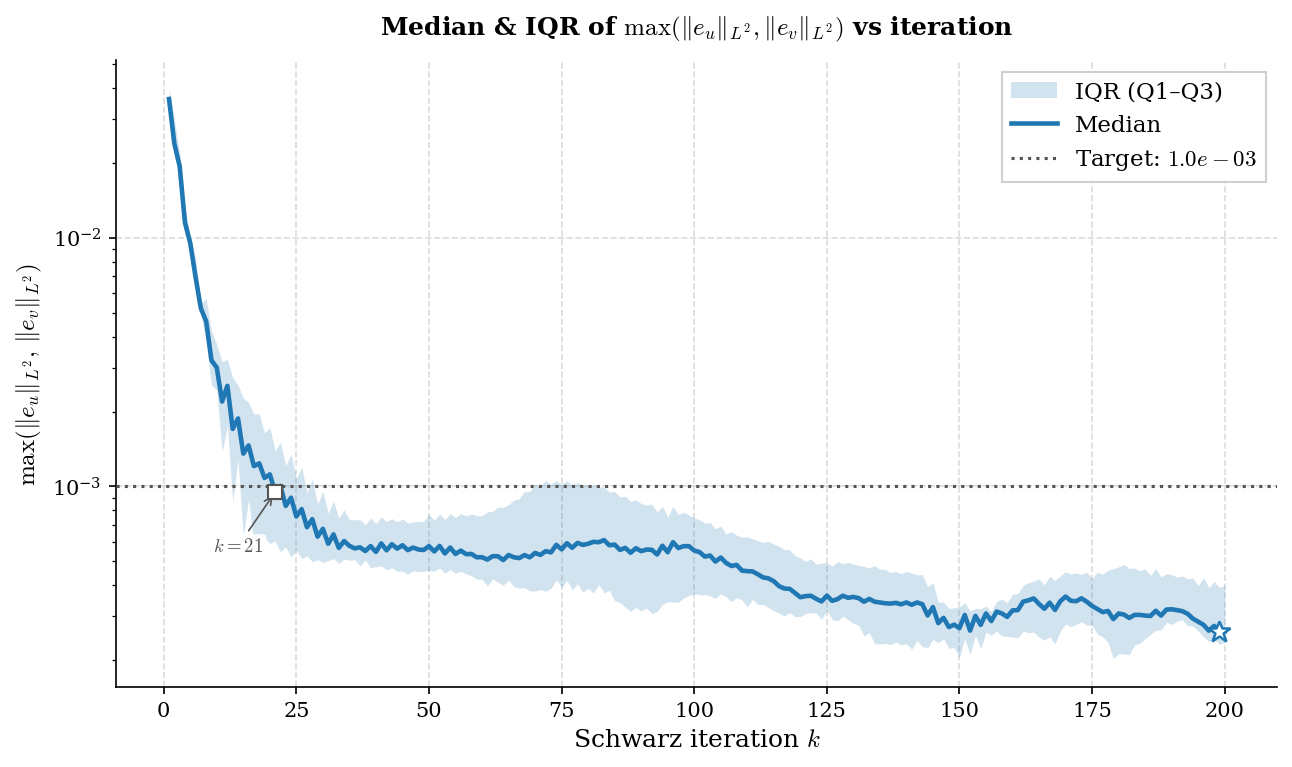

[Saved] content/mntt/stats_gap.png


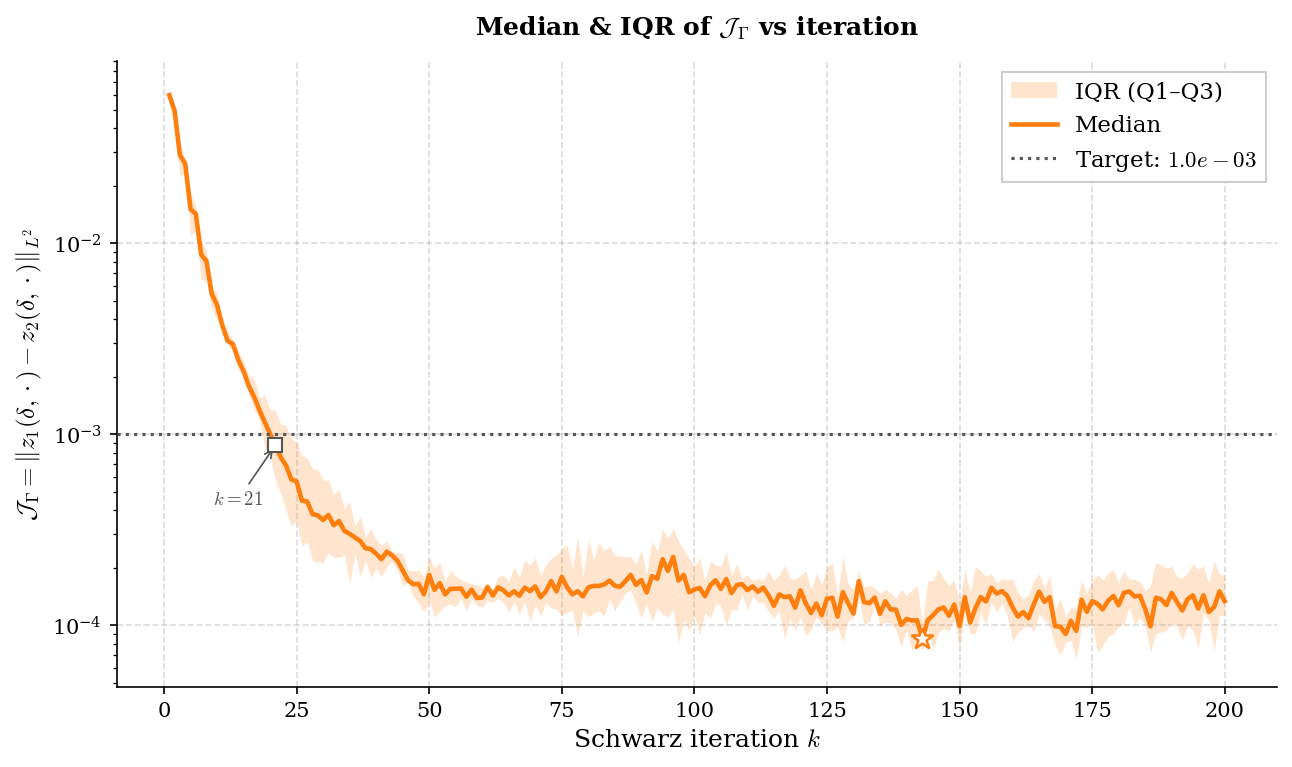

In [ ]:
# @title Statistical convergence dynamics across random seeds for asymmetric decomposition
# Purpose: Aggregate convergence statistics across seeds.

import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from typing import Dict

_default_outdir = "/content/aggregate" if os.path.isdir("/content") else "aggregate"
OUTDIR           = globals().get("OUTDIR", _default_outdir)
SAVE_SVG         = True
DPI_PNG          = 300
PLOT_INDIV_SEEDS = False
LIMIT_ITERS      = globals().get("LIMIT_ITERS", None)

SHOW_PLOTS       = True
ONLY_FIRST_TWO   = True

TARGET_ACC = globals().get("TARGET_ACC", 1e-3)
TARGET_GAP = globals().get("TARGET_GAP", 1e-3)

C_ERR    = "#1f77b4"
C_GAP    = "#ff7f0e"
C_TARGET = "#555555"
C_GRID   = "#7f7f7f"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "axes.grid": True,
    "grid.alpha": 0.28,
    "grid.linestyle": "--",
    "grid.color": C_GRID,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.fancybox": False,
    "legend.edgecolor": "0.8",
    "figure.dpi": 150,
})
os.makedirs(OUTDIR, exist_ok=True)

_NUM = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"

RE_L2_PAIR = re.compile(
    r"\[iter\s+(\d+)\]\s*.*?L2\s*\(\s*u\s*\)\s*=\s*(" + _NUM + r")\s+.*?L2\s*\(\s*v\s*\)\s*=\s*(" + _NUM + r")",
    re.IGNORECASE
)
RE_L2U  = re.compile(r"\[iter\s+(\d+)\]\s*.*?L2\s*\(\s*u\s*\)\s*=\s*(" + _NUM + r")", re.IGNORECASE)
RE_L2V  = re.compile(r"\[iter\s+(\d+)\]\s*.*?L2\s*\(\s*v\s*\)\s*=\s*(" + _NUM + r")", re.IGNORECASE)
RE_GAP  = re.compile(r"\[iter\s+(\d+)\]\s*.*?z1.*?(?:-|−|–)\s*z2.*?=\s*(" + _NUM + r")", re.IGNORECASE)
RE_RMAX = re.compile(r"r1\s*=\s*(" + _NUM + r")\s*r2\s*=\s*(" + _NUM + r")\s*\(max\s*=\s*(" + _NUM + r")\)", re.IGNORECASE)

def parse_log_text(log_text: str) -> Dict:
    data = {"iters": set(), "L2u": {}, "L2v": {}, "gap": {}, "rmax": {}}
    current_iter = None

    for line in log_text.splitlines():
        m = RE_L2_PAIR.search(line)
        if m:
            k = int(m.group(1))
            data["L2u"][k] = float(m.group(2))
            data["L2v"][k] = float(m.group(3))
            data["iters"].add(k)
            current_iter = k
            continue

        m = RE_L2U.search(line)
        if m:
            k = int(m.group(1))
            data["L2u"][k] = float(m.group(2))
            data["iters"].add(k)
            current_iter = k

        m = RE_L2V.search(line)
        if m:
            k = int(m.group(1))
            data["L2v"][k] = float(m.group(2))
            data["iters"].add(k)
            current_iter = k

        m = RE_GAP.search(line)
        if m:
            k = int(m.group(1))
            data["gap"][k] = float(m.group(2))
            data["iters"].add(k)

        m = RE_RMAX.search(line)
        if m and current_iter is not None:
            data["rmax"][current_iter] = float(m.group(3))

    sorted_iters = sorted(list(data["iters"]))
    if LIMIT_ITERS is not None:
        sorted_iters = [k for k in sorted_iters if k <= LIMIT_ITERS]
    data["iters"] = sorted_iters
    return data

def load_logs(log_dict=None, log_dir=None):
    parsed_logs = {}
    if log_dir:
        for fpath in glob.glob(log_dir):
            name = os.path.splitext(os.path.basename(fpath))[0]
            with open(fpath, "r", encoding="utf-8", errors="ignore") as f:
                parsed_logs[name] = parse_log_text(f.read())
    if log_dict:
        for name, txt in log_dict.items():
            parsed_logs[name] = parse_log_text(txt)
    return parsed_logs

def compute_statistics(seed_data: Dict, metric: str):
    all_iters = set()
    for p in seed_data.values():
        all_iters.update(p["iters"])
    sorted_iters = sorted(list(all_iters))
    if LIMIT_ITERS is not None:
        sorted_iters = [k for k in sorted_iters if k <= LIMIT_ITERS]

    if not sorted_iters:
        return [], pd.DataFrame(), {}

    seed_series = {}
    matrix_rows = []

    for seed, p in seed_data.items():
        row_vals = []
        for k in sorted_iters:
            val = np.nan
            if metric == "L2max":
                u = p["L2u"].get(k, np.nan)
                v = p["L2v"].get(k, np.nan)
                if np.isfinite(u) and np.isfinite(v):
                    val = max(u, v)
                elif np.isfinite(u):
                    val = u
                elif np.isfinite(v):
                    val = v
            elif metric in ["L2u", "L2v"]:
                val = p[metric].get(k, np.nan)
            elif metric in ["gap", "rmax"]:
                val = p[metric].get(k, np.nan)
            row_vals.append(val)

        arr = np.array(row_vals, dtype=float)
        seed_series[seed] = arr
        matrix_rows.append(arr)

    M = np.vstack(matrix_rows)

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", r"All-NaN (slice|axis) encountered")
        median = np.nanmedian(M, axis=0)
        q1     = np.nanpercentile(M, 25, axis=0)
        q3     = np.nanpercentile(M, 75, axis=0)
        count  = np.sum(np.isfinite(M), axis=0)

    df_stats = pd.DataFrame({
        "iter": sorted_iters,
        "median": median,
        "q1": q1,
        "q3": q3,
        "count": count
    })
    return sorted_iters, df_stats, seed_series

def first_below(x, y, target):
    for k, v in zip(x, y):
        if np.isfinite(v) and v > 0 and v <= target:
            return int(k), float(v)
    return None, None

def best_point(x, y):
    mask = np.isfinite(y) & (y > 0)
    if not np.any(mask):
        return None, None
    idx = np.argmin(y[mask])
    return int(np.asarray(x)[mask][idx]), float(np.asarray(y)[mask][idx])

def plot_convergence(iters, df, seed_series, title, ylabel, outname, main_color, target=None):
    if df.empty:
        return

    x = np.array(iters, dtype=int)
    med = df["median"].to_numpy(dtype=float)
    q1  = df["q1"].to_numpy(dtype=float)
    q3  = df["q3"].to_numpy(dtype=float)

    def _pos(a):
        a = a.copy()
        a[~np.isfinite(a)] = np.nan
        a[a <= 0] = np.nan
        return a

    medp = _pos(med)
    q1p  = _pos(q1)
    q3p  = _pos(q3)

    valid = medp[np.isfinite(medp)]
    use_log = bool(valid.size) and (np.nanmax(valid) / np.nanmin(valid) > 50)

    fig, ax = plt.subplots(figsize=(8.5, 5.0), constrained_layout=True)

    if PLOT_INDIV_SEEDS:
        for s_vals in seed_series.values():
            s = _pos(np.asarray(s_vals, dtype=float))
            ax.plot(x, s, color=main_color, lw=0.6, alpha=0.10, zorder=1)

    ax.fill_between(x, q1p, q3p, color=main_color, alpha=0.20, lw=0, zorder=2, label="IQR (Q1–Q3)")
    ax.plot(x, medp, color=main_color, lw=2.2, alpha=1.0, zorder=3, label="Median")

    if target is not None:
        ax.axhline(target, color=C_TARGET, ls=":", lw=1.5, zorder=4, label=rf"Target: ${target:.1e}$")
        k_conv, v_conv = first_below(x, medp, target)
        if k_conv is not None:
            ax.plot(k_conv, v_conv, marker="s", ms=6.5, mfc="white", mec=C_TARGET, mew=1.0, zorder=6)
            ax.annotate(
                rf"$k={k_conv}$",
                xy=(k_conv, v_conv),
                xytext=(-18, -22), textcoords="offset points",
                fontsize=9, color=C_TARGET,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9),
                arrowprops=dict(arrowstyle="->", color=C_TARGET, lw=0.8),
                ha="center", va="top",
            )

    k_best, v_best = best_point(x, medp)
    if k_best is not None:
        ax.plot(k_best, v_best, marker="*", ms=11, mfc="white", mec=main_color, mew=1.2, zorder=7)

    ax.set_xlabel(r"Schwarz iteration $k$")
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if use_log:
        ax.set_yscale("log")
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    else:
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    if "count" in df.columns and np.nanmin(df["count"].values) != np.nanmax(df["count"].values):
        ax.text(
            0.02, 0.02,
            rf"$N_{{seeds}}(k)\in[{int(np.nanmin(df['count']))},{int(np.nanmax(df['count']))}]$",
            transform=ax.transAxes,
            fontsize=9, color=C_TARGET
        )

    ax.legend(loc="upper right", frameon=True)

    path_png = os.path.join(OUTDIR, f"{outname}.png")
    fig.savefig(path_png, dpi=DPI_PNG)
    if SAVE_SVG:
        fig.savefig(os.path.join(OUTDIR, f"{outname}.svg"))
    fig.savefig(os.path.join(OUTDIR, f"{outname}.pdf"))

    print(f"[Saved] {path_png}")

    if SHOW_PLOTS:
        plt.show()

    plt.close(fig)

def main():
    logs_to_process = globals().get("SEED_LOGS", {})
    log_dir = globals().get("LOG_DIR", None)

    if not logs_to_process and not log_dir:
        print("[Info] No logs found. Generating dummy data...")
        for i in range(5):
            it = np.arange(1, 201)
            decay = 1.0 * np.exp(-0.05 * it)
            noise = np.random.normal(0, 0.15 * decay, size=len(it))
            u = np.abs(decay + noise)
            g = np.abs(0.5 * decay + 0.5 * noise)

            log_str = ""
            for k, val_u, val_g in zip(it, u, g):
                log_str += f"[iter {k}] L2(u)={val_u:.4e} L2(v)={val_u*0.9:.4e}\n"
                log_str += f"[iter {k}] z1-z2={val_g:.4e}\n"
            logs_to_process[f"seed_{i}"] = log_str

    parsed_data = load_logs(log_dict=logs_to_process, log_dir=log_dir)
    if not parsed_data:
        print("[Error] No data.")
        return

    tasks = [
        ("L2max",
         r"$\max(\|e_u\|_{L^2},\,\|e_v\|_{L^2})$",
         r"Median & IQR of $\max(\|e_u\|_{L^2},\|e_v\|_{L^2})$ vs iteration",
         "stats_L2max", TARGET_ACC, C_ERR),

        ("gap",
         r"$\mathcal{J}_\Gamma=\|z_1(\delta,\cdot)-z_2(\delta,\cdot)\|_{L^2}$",
         r"Median & IQR of $\mathcal{J}_\Gamma$ vs iteration",
         "stats_gap", TARGET_GAP, C_GAP),

        ("rmax",
         r"$\max(r_1,r_2)$",
         r"Median & IQR of $\max(r_1,r_2)$ vs iteration",
         "stats_rmax", None, C_ERR),
    ]

    if ONLY_FIRST_TWO:
        tasks = tasks[:2]

    for metric, ylab, title, fname, tgt, col in tasks:
        iters, df, series = compute_statistics(parsed_data, metric)
        df.to_csv(os.path.join(OUTDIR, f"{fname}.csv"), index=False)
        plot_convergence(iters, df, series, title, ylab, fname, main_color=col, target=tgt)

if __name__ == "__main__":
    main()


## Seed Robustness Summary Plots

This cell creates compact robustness plots comparing final or best L2 errors across seeds.


Figures saved to seed_robustness_figs/robustness_plot_final.png


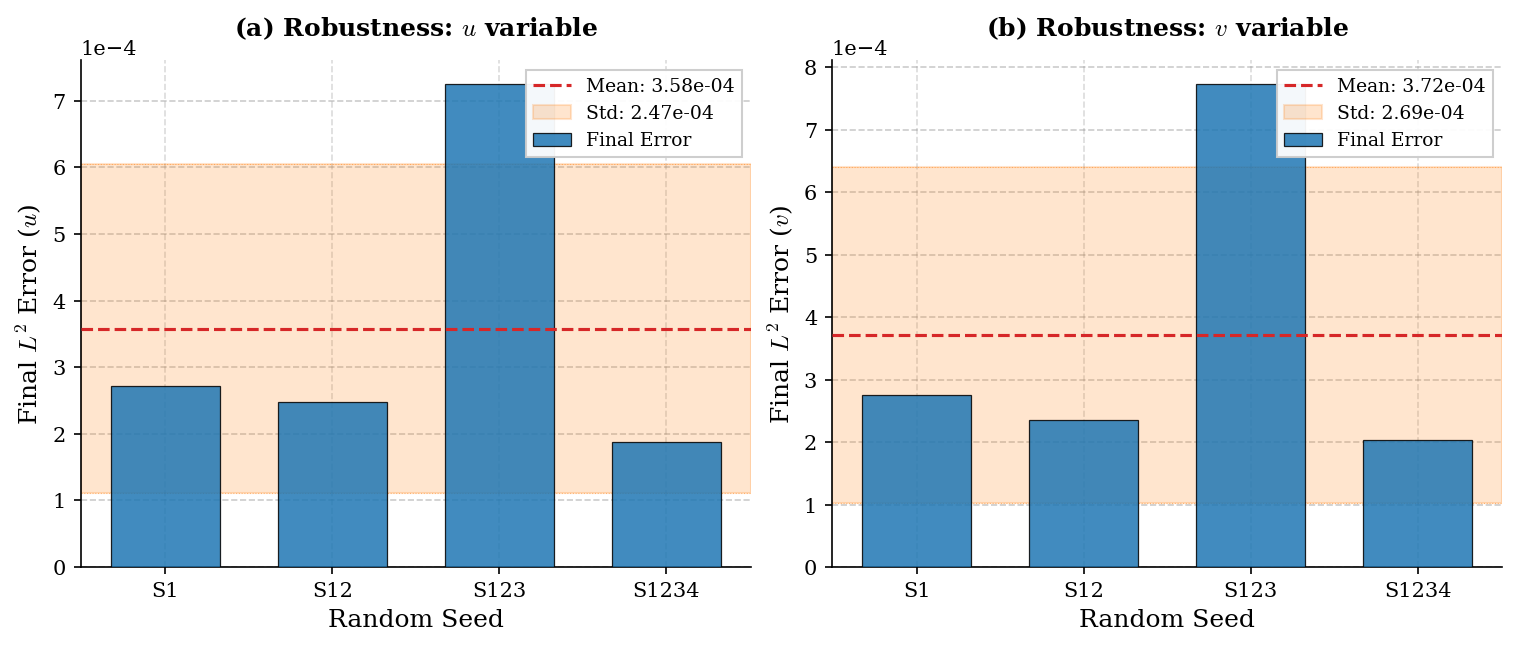

In [ ]:
# @title Seed robustness summary plots
# Purpose: Plot final or best L2 errors across seeds.

import re
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

C_BLUE   = "#1f77b4"
C_ORANGE = "#ff7f0e"
C_GREEN  = "#2ca02c"
C_RED    = "#d62728"
C_GREY   = "#7f7f7f"
C_DARK   = "#333333"

_NUM = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"
PAT_L2 = re.compile(
    rf"\[iter\s*(\d+)\]\s*L2\(u\)\s*=\s*({_NUM})\s+L2\(v\)\s*=\s*({_NUM})",
    re.IGNORECASE
)

def _normalize_text(s: str) -> str:
    """Handles unicode minus signs and zero-width spaces often found in PDFs/Web."""
    return s.replace("\u200b", "").replace("\ufeff", "").replace("−", "-")

def extract_l2_series(log_text: str):
    """Parses iterations and errors from a single log string."""
    txt = _normalize_text(log_text)
    iters, u_vals, v_vals = [], [], []
    for m in PAT_L2.finditer(txt):
        iters.append(int(m.group(1)))
        u_vals.append(float(m.group(2)))
        v_vals.append(float(m.group(3)))

    if not iters:
        return [0], [0]

    order = np.argsort(iters)
    return [u_vals[i] for i in order], [v_vals[i] for i in order]

def pick_metric(u_vals, v_vals, use_min_over_iters: bool):
    """Selects either the final error or the best error observed."""
    if not u_vals: return np.nan, np.nan
    if use_min_over_iters:
        return float(np.min(u_vals)), float(np.min(v_vals))
    return float(u_vals[-1]), float(v_vals[-1])

def make_seed_robustness_plots(log_data_map,
                               use_min_over_iters=False,
                               use_log_scale=True,
                               outdir="seed_robustness_figs"):

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "font.size": 11,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 150
    })

    os.makedirs(outdir, exist_ok=True)

    seeds = sorted(log_data_map.keys())
    if not seeds:
        print("No seed data provided.")
        return

    l2u_vals, l2v_vals = [], []
    for s in seeds:
        u_series, v_series = extract_l2_series(log_data_map[s])
        u_pick, v_pick = pick_metric(u_series, v_series, use_min_over_iters)
        l2u_vals.append(u_pick)
        l2v_vals.append(v_pick)

    data_groups = [np.array(l2u_vals), np.array(l2v_vals)]
    titles = [r"(a) Robustness: $u$ variable", r"(b) Robustness: $v$ variable"]
    ylabels = [r"Final $L^2$ Error ($u$)", r"Final $L^2$ Error ($v$)"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)

    for i, ax in enumerate(axes):
        vals = data_groups[i]
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            continue

        mean_val = np.mean(vals)
        std_val = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
        x_pos = np.arange(len(seeds))

        bottom_val = min(vals)/10 if use_log_scale else 0
        bars = ax.bar(x_pos, vals, width=0.65,
                      color=C_BLUE, edgecolor="black", linewidth=0.6,
                      alpha=0.85, zorder=3, label="Final Error")

        ax.axhline(mean_val, color=C_RED, linestyle="--", linewidth=1.5, zorder=5,
                   label=f"Mean: {mean_val:.2e}")

        lower_bound = max(1e-16, mean_val - std_val)
        upper_bound = mean_val + std_val

        ax.axhspan(lower_bound, upper_bound, color=C_ORANGE, alpha=0.2, zorder=2,
                   label=f"Std: {std_val:.2e}")

        ax.axhline(upper_bound, color=C_ORANGE, lw=0.5, alpha=0.5, ls=':')
        ax.axhline(lower_bound, color=C_ORANGE, lw=0.5, alpha=0.5, ls=':')

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.8)
        ax.spines["bottom"].set_linewidth(0.8)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([f"S{s}" for s in seeds], rotation=0)
        ax.set_xlabel("Random Seed")
        ax.set_ylabel(ylabels[i])
        ax.set_title(titles[i], pad=12)

        ax.grid(True, axis='y', which='major', linestyle='--', alpha=0.4, color=C_GREY)

        if use_log_scale:
            ax.set_yscale('log')
            ax.yaxis.set_minor_formatter(NullFormatter())
        else:
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

        ax.legend(frameon=True, fancybox=False, edgecolor="0.8", loc="upper right", fontsize=9)

    suffix = "min" if use_min_over_iters else "final"
    save_path = os.path.join(outdir, f"robustness_plot_{suffix}")

    plt.savefig(f"{save_path}.png", dpi=600)
    plt.savefig(f"{save_path}.pdf")

    print(f"Figures saved to {save_path}.png")
    plt.show()

if 'SEED_LOGS' not in globals():
    print("[Info] 'SEED_LOGS' not found. Generating dummy data for demonstration.")
    SEED_LOGS = {}
    for s in [0, 42, 123, 2024, 9999]:
        noise = np.random.uniform(0.5, 2.0)
        SEED_LOGS[s] = f"[iter 200] L2(u)={1e-3 * noise:.3e} L2(v)={1e-3 * noise * 0.9:.3e}"

make_seed_robustness_plots(SEED_LOGS, use_min_over_iters=False, use_log_scale=False)
